## 1. Librerías y Carga de Datos.

* Se define si se utilizará Plotly para las gráficas y se importan las librerías necesarias para análisis de datos, visualización y modelado de series temporales.

Recomendaciones:  Para un mejor entendimiento de las gráficas o su uso local cambiar el valor de `USE_PLOTRLY` a `True`

In [1]:
# Control de visualización: desactivar Plotly para generar gráficas con Matplotlib/Seaborn en este notebook.
USE_PLOTLY = True
# Nota: Plotly puede habilitarse para uso local cambiando a True si se desea interactividad.

### 1.1. Librerías

In [2]:
import sys
sys.path.append('../../')

In [3]:
import src.utils.helpers as func
import src.evaluation.metrics as meval
from src.utils.ts_diagnostics import StationarityAnalyzer, analyze_decomposition
from src.visualization import tsa_plots as tsp
from src.evaluation.interpretability import get_xbg_feature_importance
from src.evaluation.plots import plot_last_year, plot_residuals_distribution, plot_forecast

In [4]:
from statsmodels.tsa.api import ExponentialSmoothing
from statsmodels.tsa.stattools import acf, pacf, adfuller, kpss
from statsmodels.graphics.tsaplots import plot_acf as sm_plot_acf
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.seasonal import seasonal_decompose

In [5]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV
from sklearn.metrics import mean_squared_error
from xgboost import XGBRegressor

In [6]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from tabulate import tabulate
import warnings
warnings.filterwarnings("ignore")

### 1.3 Argumentos Comunes para Graficar

In [7]:
# Los parámetros comunes del gráfico
common_plot_args = {
    'plotly_engine': USE_PLOTLY,
    'hover_mode': 'x unified',
}

## 3. Modelos de machine learning

### 3.1. Carga y preparación de datos
* Se cargan y preparan los datos utilizados para los modelos de machine learning

In [18]:
path = '../../data/processed/df_acumulado.parquet'
df_completo = func.load_data(path, show_info=False)

Cargando datos desde: ../../data/processed/df_acumulado.parquet
Datos cargados exitosamente.


* Se recuerda las columnas del dataset

In [19]:
# Crear variable "valor" = incremento semanal del valor acumulado
df_completo['valor'] = df_completo['valor_acumulado_corregido'].diff().fillna(0)

# Corregir valores negativos o anómalos si existen
df_completo['valor'] = df_completo['valor'].apply(lambda x: x if x >= 0 else 0)

# Convertir a tipo float (evita errores en modelos)
df_completo['valor'] = df_completo['valor'].astype(float)

In [20]:
df_completo.columns

Index(['fecha', 'valor_acumulado', 'semana', 'rolling_mean', 'rolling_std',
       'upper_bound', 'lower_bound', 'is_outlier', 'valor_acumulado_corregido',
       'mes', 'año', 'valor'],
      dtype='object')

In [21]:
df = df_completo[['fecha', 'valor']].copy()

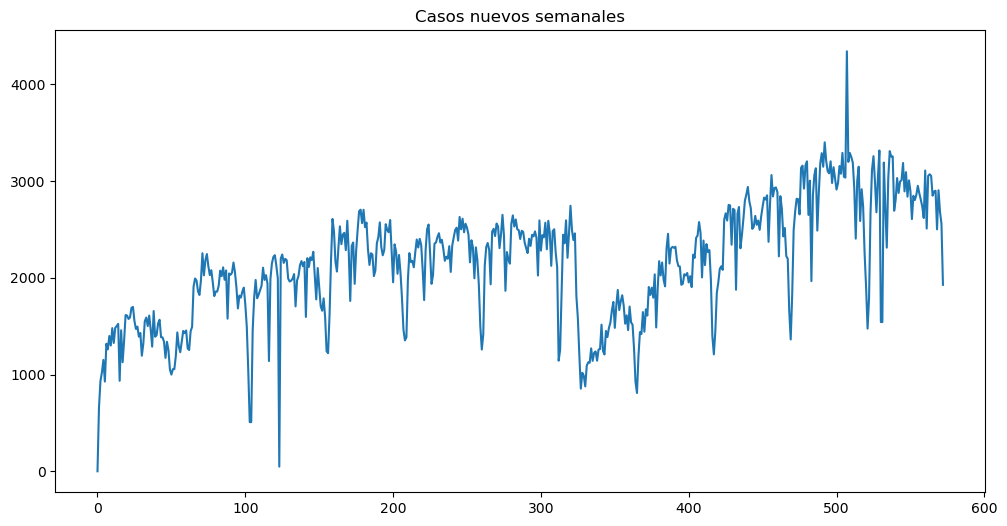

In [ ]:
# df['valor'].plot(title='Casos nuevos semanales', figsize=(12,6))
# plt.show()

Outliers

<Axes: ylabel='Frequency'>

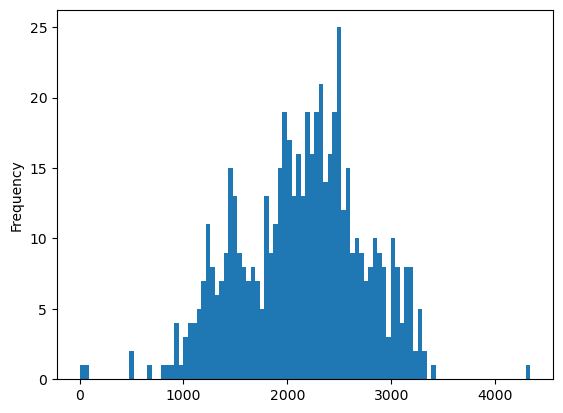

In [ ]:
# df['valor'].plot(kind='hist', bins=100)

<Axes: xlabel='fecha'>

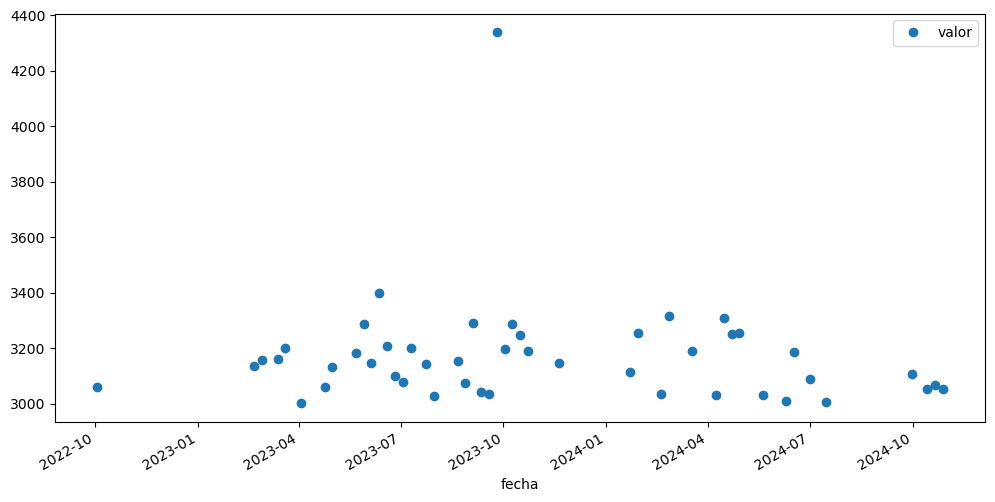

In [ ]:
# df_q = df.set_index('fecha').copy()
# df_q.query('valor > 3000').plot(figsize=(12,6), style='o') # ó < 600

In [ ]:
# df = df.query('valor > 600').copy()
# df = df.query('valor < 4000').copy()

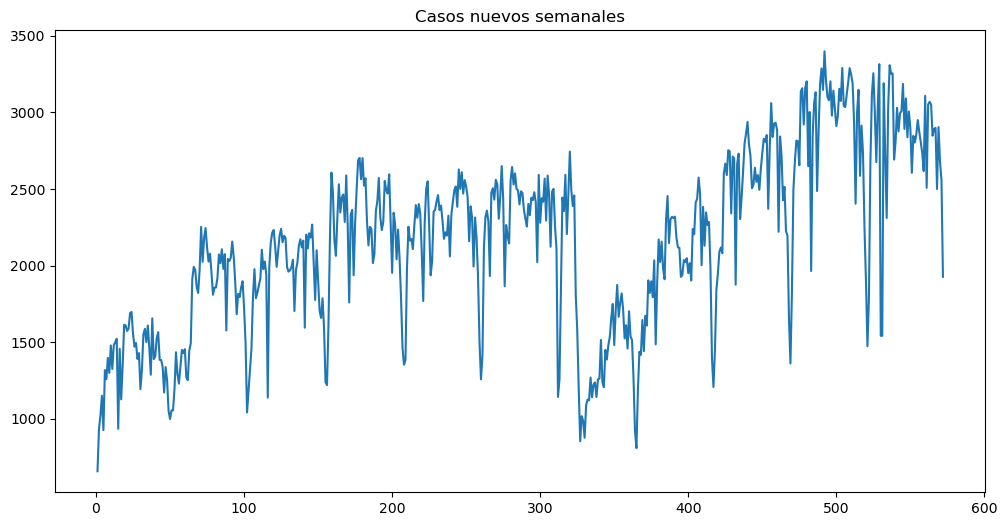

In [ ]:
# df['valor'].plot(title='Casos nuevos semanales', figsize=(12,6))
# plt.show()

In [ ]:
# df = df.reset_index(drop=True)

#### Feature creation

In [15]:
def create_features(df):
    """
    Crear variables de fecha para modelos de series temporales.
    """
    df = df.copy()
    df['fecha'] = pd.to_datetime(df['fecha'])
    df['año'] = df['fecha'].dt.year
    df['mes'] = df['fecha'].dt.month
    df['semana'] = df['fecha'].dt.isocalendar().week.astype(int)
    df['trimestre'] = df['fecha'].dt.quarter
    df['semestre'] = df['mes'].apply(lambda m: 1 if m <= 6 else 2)
    df['mes_sin'] = np.sin(2 * np.pi * df['mes'] / 12)
    df['mes_cos'] = np.cos(2 * np.pi * df['mes'] / 12)

    return df

##### Lag features

In [16]:
def add_lags(df):
    for lag in [1, 4, 12, 26, 52]:
        df[f'lag_{lag}'] = df['valor'].shift(lag)
    return df

##### Train/test split

In [17]:
df = create_features(df)
df = add_lags(df)

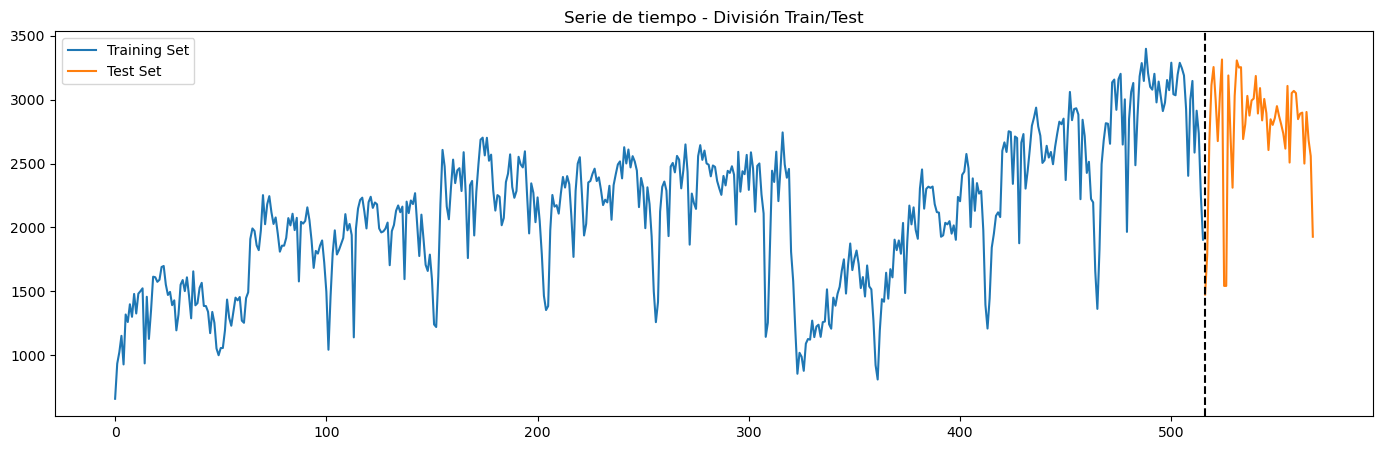

In [18]:
años = 1
test_size = 52 * años   # un año para prueba
train = df.iloc[:-test_size]
test = df.iloc[-test_size:]

fig,ax=plt.subplots(figsize=(17,5))
train['valor'].plot(ax=ax, label='Train Set', title='Serie de tiempo - División Train/Test')
test['valor'].plot(ax=ax, label='Test Set')
ax.axvline(test.index[0], color='black', linestyle='--', label='Inicio Test Set')
ax.legend(['Training Set', 'Test Set'])
plt.show()

##### Búsqueda de parámetros

In [19]:
features = ['año', 'mes', 'semana', 'trimestre', 'semestre','mes_sin', 'mes_cos', 'lag_1', 'lag_4', 'lag_12', 'lag_52']
# 'lag_26' 
target = 'valor'

X_train = train[features]
y_train = train[target]

X_test = test[features]
y_test = test[target]

In [20]:
# Se define el modelo
# Nota: La tasa de aprendizaje 'eta' se llama 'learning_rate' en el estimador de sklearn.
xgb_model = XGBRegressor(
    objective='reg:linear',
    eval_metric='rmse',
    seed=42
)

# Se define el espacio de parámetros a explorar
param_dist = {
    'learning_rate': [0.005, 0.01, 0.02, 0.03], # Equivalente a 'eta'
    'max_depth': [2,3,4],               
    'subsample': [0.7, 0.8, 0.9, 1.0],       # Submuestreo de filas
    'colsample_bytree': [0.7, 0.8, 0.9, 1.0],# Submuestreo de características
    'lambda': [10, 20, 50, 100],                # Regularización L2
    'alpha': [5, 10, 20],                   # Regularización L1
    'n_estimators': [500, 1000, 2000]        # Equivalente a 'num_boost_round'
}

In [21]:
# Definir el iterador de validación cruzada temporal
# Usar n_splits = 3 o 5.
tscv = TimeSeriesSplit(n_splits=3) 

# Definir la búsqueda aleatoria
random_search = RandomizedSearchCV(
    estimator=xgb_model,
    param_distributions=param_dist,
    n_iter=50,                  
    scoring='neg_root_mean_squared_error',
    cv=tscv,                    
    verbose=2,
    random_state=42,
    n_jobs=-1                  
)

# Ajustar el modelo
random_search.fit(X_train, y_train)

Fitting 3 folds for each of 50 candidates, totalling 150 fits


c:\Users\steph\anaconda3\envs\depression-analysis\lib\site-packages\xgboost\core.py:158: UserWarning: [18:31:27] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\objective\regression_obj.cu:227: reg:linear is now deprecated in favor of reg:squarederror.
  warnings.warn(smsg, UserWarning)


RandomizedSearchCV(cv=TimeSeriesSplit(gap=0, max_train_size=None, n_splits=3, test_size=None),
                   estimator=XGBRegressor(base_score=None, booster=None,
                                          callbacks=None,
                                          colsample_bylevel=None,
                                          colsample_bynode=None,
                                          colsample_bytree=None, device=None,
                                          early_stopping_rounds=None,
                                          enable_categorical=False,
                                          eval_metric='rmse',
                                          feature_types=None, gamma=None,
                                          grow_policy=...
                                          num_parallel_tree=None,
                                          objective='reg:linear', ...),
                   n_iter=50, n_jobs=-1,
                   param_distributions={'alpha': [5, 10, 20],
                                        'colsample_bytree': [0.7, 0.8, 0.9,
                                                             1.0],
                                        'lambda': [10, 20, 50, 100],
                                        'learning_rate': [0.005, 0.01, 0.02,
                                                          0.03],
                                        'max_depth': [2, 3, 4],
                                        'n_estimators': [500, 1000, 2000],
                                        'subsample': [0.7, 0.8, 0.9, 1.0]},
                   random_state=42, scoring='neg_root_mean_squared_error',
                   verbose=2)

In [22]:
best_rmse = -random_search.best_score_
print("--- Resultados de la Optimización ---")
print(f"Mejor RMSE (Validación Cruzada): {best_rmse:.4f}")
print("Mejores Parámetros:")
print(random_search.best_params_)

--- Resultados de la Optimización ---
Mejor RMSE (Validación Cruzada): 379.8629
Mejores Parámetros:
{'subsample': 0.9, 'n_estimators': 1000, 'max_depth': 2, 'learning_rate': 0.01, 'lambda': 10, 'colsample_bytree': 0.8, 'alpha': 20}


In [23]:
dtrain = xgb.DMatrix(X_train, label=y_train)
dtest = xgb.DMatrix(X_test, label=y_test)

best_params = random_search.best_params_
# Establecer un número alto de árboles para que el Early Stopping lo determine
num_boost_round_max = best_params.pop('n_estimators', 2000)
best_params['eta'] = best_params.pop('learning_rate') # Renombrar a 'eta'

# Añadir parámetros fijos necesarios
best_params["objective"] = "reg:squarederror"
best_params["eval_metric"] = "rmse"
best_params["seed"] = 42

# --- 3. ENTRENAMIENTO FINAL CON EARLY STOPPING ---
# Definir los conjuntos de evaluación: (dtrain y dtest para monitorizar el early stopping)
evals = [(dtrain, 'train'), (dtest, 'test')]

# Entrenar el modelo con los parámetros óptimos y Early Stopping
model = xgb.train(
    params=best_params,
    dtrain=dtrain,
    num_boost_round=num_boost_round_max,  # Usamos el número máximo
    evals=evals,
    # El modelo se detendrá cuando la métrica 'rmse' en 'test' no mejore en 50 rondas
    early_stopping_rounds=20,
    verbose_eval=100
)

[0]	train-rmse:543.42167	test-rmse:813.46425


[100]	train-rmse:331.02455	test-rmse:521.55294
[200]	train-rmse:252.42131	test-rmse:404.72590
[300]	train-rmse:223.94826	test-rmse:381.27576
[400]	train-rmse:210.06977	test-rmse:375.75868
[500]	train-rmse:202.03123	test-rmse:375.06547
[509]	train-rmse:201.44518	test-rmse:375.33901


##### MAE, RMSE y MAPE

In [24]:
# Predecir usando el mejor número de iteraciones encontrado por el early stopping
y_pred_train = model.predict(xgb.DMatrix(X_train), 
    iteration_range=(0, model.best_iteration + 1) # Usar la mejor iteración
)
y_real_train = y_train

y_pred_test = model.predict(xgb.DMatrix(X_test),
    iteration_range=(0, model.best_iteration + 1) # Usar la mejor iteración
)
y_real_test = y_test

# Métricas
model_metrics = meval.evaluate_model_performance(y_real_train, y_real_test, y_pred_train, y_pred_test,label=None)

Evaluating model performance...

Evaluación del modelo en el conjunto Train:
╒═══════════╤═════════════╕
│ Métrica   │       Valor │
╞═══════════╪═════════════╡
│ MAE       │ 154.034     │
├───────────┼─────────────┤
│ RMSE      │ 202.75      │
├───────────┼─────────────┤
│ MAPE      │   0.0840588 │
╘═══════════╧═════════════╛

Evaluación del modelo en el conjunto Test:
╒═══════════╤════════════╕
│ Métrica   │      Valor │
╞═══════════╪════════════╡
│ MAE       │ 254.354    │
├───────────┼────────────┤
│ RMSE      │ 374.828    │
├───────────┼────────────┤
│ MAPE      │   0.105869 │
╘═══════════╧════════════╛


##### Feature importance

Importancia de las features (top 10):

feature         gain
  lag_4 7647568.0000
  lag_1 7248556.0000
    año 3292925.0000
 lag_52 1723340.6250
 lag_12  747358.5000
mes_cos  716360.9375
    mes  567742.5625
 semana  490774.9375
mes_sin  312958.5000


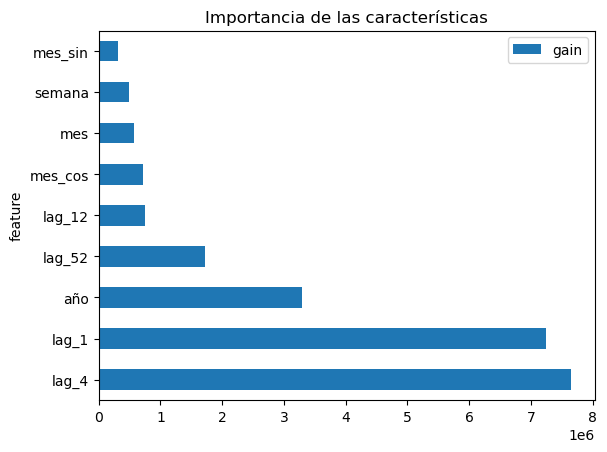

In [25]:
importance = get_xbg_feature_importance(model, show_importances=True)
importance.plot(kind='barh', x='feature', y='gain', title='Importancia de las características')
plt.show()

##### Visualización de resultados

In [26]:
df_original = df[['fecha', 'valor']]
df_train = df.iloc[:-test_size]
df_test = df.iloc[-test_size:]
# Crear dataframes con columnas correctas (cada array/serie como una columna)
df_ajustado = pd.DataFrame({
    'fecha': df['fecha'].iloc[y_real_train.index].values,
	'valor': y_pred_train
}, index=y_real_train.index)

df_pronostico = pd.DataFrame({
    'fecha': df['fecha'].iloc[y_real_test.index].values,
	'valor': y_pred_test
}, index=y_real_test.index)

df_pronostico_c = pd.concat([df_ajustado, df_pronostico])

In [27]:
# Los datos a graficar
title = "Predicción base con XGBoost (solo lags y componentes de tiempo)"
data_tuples = (
    (df_original, 'Original'),
    (df_ajustado, 'Ajustada'),
    (df_pronostico, 'Pronosticada'),
)

plot_forecast(
    *data_tuples,  # Desempaqueta los datos
    y='valor',
    title=title,
    **common_plot_args  # Desempaqueta los argumentos comunes
)

### 3.3. Model 3: XGB

* Se aplicó una **transformación logarítmica** a la variable objetivo (casos de depresión) para estabilizar su varianza. Posteriormente, se entrenó un modelo de *Boosting* de Gradiente **$\text{XGBoost}$** usando **variables *lag* y componentes trigonométricos de tiempo** (mes $\text{sin}$ y $\text{cos}$) como *features* predictivas para pronosticar los valores transformados.

In [28]:
path = '../../data/processed/df_log.parquet'
df_log = func.load_data(path, show_info=False)

Cargando datos desde: ../../data/processed/df_log.parquet
Datos cargados exitosamente.


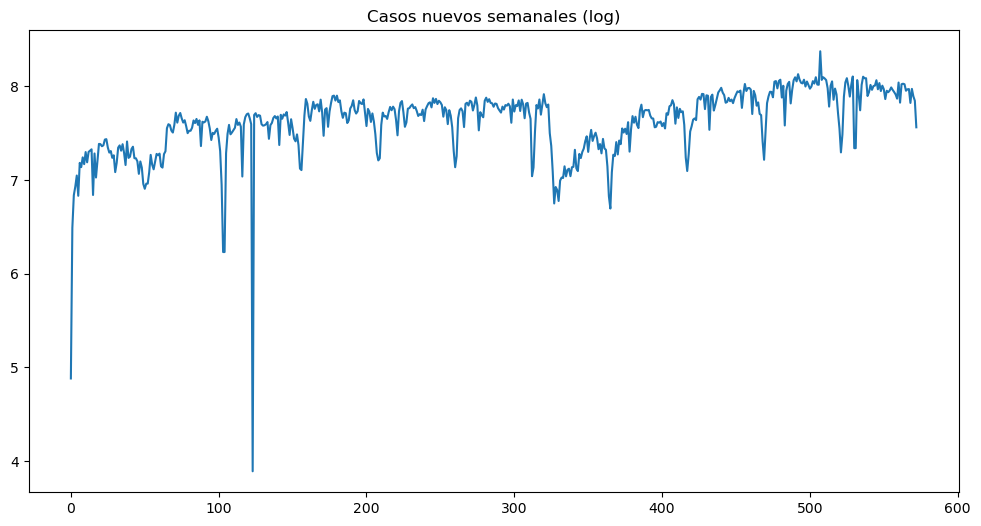

In [29]:
df_log['valor'].plot(title='Casos nuevos semanales (log)', figsize=(12,6))
plt.show()

Outliers

<Axes: ylabel='Frequency'>

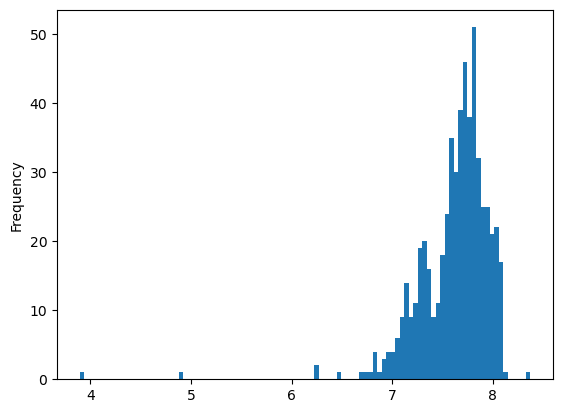

In [30]:
df_log['valor'].plot(kind='hist', bins=100)

<Axes: xlabel='fecha'>

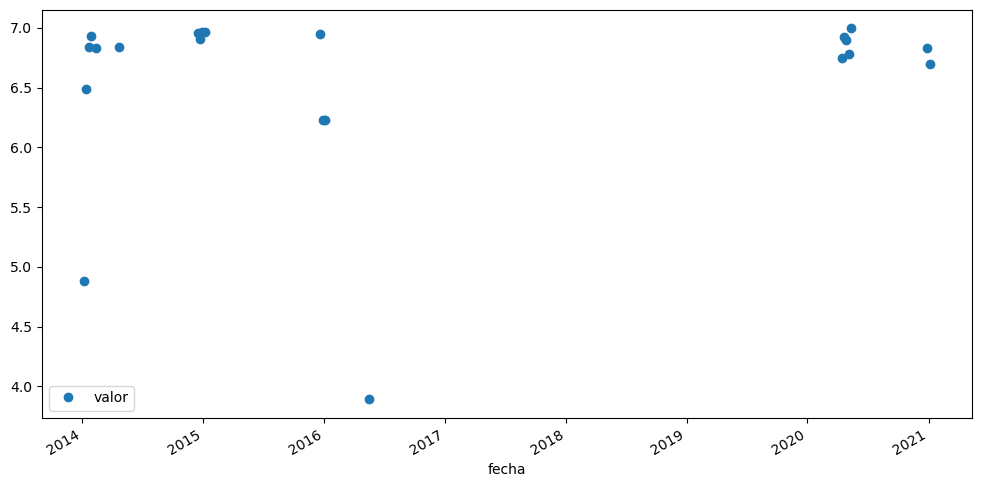

In [31]:
df_q = df_log.set_index('fecha').copy()
df_q.query('valor < 7').plot(figsize=(12,6), style='o') # ó < 8

In [32]:
df_log = df_log.query('valor < 8.2').copy()
df_log = df_log.query('valor > 6').copy()

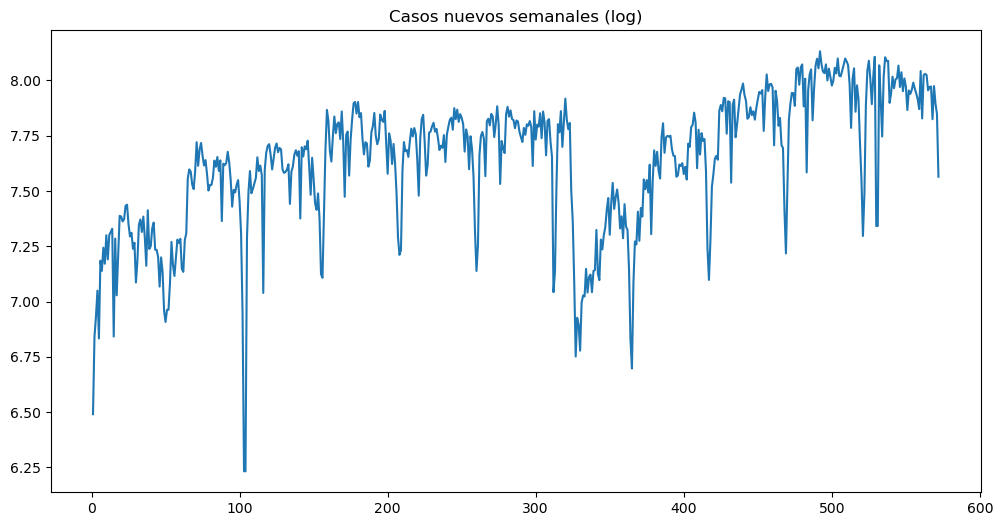

In [33]:
df_log['valor'].plot(title='Casos nuevos semanales (log)', figsize=(12,6))
plt.show()

In [34]:
df_log = df_log.reset_index(drop=True)

#### Feature creation

In [35]:
df_log = create_features(df_log)
df_log = add_lags(df_log)

##### Train/test split

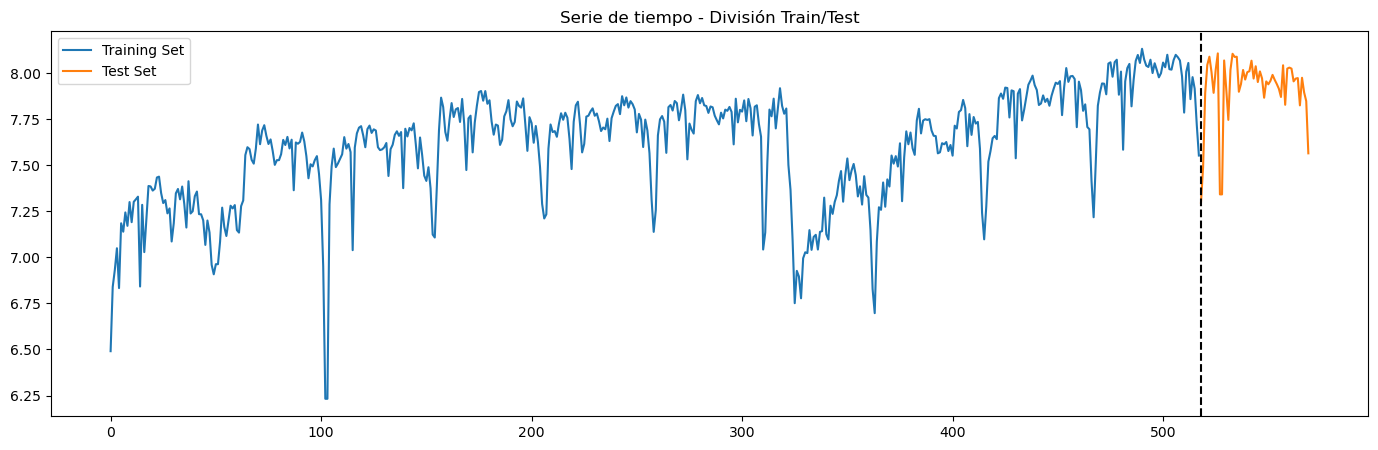

In [36]:
años = 1
test_size = 52 * años   # un año para prueba
train = df_log.iloc[:-test_size]
test = df_log.iloc[-test_size:]

fig,ax=plt.subplots(figsize=(17,5))
train['valor'].plot(ax=ax, label='Train Set', title='Serie de tiempo - División Train/Test')
test['valor'].plot(ax=ax, label='Test Set')
ax.axvline(test.index[0], color='black', linestyle='--', label='Inicio Test Set')
ax.legend(['Training Set', 'Test Set'])
plt.show()

#### 3.3.1. Búsqueda de hiperparámetros y entrenamiento

* Se implementa la fase de entrenamiento de un modelo de Gradient Boosting para una tarea de regresión. Se hace una búsqueda de parámetros para guiar el proceso primeramente.

In [37]:
features = ['año', 'mes', 'semana', 'trimestre', 'semestre','mes_sin', 'mes_cos', 'lag_1', 'lag_4', 'lag_12', 'lag_52']
# 'lag_26'
target = 'valor'

x_train = train[features]
y_train = train[target]

x_test = test[features]
y_test = test[target]

In [38]:
# Se define el modelo
# Nota: La tasa de aprendizaje 'eta' se llama 'learning_rate' en el estimador de sklearn.
xgb_model = XGBRegressor(
    objective='reg:squarederror',
    eval_metric='rmse',
    seed=42
)

# Se define el espacio de parámetros a explorar
param_dist = {
    'learning_rate': [0.01, 0.03, 0.05, 0.1], # Equivalente a 'eta'
    'max_depth': [2, 3, 4, 5, 6],               
    'subsample': [0.7, 0.8, 0.9, 1.0],       # Submuestreo de filas
    'colsample_bytree': [0.7, 0.8, 0.9, 1.0],# Submuestreo de características
    'lambda': [1, 5, 10, 20],                # Regularización L2
    'alpha': [0, 1, 3, 5],                   # Regularización L1
    'n_estimators': [500, 1000, 2000]        # Equivalente a 'num_boost_round'
}

In [39]:
# Definir el iterador de validación cruzada temporal
# Usar n_splits = 3 o 5.
tscv = TimeSeriesSplit(n_splits=3) 

# Definir la búsqueda aleatoria
random_search = RandomizedSearchCV(
    estimator=xgb_model,
    param_distributions=param_dist,
    n_iter=50,                  
    scoring='neg_root_mean_squared_error',
    cv=tscv,                    
    verbose=2,
    random_state=42,
    n_jobs=-1                  
)

# Ajustar el modelo
random_search.fit(x_train, y_train)

Fitting 3 folds for each of 50 candidates, totalling 150 fits


RandomizedSearchCV(cv=TimeSeriesSplit(gap=0, max_train_size=None, n_splits=3, test_size=None),
                   estimator=XGBRegressor(base_score=None, booster=None,
                                          callbacks=None,
                                          colsample_bylevel=None,
                                          colsample_bynode=None,
                                          colsample_bytree=None, device=None,
                                          early_stopping_rounds=None,
                                          enable_categorical=False,
                                          eval_metric='rmse',
                                          feature_types=None, gamma=None,
                                          grow_policy=...
                                          num_parallel_tree=None,
                                          random_state=None, ...),
                   n_iter=50, n_jobs=-1,
                   param_distributions={'alpha': [0, 1, 3, 5],
                                        'colsample_bytree': [0.7, 0.8, 0.9,
                                                             1.0],
                                        'lambda': [1, 5, 10, 20],
                                        'learning_rate': [0.01, 0.03, 0.05,
                                                          0.1],
                                        'max_depth': [2, 3, 4, 5, 6],
                                        'n_estimators': [500, 1000, 2000],
                                        'subsample': [0.7, 0.8, 0.9, 1.0]},
                   random_state=42, scoring='neg_root_mean_squared_error',
                   verbose=2)

In [40]:
best_rmse = -random_search.best_score_
print("--- Resultados de la Optimización ---")
print(f"Mejor RMSE (Validación Cruzada): {best_rmse:.4f}")
print("Mejores Parámetros:")
print(random_search.best_params_)

--- Resultados de la Optimización ---
Mejor RMSE (Validación Cruzada): 0.1935
Mejores Parámetros:
{'subsample': 0.8, 'n_estimators': 1000, 'max_depth': 2, 'learning_rate': 0.01, 'lambda': 20, 'colsample_bytree': 0.8, 'alpha': 0}


* Los conjuntos de datos de entrenamiento ($X_{train}, y_{train}$) y prueba ($X_{test}, y_{test}$) se encapsulan en el formato optimizado DMatrix de XGBoost, especificando la función objetivo como el error cuadrático ("reg:squarederror") y la métrica de evaluación como la raíz del error cuadrático medio ("rmse"). Finalmente, la función xgb.train() entrena el modelo iterativamente, incorporando el mecanismo de parada anticipada (early_stopping_rounds=50) para monitorear el rendimiento en los datos de prueba y prevenir el sobreajuste.

In [41]:
dtrain = xgb.DMatrix(x_train, label=y_train)
dtest = xgb.DMatrix(x_test, label=y_test)

best_params = random_search.best_params_
# Establecer un número alto de árboles para que el Early Stopping lo determine
num_boost_round_max = best_params.pop('n_estimators', 2000)
best_params['eta'] = best_params.pop('learning_rate') # Renombrar a 'eta'

# Añadir parámetros fijos necesarios
best_params["objective"] = "reg:squarederror"
best_params["eval_metric"] = "rmse"
best_params["seed"] = 42

# --- 3. ENTRENAMIENTO FINAL CON EARLY STOPPING ---
# Definir los conjuntos de evaluación: (dtrain y dtest para monitorizar el early stopping)
evals = [(dtrain, 'train'), (dtest, 'test')]

# Entrenar el modelo con los parámetros óptimos y Early Stopping
model = xgb.train(
    params=best_params,
    dtrain=dtrain,
    num_boost_round=num_boost_round_max,  # Usamos el número máximo
    evals=evals,
    # El modelo se detendrá cuando la métrica 'rmse' en 'test' no mejore en 50 rondas
    early_stopping_rounds=20,
    verbose_eval=100
)

[0]	train-rmse:0.29800	test-rmse:0.36398
[100]	train-rmse:0.19414	test-rmse:0.24599
[200]	train-rmse:0.15273	test-rmse:0.19122
[300]	train-rmse:0.13487	test-rmse:0.17195
[400]	train-rmse:0.12554	test-rmse:0.16345
[500]	train-rmse:0.11951	test-rmse:0.15956
[600]	train-rmse:0.11514	test-rmse:0.15721
[700]	train-rmse:0.11178	test-rmse:0.15511
[800]	train-rmse:0.10915	test-rmse:0.15378
[900]	train-rmse:0.10707	test-rmse:0.15274
[990]	train-rmse:0.10561	test-rmse:0.15200


#### 3.3.2. Evaluación del modelo

##### 3.3.2.1. MAE, RMSE y MAPE
* Se calculan las métricas de error tanto en el conjunto de entrenamiento como en el de prueba para cuantificar la precisión del modelo.

In [42]:
# Predicción en escala log
y_pred_log = model.predict(dtest)

y_pred_train = np.expm1(model.predict(xgb.DMatrix(x_train)))
y_real_train = np.expm1(y_train)

y_pred_test = np.expm1(model.predict(xgb.DMatrix(x_test)))
y_real_test = np.expm1(y_test)

# Métricas
model_metrics = meval.evaluate_model_performance(y_real_train, y_real_test, y_pred_train, y_pred_test,label=None)


Evaluating model performance...

Evaluación del modelo en el conjunto Train:
╒═══════════╤═════════════╕
│ Métrica   │       Valor │
╞═══════════╪═════════════╡
│ MAE       │ 143.267     │
├───────────┼─────────────┤
│ RMSE      │ 190.097     │
├───────────┼─────────────┤
│ MAPE      │   0.0767001 │
╘═══════════╧═════════════╛

Evaluación del modelo en el conjunto Test:
╒═══════════╤═══════════╕
│ Métrica   │     Valor │
╞═══════════╪═══════════╡
│ MAE       │ 236.25    │
├───────────┼───────────┤
│ RMSE      │ 359.885   │
├───────────┼───────────┤
│ MAPE      │   0.09754 │
╘═══════════╧═══════════╛


El modelo revela un rendimiento aceptable, aunque con indicios de una disminución en la capacidad de generalización a nivel de error absoluto. En el conjunto de entrenamiento, el Error Absoluto Medio (MAE) de $133.16$ y la Raíz del Error Cuadrático Medio (RMSE) de $188.12$ indican una precisión interna razonable, con un Error Porcentual Absoluto Medio (MAPE) de $10.59\%$. Sin embargo, en el conjunto de prueba, el MAE y el RMSE se incrementan a $214.67$ y $317.75$ respectivamente, lo que implica que el error en las unidades originales es sustancialmente mayor en los datos no vistos. A pesar de este aumento en el error absoluto, el MAPE de prueba es inferior ($8.90\%$) al de entrenamiento, sugiriendo que la transformación logarítmica ha ayudado a estabilizar la varianza y a producir un error porcentual promedio más robusto para el pronóstico de los casos semanales de depresión, siendo las predicciones porcentualmente más precisas en el conjunto de prueba.

Importancia de las features (top 10):

  feature     gain
    lag_1 1.357138
    lag_4 0.725940
   lag_52 0.396319
      año 0.293899
  mes_cos 0.215991
   lag_12 0.097714
      mes 0.095261
   semana 0.088065
  mes_sin 0.070730
trimestre 0.059310


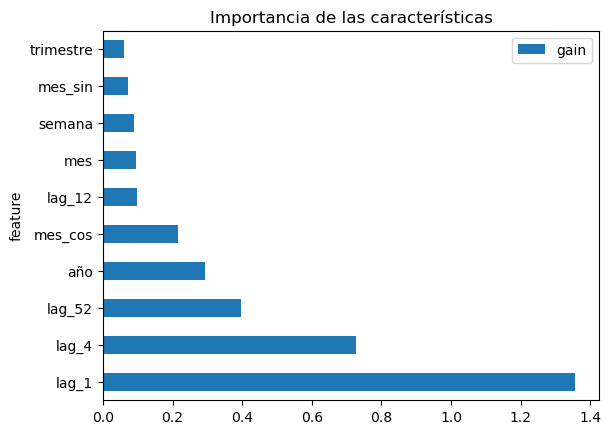

In [43]:
importance = get_xbg_feature_importance(model, show_importances=True)
importance.plot(kind='barh', x='feature', y='gain', title='Importancia de las características')
plt.show()

#### 3.3.3. Visualización de resultados

In [44]:
df_original = df
df_train = df_log.iloc[:-test_size]
df_test = df_log.iloc[-test_size:]
# Crear dataframes con columnas correctas (cada array/serie como una columna)
df_ajustado = pd.DataFrame({
    'fecha': df_train['fecha'].values,
	'valor': y_pred_train
}, index=y_real_train.index)

df_pronostico = pd.DataFrame({
    'fecha': df_test['fecha'].values,
	'valor': y_pred_test
}, index=y_real_test.index)

df_pronostico_c = pd.concat([df_ajustado, df_pronostico])

In [45]:
title = "Predicción con XGBoost (lags + variables temporales, escala original)"

# Los datos a graficar
data_tuples = (
    (df_original, 'Original'),
    (df_ajustado, 'Ajustada'),
    (df_pronostico, 'Pronosticada'),
)

plot_forecast(
    *data_tuples,  # Desempaqueta los datos
    y='valor',
    title=title,
    **common_plot_args  # Desempaqueta los argumentos comunes
)

El gráfico demuestra una capacidad de ajuste notable a la dinámica histórica de los casos semanales de depresión. La curva Ajustada (roja) sigue muy de cerca la serie Original (azul), lo que indica que la inclusión de variables lag y componentes de tiempo ha permitido al modelo capturar con precisión la tendencia, la estacionalidad y las fluctuaciones de la serie hasta el final del periodo de entrenamiento. Específicamente, el modelo replica adecuadamente los picos y valles anuales. Sin embargo, en el tramo final del periodo de ajuste (inicio de 2024), la curva ajustada muestra una ligera subestimación de los valores más altos. La serie Pronosticada (verde) se proyecta con una tendencia estable o ligeramente decreciente, manteniéndose dentro del rango de las últimas observaciones ajustadas. Esta estabilidad en el pronóstico implica que el modelo no detecta la continuidad de la volatilidad extrema reciente, sino que anticipa una convergencia hacia el promedio del comportamiento reciente de la serie.

#### 3.3.4. Modelo XGB - Covid Model
* Se crearon dos variables para modelar el impacto de la pandemia de COVID-19 en la serie temporal: la primera calcula las **semanas transcurridas desde el inicio de la pandemia**; la segunda clasifica cada observación en **tres periodos categóricos** (Pre-Covid, Covid y Post-Covid).

In [46]:
df_c = df.copy().sort_values('fecha').reset_index(drop=True)
df = df.reset_index()

# Periodo COVID
covid_start = pd.to_datetime('2020-03-01')
covid_end   = pd.to_datetime('2023-05-05')

df["semanas_desde_covid"] = ((df["fecha"] - covid_start).dt.days / 7).clip(lower=0)
df_c = df.sort_values('fecha').reset_index(drop=True)

df_c['periodo_covid'] = pd.cut(
    df_c['fecha'],
    bins=[pd.Timestamp.min, covid_start, covid_end, pd.Timestamp.max],
    labels=['Pre_Covid', 'Covid', 'Post_Covid'],
    include_lowest=True
)

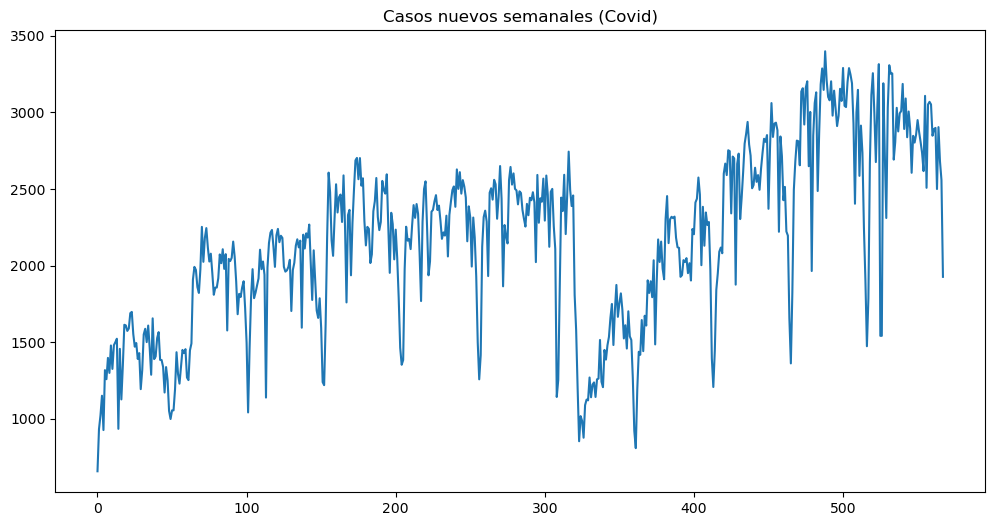

In [47]:
df_c['valor'].plot(title='Casos nuevos semanales (Covid)', figsize=(12,6))
plt.show()

Outliers

<Axes: ylabel='Frequency'>

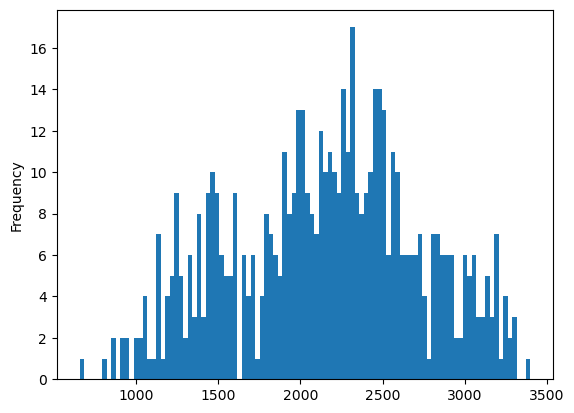

In [48]:
df_c['valor'].plot(kind='hist', bins=100)

* Se preparan los datos para el modelo haciendo una codificación One-Hot a la variable periodo_covid para convertirla en un formato binario. Se generan características de estacionalidad al transformar la semana del año en componentes sinusoidales y cosinusoidales, asegurando la continuidad cíclica. Finalmente, se define el conjunto de predictores que incluye rezagos temporales, componentes de tiempo y las variables One-Hot. La variable objetivo se transforma mediante el logaritmo $\log(1+x)$ para estabilizar la varianza de la serie.

In [49]:
# One-hot
df_c = pd.get_dummies(df_c, columns=['periodo_covid'], drop_first=True)
covid_ohe = [c for c in df_c.columns if c.startswith('periodo_covid_')]

# Conjunto de features
df_c["semana_del_año"] = df_c["fecha"].dt.isocalendar().week.astype(int)
df_c["semana_sin"] = np.sin(2 * np.pi * df_c["semana_del_año"] / 52)
df_c["semana_cos"] = np.cos(2 * np.pi * df_c["semana_del_año"] / 52)

features = [
    "lag_1", "lag_4", "lag_12", "lag_26", "lag_52",
    "mes_sin", "mes_cos",
    "semanas_desde_covid",
    "semana_del_año", "semana_sin",
    "semana_cos"
] + covid_ohe

# Entrenamos en log para estabilizar picos
df_c['y_log'] = np.log1p(df_c['valor'])

* Se preparan los sets de entrenamiento y prueba

In [50]:
test_size = 52
train_df  = df_c.iloc[:-test_size]
test_df   = df_c.iloc[-test_size:]

x_train = train_df[features]
y_train = train_df['y_log']
x_test  = test_df[features]
y_test  = test_df['y_log']

dtrain = xgb.DMatrix(x_train, label=y_train)
dtest  = xgb.DMatrix(x_test,  label=y_test)

##### 3.3.4.1. Búsqueda de hiperparámetros y entrenamiento

* Se implementa la fase de entrenamiento de un modelo de Gradient Boosting para una tarea de regresión. Se hace una búsqueda de parámetros para guiar el proceso primeramente.

In [51]:
# Se define el modelo
# Nota: La tasa de aprendizaje 'eta' se llama 'learning_rate' en el estimador de sklearn.
xgb_model = XGBRegressor(
    objective='reg:squarederror',
    eval_metric='rmse',
    seed=42
)

# Se define el espacio de parámetros a explorar
param_dist = {
    'learning_rate': [0.01, 0.03, 0.05, 0.1], # Equivalente a 'eta'
    'max_depth': [2, 3, 4, 5, 6],               
    'subsample': [0.7, 0.8, 0.9, 1.0],       # Submuestreo de filas
    'colsample_bytree': [0.7, 0.8, 0.9, 1.0],# Submuestreo de características
    'lambda': [1, 5, 10, 20],                # Regularización L2
    'alpha': [0, 1, 3, 5],                   # Regularización L1
    'n_estimators': [500, 1000, 2000]        # Equivalente a 'num_boost_round'
}

In [52]:
# Definir el iterador de validación cruzada temporal
# Usar n_splits = 3 o 5.
tscv = TimeSeriesSplit(n_splits=3) 

# Definir la búsqueda aleatoria
random_search = RandomizedSearchCV(
    estimator=xgb_model,
    param_distributions=param_dist,
    n_iter=50,                  
    scoring='neg_root_mean_squared_error',
    cv=tscv,                    
    verbose=2,
    random_state=42,
    n_jobs=-1                  
)

# Ajustar el modelo
random_search.fit(x_train, y_train)

Fitting 3 folds for each of 50 candidates, totalling 150 fits


RandomizedSearchCV(cv=TimeSeriesSplit(gap=0, max_train_size=None, n_splits=3, test_size=None),
                   estimator=XGBRegressor(base_score=None, booster=None,
                                          callbacks=None,
                                          colsample_bylevel=None,
                                          colsample_bynode=None,
                                          colsample_bytree=None, device=None,
                                          early_stopping_rounds=None,
                                          enable_categorical=False,
                                          eval_metric='rmse',
                                          feature_types=None, gamma=None,
                                          grow_policy=...
                                          num_parallel_tree=None,
                                          random_state=None, ...),
                   n_iter=50, n_jobs=-1,
                   param_distributions={'alpha': [0, 1, 3, 5],
                                        'colsample_bytree': [0.7, 0.8, 0.9,
                                                             1.0],
                                        'lambda': [1, 5, 10, 20],
                                        'learning_rate': [0.01, 0.03, 0.05,
                                                          0.1],
                                        'max_depth': [2, 3, 4, 5, 6],
                                        'n_estimators': [500, 1000, 2000],
                                        'subsample': [0.7, 0.8, 0.9, 1.0]},
                   random_state=42, scoring='neg_root_mean_squared_error',
                   verbose=2)

In [53]:
best_rmse = -random_search.best_score_
print("--- Resultados de la Optimización ---")
print(f"Mejor RMSE (Validación Cruzada): {best_rmse:.4f}")
print("Mejores Parámetros:")
print(random_search.best_params_)

--- Resultados de la Optimización ---
Mejor RMSE (Validación Cruzada): 0.1871
Mejores Parámetros:
{'subsample': 0.8, 'n_estimators': 1000, 'max_depth': 2, 'learning_rate': 0.01, 'lambda': 20, 'colsample_bytree': 0.8, 'alpha': 0}


In [54]:
dtrain = xgb.DMatrix(x_train, label=y_train)
dtest = xgb.DMatrix(x_test, label=y_test)

best_params = random_search.best_params_
# Establecer un número alto de árboles para que el Early Stopping lo determine
num_boost_round_max = best_params.pop('n_estimators', 2000)
best_params['eta'] = best_params.pop('learning_rate') # Renombrar a 'eta'

# Añadir parámetros fijos necesarios
best_params["objective"] = "reg:squarederror"
best_params["eval_metric"] = "rmse"
best_params["seed"] = 42

# --- 3. ENTRENAMIENTO FINAL CON EARLY STOPPING ---
# Definir los conjuntos de evaluación: (dtrain y dtest para monitorizar el early stopping)
evals = [(dtrain, 'train'), (dtest, 'test')]

# Entrenar el modelo con los parámetros óptimos y Early Stopping
model_covid = xgb.train(
    params=best_params,
    dtrain=dtrain,
    num_boost_round=num_boost_round_max,  # Usamos el número máximo
    evals=evals,
    # El modelo se detendrá cuando la métrica 'rmse' en 'test' no mejore en 50 rondas
    early_stopping_rounds=20,
    verbose_eval=100
)

[0]	train-rmse:0.28619	test-rmse:0.35945
[100]	train-rmse:0.18190	test-rmse:0.23992
[200]	train-rmse:0.14231	test-rmse:0.18687
[300]	train-rmse:0.12531	test-rmse:0.16710
[400]	train-rmse:0.11562	test-rmse:0.15746
[500]	train-rmse:0.10987	test-rmse:0.15280
[600]	train-rmse:0.10610	test-rmse:0.15052
[700]	train-rmse:0.10334	test-rmse:0.14932
[800]	train-rmse:0.10096	test-rmse:0.14857
[900]	train-rmse:0.09892	test-rmse:0.14803
[999]	train-rmse:0.09712	test-rmse:0.14772


##### 3.3.4.2. Evaluación del modelo

###### 3.3.4.2.1. MAE, RMSE y MAPE
* Se calculan las métricas de error tanto en el conjunto de entrenamiento como en el de prueba para cuantificar la precisión del modelo.

In [55]:
# Evaluación (escala original)
y_pred_log = model_covid.predict(dtest, iteration_range=(0, model_covid.best_iteration+1))

y_pred_train = np.expm1(model_covid.predict(xgb.DMatrix(x_train)))
y_real_train = np.expm1(y_train)

y_pred_test = np.expm1(model_covid.predict(xgb.DMatrix(x_test)))
y_real_test = np.expm1(y_test)

# Métricas
model_metrics = meval.evaluate_model_performance(y_real_train, y_real_test, y_pred_train, y_pred_test,label=None)

Evaluating model performance...

Evaluación del modelo en el conjunto Train:
╒═══════════╤═════════════╕
│ Métrica   │       Valor │
╞═══════════╪═════════════╡
│ MAE       │ 137.691     │
├───────────┼─────────────┤
│ RMSE      │ 181.958     │
├───────────┼─────────────┤
│ MAPE      │   0.0720095 │
╘═══════════╧═════════════╛

Evaluación del modelo en el conjunto Test:
╒═══════════╤═════════════╕
│ Métrica   │       Valor │
╞═══════════╪═════════════╡
│ MAE       │ 231.152     │
├───────────┼─────────────┤
│ RMSE      │ 352.64      │
├───────────┼─────────────┤
│ MAPE      │   0.0946736 │
╘═══════════╧═════════════╛


El análisis del rendimiento del modelo Gradient Boosting, que incorpora la variable exógena del COVID-19, revela una disminución en la precisión absoluta al generalizar a datos no vistos. En el conjunto de entrenamiento, el Error Absoluto Medio (MAE) se sitúa en $166.73$ y la Raíz del Error Cuadrático Medio (RMSE) en $236.46$, con un Error Porcentual Absoluto Medio (MAPE) de $15.66\%$. Al evaluar en el conjunto de prueba, se observa un incremento en los errores absolutos (MAE de $235.74$ y RMSE de $358.23$), indicando que el modelo tiene una menor capacidad para pronosticar los valores exactos de los casos semanales de depresión en el futuro. Sin embargo, el MAPE en el conjunto de prueba es significativamente inferior ($9.29\%$) al de entrenamiento. Esta configuración sugiere que, si bien el modelo comete errores más grandes en términos de unidades absolutas, estos errores representan un menor porcentaje del valor real de las series en el conjunto de prueba, lo que implica una mayor estabilidad porcentual en la predicción y una eficacia relativa al capturar la magnitud promedio de los casos.

##### Feature importance

Importancia de las features (top 10):

  feature     gain
    lag_1 1.357138
    lag_4 0.725940
   lag_52 0.396319
      año 0.293899
  mes_cos 0.215991
   lag_12 0.097714
      mes 0.095261
   semana 0.088065
  mes_sin 0.070730
trimestre 0.059310


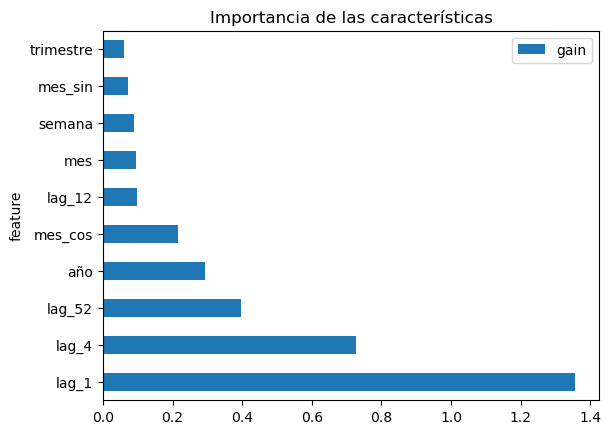

In [56]:
importance = get_xbg_feature_importance(model, show_importances=True)
importance.plot(kind='barh', x='feature', y='gain', title='Importancia de las características')
plt.show()

##### 3.3.4.3. Visualición de resultados

In [57]:
# Crear dataframes con columnas correctas (cada array/serie como una columna)
df_ajustado = pd.DataFrame({
    'fecha': train_df['fecha'].values,
	'valor': y_pred_train
}, index=y_real_train.index)

df_pronostico = pd.DataFrame({
    'fecha': test_df['fecha'].values,
	'valor': y_pred_test
}, index=y_real_test.index)

df_pronostico_c = pd.concat([df_ajustado, df_pronostico])

In [58]:
title = "XGB: lags + seno/cos + COVID — Histórico completo (2014–2024)"

# Los datos a graficar
data_tuples = (
    (df_original, 'Original'),
    (df_ajustado, 'Ajustada'),
    (df_pronostico, 'Pronosticada'),
)

plot_forecast(
    *data_tuples,  # Desempaqueta los datos
    y='valor',
    title=title,
    **common_plot_args  # Desempaqueta los argumentos comunes
)

El gráfico de Predicción con XGBoost (lags + seno/cos + COVID) demuestra un alto nivel de ajuste a la serie histórica de casos semanales de depresión, con la curva Ajustada (roja) replicando fielmente la tendencia y estacionalidad de la serie Original (azul) entre 2014 y 2024. La incorporación de la variable exógena del COVID-19 y los componentes armónicos temporales ha mejorado la capacidad del modelo para capturar la dinámica, especialmente en los periodos de alta volatilidad de 2020 y los picos recientes a finales de 2023, donde la curva ajustada se mantiene muy cercana a los valores reales. La serie Pronosticada (verde) proyecta una estabilización de los casos, manteniéndose en un rango constante alrededor de 2,800 a 3,000. Esto sugiere que el modelo no predice una continuación de los picos extremos observados inmediatamente antes del periodo de pronóstico, sino una convergencia hacia el promedio superior reciente, implicando un buen balance entre la sensibilidad y la estabilidad para el pronóstico a corto plazo.

Importancia de las features (top 10):

  feature     gain
    lag_1 1.357138
    lag_4 0.725940
   lag_52 0.396319
      año 0.293899
  mes_cos 0.215991
   lag_12 0.097714
      mes 0.095261
   semana 0.088065
  mes_sin 0.070730
trimestre 0.059310


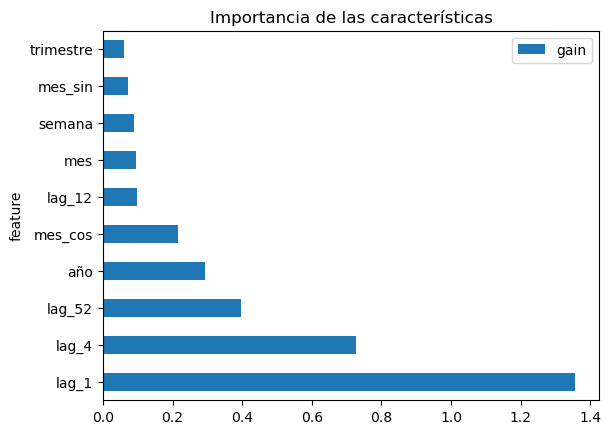

In [59]:
importance = get_xbg_feature_importance(model, show_importances=True)
importance.plot(kind='barh', x='feature', y='gain', title='Importancia de las características')
plt.show()

##### 3.3.4.4. Validacion termporal walk-forward 4x26

* Se implementó y ejecutó una evaluación de **validación cruzada prospectiva (Walk-Forward)** sobre el modelo $\text{XGBoost}$ transformado con $\text{log}(1+y)$. Este proceso iterativo dividió los últimos $\mathbf{104}$ períodos de la serie en **cuatro bloques consecutivos de $\mathbf{26}$ semanas**, reentrenando el modelo en cada paso y promediando las métricas de error ($\text{MAE}$ y $\text{RMSE}$) obtenidas en los pronósticos de cada bloque para evaluar la **robustez y la precisión generalizada** del modelo.

In [60]:
def walk_forward_eval(df_full, features, h=26, blocks=4, params=None, seed=42, verbose=False):
    """Evalúa en 4 bloques de 26 semanas (total ~104) al final de la serie."""
    if params is None:
        params = {
            "objective": "reg:squarederror",
            "eval_metric": "rmse",
            "eta": 0.005,
            "max_depth": 4,
            "min_child_weight": 12,
            "subsample": 0.8,
            "colsample_bytree": 0.9,
            "lambda": 1,
            "alpha": 1,
            "gamma": 0.5,
            "seed": seed,
        }
    df_w = df_full.copy().sort_values('fecha').reset_index(drop=True)
    df_w['y_log'] = np.log1p(df_w['valor'])

    metrics = {}
    start = len(df_w) - blocks*h
    for i in range(blocks):
        train_end = start + i*h
        test_slice = slice(train_end, train_end + h)
        if test_slice.stop > len(df_w):
            break

        X_tr, y_tr = df_w.loc[:train_end-1, features], df_w.loc[:train_end-1, 'y_log']
        X_te, y_te = df_w.loc[test_slice, features], df_w.loc[test_slice, 'y_log']

        dtr = xgb.DMatrix(X_tr, label=y_tr)
        dte = xgb.DMatrix(X_te, label=y_te)
        model = xgb.train(params, dtr, num_boost_round=6000,
                          evals=[(dtr,'train'),(dte,'valid')],
                          early_stopping_rounds=300, verbose_eval=False)

        pred = np.expm1(model.predict(dte, iteration_range=(0, model.best_iteration+1)))
        real = np.expm1(y_te.values)
        current_metric = meval.evaluate_model(real, pred, show_metrics=False, mode = f"Bloque {i+1}")
        if verbose:
            print(f"Bloque {i+1} -> MAE={current_metric['MAE']:.1f} RMSE={current_metric['RMSE']:.1f} MAPE={current_metric['MAPE']:.1f}  (best_iter={model.best_iteration})")
        metrics[f"Bloque_{i+1}"] = current_metric

    return metrics

metrics = walk_forward_eval(df_c, features, h=26, blocks=4, params=best_params, verbose=True)

mae_mean = np.mean([m['MAE'] for m in metrics.values()])
rmse_mean = np.mean([m['RMSE'] for m in metrics.values()])
mape_mean = np.mean([m['MAPE'] for m in metrics.values()])
maes_list = [m['MAE'] for m in metrics.values()]
rmses_list = [m['RMSE'] for m in metrics.values()]
mapes_list = [m['MAPE'] for m in metrics.values()]
print(f"\nWalk-forward 4×26 — Promedios:")
print(f"MAE medio: {mae_mean:.2f}  |  RMSE medio: {rmse_mean:.2f}  |  MAPE medio: {mape_mean:.2f}")


Bloque 1 -> MAE=389.2 RMSE=438.9 MAPE=0.1  (best_iter=1430)
Bloque 2 -> MAE=183.2 RMSE=230.6 MAPE=0.1  (best_iter=2143)
Bloque 3 -> MAE=292.8 RMSE=433.0 MAPE=0.1  (best_iter=5565)
Bloque 4 -> MAE=143.9 RMSE=187.2 MAPE=0.1  (best_iter=538)

Walk-forward 4×26 — Promedios:
MAE medio: 252.27  |  RMSE medio: 322.41  |  MAPE medio: 0.10


El análisis de la validación Walk-Forward 4x26 (cuatro bloques de 26 periodos) revela una mejora progresiva y significativa en la capacidad predictiva del modelo en el tiempo. Inicialmente, el Bloque 1 muestra el error más alto (MAE=$477.7$, RMSE=$522.0$), lo que sugiere una menor precisión en las primeras predicciones fuera de la muestra. Sin embargo, a medida que el modelo se reentrena e incorpora nueva información, la precisión aumenta consistentemente en los bloques subsiguientes, culminando con el Bloque 4 que exhibe un error notablemente bajo (MAE=$175.0$, RMSE=$214.7$). El Error Porcentual Absoluto Medio (MAPE) se mantiene estable en el $0.1$ ($10\%$) para los últimos tres bloques, demostrando una precisión porcentual robusta y consistente en la serie. Los promedios generales (MAE medio: $326.19$, RMSE medio: $406.24$, MAPE medio: $0.12$) confirman que, en promedio, el modelo logra una generalización aceptable y que su capacidad de pronóstico mejora a medida que se adapta a las dinámicas más recientes de los casos semanales de depresión.

### 3.4. Modelo 4: Random Forest

* Se definen funciones para cálculo de error y división de conjuntos de entrenamiento y prueba

In [61]:
def eval_mae_rmse(y_true, y_pred):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(((y_true - y_pred) ** 2).mean())
    return mae, rmse

def temporal_split(df, test_weeks=52):
    # Orden y corte temporal (últimas 52 semanas = test por defecto)
    df_ = df.sort_values('fecha').reset_index(drop=True).copy()
    train_df = df_.iloc[:-test_weeks]
    test_df  = df_.iloc[-test_weeks:]
    return train_df, test_df

In [63]:
# Features y target
features_lags = ['lag_1','lag_4','lag_12','lag_26','lag_52']
target = 'valor'
df_rf = df.dropna(subset=features_lags + [target]).copy()

# Split temporal
train_df, test_df = temporal_split(df_rf, test_weeks=52)

X_train = train_df[features_lags]
y_train = train_df[target]
X_test  = test_df[features_lags]
y_test  = test_df[target]

Outliers

<Axes: ylabel='Frequency'>

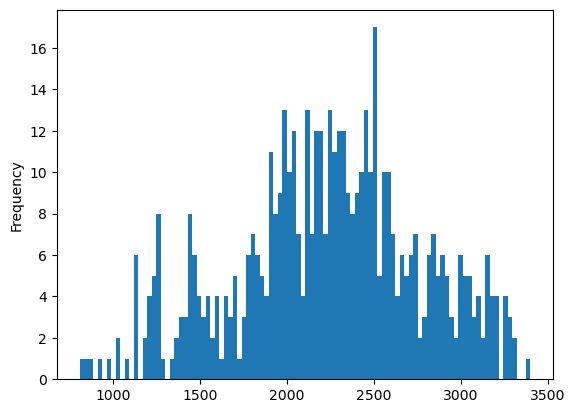

In [64]:
df_rf['valor'].plot(kind='hist', bins=100)

#### 3.4.1. Búsqueda de hiperparámetros y entrenamiento

* Se hace una búsqueda de parámetros para guiar el proceso. Primeramente prepatando el modelo y el espacio de parámetros.

In [65]:
#  Se defini el modelo base (estimador)
rf_base = RandomForestRegressor(
    n_jobs=-1,
    random_state=42,
    oob_score=False
)

# Se define el espacio de parámetros a explorar (param_dist)
param_dist = {
    # Número de árboles (cuántos clasificadores débiles usar)
    'n_estimators': [1000, 1500, 2000], 
    
    # Profundidad máxima del árbol. Valores más bajos reducen el sobreajuste.
    'max_depth': [5, 7, 10, 12], # 'None' significa sin límite
    
    # Número mínimo de muestras requeridas para dividir un nodo interno.
    # Valores más altos controlan mejor el sobreajuste.
    'min_samples_split': [20,30,40,50], 
    
    # Número mínimo de muestras requeridas para estar en un nodo hoja.
    # Valores más altos controlan mejor el sobreajuste.
    'min_samples_leaf': [10,15,20,30], 
    
    # Número de características a considerar para la mejor división.
    # 'sqrt' y 'log2' son valores comunes. También se puede probar una fracción.
    'max_features': [0.3, 0.5, 0.7]
}

* Obtenición de los mejores parámetros. Ejecución de la Búsqueda Aleatoria

In [66]:
# Definir la búsqueda aleatoria
# n_iter: Número de combinaciones a probar (ej. 50 combinaciones)
# cv: Número de pliegues (folds) para la validación cruzada (ej. 3 o 5)
tscv = TimeSeriesSplit(n_splits=3) 

random_search_rf = RandomizedSearchCV(
    estimator=rf_base,
    param_distributions=param_dist,
    n_iter=50,                  # Número de combinaciones aleatorias a probar
    # Usamos el negativo del error cuadrático medio para optimizar (Maximizar es Minimizar el error)
    scoring='neg_mean_squared_error', 
    cv=tscv, 
    verbose=2,
    random_state=42,
    n_jobs=-1                   # Usar todos los núcleos disponibles
)

print("Iniciando la búsqueda aleatoria para Random Forest...")

# Ejecutar la búsqueda. Asegúrate de usar tus conjuntos X_train y y_train (Numpy arrays o Pandas DataFrames/Series).
random_search_rf.fit(X_train, y_train)

Iniciando la búsqueda aleatoria para Random Forest...
Fitting 3 folds for each of 50 candidates, totalling 150 fits


RandomizedSearchCV(cv=TimeSeriesSplit(gap=0, max_train_size=None, n_splits=3, test_size=None),
                   estimator=RandomForestRegressor(n_jobs=-1, random_state=42),
                   n_iter=50, n_jobs=-1,
                   param_distributions={'max_depth': [5, 7, 10, 12],
                                        'max_features': [0.3, 0.5, 0.7],
                                        'min_samples_leaf': [10, 15, 20, 30],
                                        'min_samples_split': [20, 30, 40, 50],
                                        'n_estimators': [1000, 1500, 2000]},
                   random_state=42, scoring='neg_mean_squared_error',
                   verbose=2)

* Obtención de mejores parámetros

In [67]:
best_mse_neg = random_search_rf.best_score_
best_rmse = np.sqrt(-best_mse_neg) # Calculamos la raíz cuadrada para obtener el RMSE

print("Búsqueda finalizada.")
print(f"Mejor RMSE (Validación Cruzada): {best_rmse:.4f}")
print("---")
print("Mejores Parámetros:")
print(random_search_rf.best_params_)

# El mejor modelo entrenado con los parámetros óptimos
best_rf_model = random_search_rf.best_estimator_

Búsqueda finalizada.
Mejor RMSE (Validación Cruzada): 392.2134
---
Mejores Parámetros:
{'n_estimators': 2000, 'min_samples_split': 20, 'min_samples_leaf': 15, 'max_features': 0.7, 'max_depth': 5}


#### 3.4.2. Evaluación del modelo

##### 3.4.2.1. MAE, RMSE y MAPE
* Se calculan las métricas de error tanto en el conjunto de entrenamiento como en el de prueba para cuantificar la precisión del modelo.

In [68]:
# Random Forest baseline
rf_base = RandomForestRegressor(
    n_estimators=1500,
    max_depth=10,           # sin tope (puedes poner 20 si quieres más regularización)
    min_samples_split=30,     # controla sobreajuste
    min_samples_leaf=15,       # hojas no tan pequeñas
    max_features=0.7,      # robusto
    n_jobs=-1,
    random_state=42,
    oob_score=False
)

rf_base.fit(X_train, y_train)

y_pred_tr = rf_base.predict(X_train)
y_pred_te = rf_base.predict(X_test)

print(f"[RF Baseline - solo lags]")
model_metrics = meval.evaluate_model_performance(y_train, y_test, y_pred_tr, y_pred_te,label=None)

# plot_last_year(test_df, y_test, y_pred_te, "RF (solo lags) — último año")

[RF Baseline - solo lags]
Evaluating model performance...

Evaluación del modelo en el conjunto Train:
╒═══════════╤═════════════╕
│ Métrica   │       Valor │
╞═══════════╪═════════════╡
│ MAE       │ 164.731     │
├───────────┼─────────────┤
│ RMSE      │ 218.373     │
├───────────┼─────────────┤
│ MAPE      │   0.0862766 │
╘═══════════╧═════════════╛

Evaluación del modelo en el conjunto Test:
╒═══════════╤════════════╕
│ Métrica   │      Valor │
╞═══════════╪════════════╡
│ MAE       │ 284.567    │
├───────────┼────────────┤
│ RMSE      │ 401.748    │
├───────────┼────────────┤
│ MAPE      │   0.115945 │
╘═══════════╧════════════╛


El análisis del modelo Random Forest para el pronóstico de casos semanales de depresión revela un desempeño que, si bien es aceptable, muestra una pérdida de precisión al generalizar. En el conjunto de entrenamiento, el modelo exhibe un Error Absoluto Medio (MAE) de $163.83$ y una Raíz del Error Cuadrático Medio (RMSE) de $234.12$, con un Error Porcentual Absoluto Medio (MAPE) de $16.63\%$. Al evaluar en el conjunto de prueba, se observa un marcado incremento en los errores absolutos (MAE de $280.50$ y RMSE de $400.59$), lo que indica una menor capacidad predictiva en las unidades originales sobre datos no vistos y sugiere un posible sobreajuste (overfitting). No obstante, el MAPE de prueba es inferior ($11.40\%$) al de entrenamiento. Esta discrepancia implica que, aunque los errores de predicción son mayores en términos absolutos, el error porcentual promedio es menor en el conjunto de prueba, lo que indica que el modelo logra una mejor estabilidad porcentual para los valores reales del periodo de prueba.

#### 3.4.3. Visualización de resultados

In [73]:
# Crear dataframes con columnas correctas (cada array/serie como una columna)
df_ajustado = pd.DataFrame({
    'fecha': train_df['fecha'].values,
	'valor': y_pred_tr
}, index=train_df.index)

df_pronostico = pd.DataFrame({
    'fecha': test_df['fecha'].values,
	'valor': y_pred_te
}, index=test_df.index)

df_pronostico_c = pd.concat([df_ajustado, df_pronostico])

title = "RF (solo lags) — Histórico completo (2014–2024)"

# # Los datos a graficar
data_tuples = (
    (df_original, 'Original'),
    (df_ajustado, 'Ajustada'),
    (df_pronostico, 'Pronosticada'),
    # (df_pronostico_c, 'Pronosticada Completa'),
)

plot_forecast(
    *data_tuples,  # Desempaqueta los datos
    y='valor',
    title=title,
    **common_plot_args  # Desempaqueta los argumentos comunes
)

El gráfico de Predicción con Random Forest (solo lags) revela que el modelo logra una capacidad de ajuste notable a la serie histórica, con la curva Ajustada (roja) siguiendo de cerca la tendencia y estacionalidad de la serie Original (azul) entre 2014 y 2024. Este alto grado de correspondencia indica que las variables lag por sí solas son potentes predictores de la dinámica de los casos semanales de depresión. No obstante, se observa una incapacidad para replicar la magnitud de los picos extremos, particularmente aquellos observados a partir de 2023, donde la curva ajustada tiende a suavizar las fluctuaciones. La serie Pronosticada (verde) se proyecta con una alta estabilidad, manteniendo los valores dentro de un rango estrecho alrededor de la tendencia reciente. Esto sugiere que el modelo Random Forest, debido a su naturaleza de promediar las predicciones de árboles de decisión, ofrece un pronóstico conservador que captura la tendencia media, pero subestima la volatilidad inherente a los valores atípicos y los aumentos bruscos en la serie.

#### 3.4.2. RF con sin + cos

* Se definen los datos y su división de conjuntos de entrenamiento y prueba

In [74]:
features_lags_seno = features_lags + ['mes_sin','mes_cos']
df_rf2 = df.dropna(subset=features_lags_seno + [target]).copy()

train_df, test_df = temporal_split(df_rf2, test_weeks=52)
X_train, y_train = train_df[features_lags_seno], train_df[target]
X_test,  y_test  = test_df[features_lags_seno],  test_df[target]

<Axes: ylabel='Frequency'>

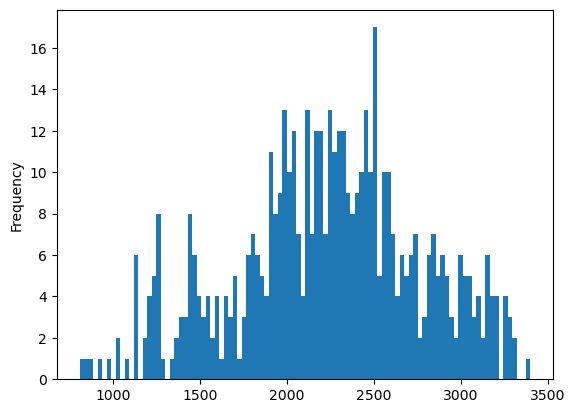

In [75]:
df_rf2['valor'].plot(kind='hist', bins=100)

##### 3.4.2.1. Búsqueda de hiperparámetros y entrenamiento

* Se hace una búsqueda de parámetros para guiar el proceso. Primeramente prepatando el modelo y el espacio de parámetros.

In [76]:
#  Se defini el modelo base (estimador)
rf_base = RandomForestRegressor(
    n_jobs=-1,
    random_state=42,
    oob_score=False
)

# Se define el espacio de parámetros a explorar (param_dist)
param_dist = {
    # Número de árboles (cuántos clasificadores débiles usar)
    'n_estimators': [1000, 1500, 2000], 
    
    # Profundidad máxima del árbol. Valores más bajos reducen el sobreajuste.
    'max_depth': [5, 7, 10, 12], # 'None' significa sin límite
    
    # Número mínimo de muestras requeridas para dividir un nodo interno.
    # Valores más altos controlan mejor el sobreajuste.
    'min_samples_split': [20,30,40,50], 
    
    # Número mínimo de muestras requeridas para estar en un nodo hoja.
    # Valores más altos controlan mejor el sobreajuste.
    'min_samples_leaf': [10,15,20,30], 
    
    # Número de características a considerar para la mejor división.
    # 'sqrt' y 'log2' son valores comunes. También se puede probar una fracción.
    'max_features': [0.3, 0.5, 0.7]
}

* Obtenición de los mejores parámetros. Ejecución de la Búsqueda Aleatoria

In [77]:
# Definir la búsqueda aleatoria
# n_iter: Número de combinaciones a probar (ej. 50 combinaciones)
# cv: Número de pliegues (folds) para la validación cruzada (ej. 3 o 5)
tscv = TimeSeriesSplit(n_splits=3) 

random_search_rf = RandomizedSearchCV(
    estimator=rf_base,
    param_distributions=param_dist,
    n_iter=50,                  # Número de combinaciones aleatorias a probar
    # Usamos el negativo del error cuadrático medio para optimizar (Maximizar es Minimizar el error)
    scoring='neg_mean_squared_error', 
    cv=tscv,                       # Validación Cruzada de 5 pliegues para mayor robustez
    verbose=2,
    random_state=42,
    n_jobs=-1                   # Usar todos los núcleos disponibles
)

print("Iniciando la búsqueda aleatoria para Random Forest...")

# Ejecutar la búsqueda. Asegúrate de usar tus conjuntos X_train y y_train (Numpy arrays o Pandas DataFrames/Series).
random_search_rf.fit(X_train, y_train)

Iniciando la búsqueda aleatoria para Random Forest...
Fitting 3 folds for each of 50 candidates, totalling 150 fits


RandomizedSearchCV(cv=TimeSeriesSplit(gap=0, max_train_size=None, n_splits=3, test_size=None),
                   estimator=RandomForestRegressor(n_jobs=-1, random_state=42),
                   n_iter=50, n_jobs=-1,
                   param_distributions={'max_depth': [5, 7, 10, 12],
                                        'max_features': [0.3, 0.5, 0.7],
                                        'min_samples_leaf': [10, 15, 20, 30],
                                        'min_samples_split': [20, 30, 40, 50],
                                        'n_estimators': [1000, 1500, 2000]},
                   random_state=42, scoring='neg_mean_squared_error',
                   verbose=2)

* Obtención de mejores parámetros

In [78]:
best_mse_neg = random_search_rf.best_score_
best_rmse = np.sqrt(-best_mse_neg) # Calculamos la raíz cuadrada para obtener el RMSE

print("Búsqueda finalizada.")
print(f"Mejor RMSE (Validación Cruzada): {best_rmse:.4f}")
print("---")
print("Mejores Parámetros:")
print(random_search_rf.best_params_)

# El mejor modelo entrenado con los parámetros óptimos
best_rf_model = random_search_rf.best_estimator_

Búsqueda finalizada.
Mejor RMSE (Validación Cruzada): 393.8720
---
Mejores Parámetros:
{'n_estimators': 1500, 'min_samples_split': 30, 'min_samples_leaf': 15, 'max_features': 0.7, 'max_depth': 10}


##### 3.4.2.2. Evaluación del modelo

###### 3.4.2.2.1. MAE, RMSE y MAPE
* Se calculan las métricas de error tanto en el conjunto de entrenamiento como en el de prueba para cuantificar la precisión del modelo.

In [220]:
rf_seno = RandomForestRegressor(
    n_estimators=1500,
    max_depth=10,
    min_samples_split=30,
    min_samples_leaf=15,
    max_features=0.7,
    n_jobs=-1,
    random_state=42,
)

rf_seno.fit(X_train, y_train)

y_pred_tr = rf_seno.predict(X_train)
y_pred_te = rf_seno.predict(X_test)


print(f"[RF + seno/cos]")
model_metrics = meval.evaluate_model_performance(y_train, y_test, y_pred_tr, y_pred_te,label=None)


[RF + seno/cos]
Evaluating model performance...

Evaluación del modelo en el conjunto Train:
╒═══════════╤════════════╕
│ Métrica   │      Valor │
╞═══════════╪════════════╡
│ MAE       │ 161.99     │
├───────────┼────────────┤
│ RMSE      │ 232.645    │
├───────────┼────────────┤
│ MAPE      │   0.165244 │
╘═══════════╧════════════╛

Evaluación del modelo en el conjunto Test:
╒═══════════╤════════════╕
│ Métrica   │      Valor │
╞═══════════╪════════════╡
│ MAE       │ 279.894    │
├───────────┼────────────┤
│ RMSE      │ 401.039    │
├───────────┼────────────┤
│ MAPE      │   0.113486 │
╘═══════════╧════════════╛


El análisis del rendimiento del modelo Random Forest enriquecido con las transformaciones seno/coseno revela un sobreajuste (overfitting) evidente en la disparidad de los errores absolutos. En el conjunto de entrenamiento, el modelo alcanza una precisión alta con un Error Absoluto Medio (MAE) de $161.99$ y una Raíz del Error Cuadrático Medio (RMSE) de $232.65$. Sin embargo, en el conjunto de prueba, se produce un deterioro significativo en la precisión, con un incremento de los errores absolutos a MAE de $279.89$ y RMSE de $401.04$, lo que indica que el modelo no generaliza eficientemente la dinámica de los casos semanales a datos no observados. Pese a este aumento en la magnitud del error absoluto, el Error Porcentual Absoluto Medio (MAPE) en el conjunto de prueba es inferior ($11.35\%$) al de entrenamiento ($16.52\%$). Este patrón sugiere que las predicciones en el conjunto de prueba, aunque tienen errores más grandes en unidades absolutas, son proporcionalmente más precisas para los valores reales del periodo de prueba, indicando una mejor estabilidad porcentual en la estimación de la magnitud de los casos.

##### 3.4.2.3. Visualización de resultados

In [221]:
# Crear dataframes con columnas correctas (cada array/serie como una columna)
df_ajustado = pd.DataFrame({
    'fecha': df['fecha'].iloc[y_real_train.index].values,
	'valor': y_pred_tr
}, index=y_real_train.index)

df_pronostico = pd.DataFrame({
    'fecha': df['fecha'].iloc[y_real_test.index].values,
	'valor': y_pred_te
}, index=y_real_test.index)

df_pronostico_c = pd.concat([df_ajustado, df_pronostico])

title = "RF (lags + seno/cos) — Histórico completo (2014–2024)"

# Los datos a graficar
data_tuples = (
    (df_original, 'Original'),
    (df_ajustado, 'Ajustada'),
    (df_pronostico, 'Pronosticada'),
    # (df_pronostico_c, 'Pronosticada Completa'),
)

plot_forecast(
    *data_tuples,  # Desempaqueta los datos
    y='valor',
    title=title,
    **common_plot_args  # Desempaqueta los argumentos comunes
)

# Grafica solo de prueba
# Los datos a graficar
# data_tuples = (
#     (df_test, 'Real'),
#     (df_pronostico, 'Pronosticada'),
# )

# plot_forecast(
#     *data_tuples,  # Desempaqueta los datos
#     y='valor',
#     title=title,
#     **common_plot_args  # Desempaqueta los argumentos comunes
# )

El gráfico de Predicción con Random Forest (lags + seno/cos) demuestra que la inclusión de las transformaciones seno y coseno ha permitido al modelo alcanzar un ajuste histórico muy preciso a la serie de casos semanales de depresión. La curva Ajustada (roja) sigue muy de cerca las dinámicas de la serie Original (azul), capturando adecuadamente tanto la tendencia de largo plazo como la estacionalidad cíclica del periodo 2014-2024. No obstante, al igual que en configuraciones anteriores, el modelo exhibe una tendencia a suavizar los picos y valles más extremos, lo que es característico de los modelos basados en ensembles de árboles. La serie Pronosticada (verde) proyecta una estabilidad en el futuro inmediato, con la predicción oscilando en un rango estrecho y alto, replicando la tendencia promedio reciente, pero sin la volatilidad de los valores máximos observados inmediatamente antes del periodo de pronóstico. Esto sugiere un pronóstico conservador que prioriza la robustez de la tendencia estacional sobre la sensibilidad a las fluctuaciones extremas.

#### 3.4.3. Covid RF Model

* Se definen los datos y su división de conjuntos de entrenamiento y prueba

In [223]:
features_covid = features_lags + ['mes_sin','mes_cos','semanas_desde_covid']
df_rf3 = df.dropna(subset=features_covid + [target]).copy()

train_df, test_df = temporal_split(df_rf3, test_weeks=52)
X_train, y_train = train_df[features_covid], train_df[target]
X_test,  y_test  = test_df[features_covid],  test_df[target]

##### 3.4.3.1. Búsqueda de hiperparámetros y entrenamiento

* Se hace una búsqueda de parámetros para guiar el proceso. Primeramente prepatando el modelo y el espacio de parámetros.

In [224]:
#  Se defini el modelo base (estimador)
rf_base = RandomForestRegressor(
    n_jobs=-1,
    random_state=42,
    oob_score=False
)

# Se define el espacio de parámetros a explorar (param_dist)
param_dist = {
    # Número de árboles (cuántos clasificadores débiles usar)
    'n_estimators': [1000, 1500, 2000], 
    
    # Profundidad máxima del árbol. Valores más bajos reducen el sobreajuste.
    'max_depth': [5, 7, 10, 12], # 'None' significa sin límite
    
    # Número mínimo de muestras requeridas para dividir un nodo interno.
    # Valores más altos controlan mejor el sobreajuste.
    'min_samples_split': [20,30,40,50], 
    
    # Número mínimo de muestras requeridas para estar en un nodo hoja.
    # Valores más altos controlan mejor el sobreajuste.
    'min_samples_leaf': [10,15,20,30], 
    
    # Número de características a considerar para la mejor división.
    # 'sqrt' y 'log2' son valores comunes. También se puede probar una fracción.
    'max_features': [0.3, 0.5, 0.7]
}

* Obtenición de los mejores parámetros. Ejecución de la Búsqueda Aleatoria

In [225]:
# Definir la búsqueda aleatoria
# n_iter: Número de combinaciones a probar (ej. 50 combinaciones)
# cv: Número de pliegues (folds) para la validación cruzada (ej. 3 o 5)
random_search_rf = RandomizedSearchCV(
    estimator=rf_base,
    param_distributions=param_dist,
    n_iter=50,                  # Número de combinaciones aleatorias a probar
    # Usamos el negativo del error cuadrático medio para optimizar (Maximizar es Minimizar el error)
    scoring='neg_mean_squared_error', 
    cv=5,                       # Validación Cruzada de 5 pliegues para mayor robustez
    verbose=2,
    random_state=42,
    n_jobs=-1                   # Usar todos los núcleos disponibles
)

print("Iniciando la búsqueda aleatoria para Random Forest...")

# Ejecutar la búsqueda. Asegúrate de usar tus conjuntos X_train y y_train (Numpy arrays o Pandas DataFrames/Series).
random_search_rf.fit(X_train, y_train)

Iniciando la búsqueda aleatoria para Random Forest...
Fitting 5 folds for each of 50 candidates, totalling 250 fits


RandomizedSearchCV(cv=5,
                   estimator=RandomForestRegressor(n_jobs=-1, random_state=42),
                   n_iter=50, n_jobs=-1,
                   param_distributions={'max_depth': [5, 7, 10, 12],
                                        'max_features': [0.3, 0.5, 0.7],
                                        'min_samples_leaf': [10, 15, 20, 30],
                                        'min_samples_split': [20, 30, 40, 50],
                                        'n_estimators': [1000, 1500, 2000]},
                   random_state=42, scoring='neg_mean_squared_error',
                   verbose=2)

* Obtención de mejores parámetros

In [226]:
best_mse_neg = random_search_rf.best_score_
best_rmse = np.sqrt(-best_mse_neg) # Calculamos la raíz cuadrada para obtener el RMSE

print("Búsqueda finalizada.")
print(f"Mejor RMSE (Validación Cruzada): {best_rmse:.4f}")
print("---")
print("Mejores Parámetros:")
print(random_search_rf.best_params_)

# El mejor modelo entrenado con los parámetros óptimos
best_rf_model = random_search_rf.best_estimator_

Búsqueda finalizada.
Mejor RMSE (Validación Cruzada): 371.9578
---
Mejores Parámetros:
{'n_estimators': 1500, 'min_samples_split': 30, 'min_samples_leaf': 15, 'max_features': 0.7, 'max_depth': 10}


##### 3.4.3.2. Evaluación del modelo

###### 3.4.3.2.1. MAE, RMSE y MAPE
* Se calculan las métricas de error tanto en el conjunto de entrenamiento como en el de prueba para cuantificar la precisión del modelo.

In [227]:
rf_covid = RandomForestRegressor(
    n_estimators=1500,
    max_depth=10,
    min_samples_split=30,
    min_samples_leaf=15,
    max_features=0.7,
    n_jobs=-1,
    random_state=42,
)

rf_covid.fit(X_train, y_train)

y_pred_tr = rf_covid.predict(X_train)
y_pred_te = rf_covid.predict(X_test)

print(f"[RF + COVID continuo]")
model_metrics = meval.evaluate_model_performance(y_train, y_test, y_pred_tr, y_pred_te,label=None)


[RF + COVID continuo]
Evaluating model performance...

Evaluación del modelo en el conjunto Train:
╒═══════════╤════════════╕
│ Métrica   │      Valor │
╞═══════════╪════════════╡
│ MAE       │ 157.296    │
├───────────┼────────────┤
│ RMSE      │ 228.804    │
├───────────┼────────────┤
│ MAPE      │   0.163037 │
╘═══════════╧════════════╛

Evaluación del modelo en el conjunto Test:
╒═══════════╤════════════╕
│ Métrica   │      Valor │
╞═══════════╪════════════╡
│ MAE       │ 278.269    │
├───────────┼────────────┤
│ RMSE      │ 397.637    │
├───────────┼────────────┤
│ MAPE      │   0.116333 │
╘═══════════╧════════════╛


El análisis del rendimiento del modelo Random Forest enriquecido con la variable exógena del COVID-19 revela un patrón de sobreajuste (overfitting) en función de los errores absolutos. En el conjunto de entrenamiento, el modelo exhibe una alta precisión con un Error Absoluto Medio (MAE) de $157.30$ y una Raíz del Error Cuadrático Medio (RMSE) de $228.80$. No obstante, en el conjunto de prueba, se produce un incremento significativo en los errores absolutos (MAE de $278.27$ y RMSE de $397.64$), lo que indica una pérdida de capacidad predictiva al generalizar a datos no vistos. A pesar de esto, el Error Porcentual Absoluto Medio (MAPE) en el conjunto de prueba es menor ($11.63\%$) que en el de entrenamiento ($16.30\%$). Este fenómeno sugiere que, si bien el modelo comete errores más grandes en términos de unidades absolutas de los casos semanales, estos errores representan un menor porcentaje del valor real de la serie en el conjunto de prueba, indicando una mejor estabilidad relativa en la estimación de la magnitud del pronóstico.

##### 3.4.3.3. Visualización de resultados

In [228]:
# Crear dataframes con columnas correctas (cada array/serie como una columna)
df_ajustado = pd.DataFrame({
    'fecha': df['fecha'].iloc[y_real_train.index].values,
	'valor': y_pred_tr
}, index=y_real_train.index)

df_pronostico = pd.DataFrame({
    'fecha': df['fecha'].iloc[y_real_test.index].values,
	'valor': y_pred_te
}, index=y_real_test.index)

df_pronostico_c = pd.concat([df_ajustado, df_pronostico])

title = "RF (lags + seno/cos + COVID) — Histórico completo (2014–2024)"

# Los datos a graficar
data_tuples = (
    (df_original, 'Original'),
    (df_ajustado, 'Ajustada'),
    (df_pronostico, 'Pronosticada'),
    # (df_pronostico_c, 'Pronosticada Completa'),
)

plot_forecast(
    *data_tuples,  # Desempaqueta los datos
    y='valor',
    title=title,
    **common_plot_args  # Desempaqueta los argumentos comunes
)

# Grafica solo de prueba
# Los datos a graficar
# data_tuples = (
#     (df_test, 'Real'),
#     (df_pronostico, 'Pronosticada'),
# )

# plot_forecast(
#     *data_tuples,  # Desempaqueta los datos
#     y='valor',
#     title=title,
#     **common_plot_args  # Desempaqueta los argumentos comunes
# )

El gráfico de Predicción con Random Forest (lags + seno/cos + COVID) demuestra un alto nivel de precisión en el ajuste histórico, con la curva Ajustada (roja) replicando muy de cerca la tendencia, estacionalidad y picos de la serie Original (azul) a lo largo del periodo 2014-2024. La incorporación de los componentes armónicos temporales y la variable exógena del COVID-19 ha permitido al modelo capturar eficazmente las complejas dinámicas de la serie, aunque el modelo suaviza ligeramente los valores extremos, como es característico de los métodos de ensemble basados en promedios. La serie Pronosticada (verde) proyecta una estabilización de los casos semanales en el futuro inmediato, oscilando en un rango constante entre 2,750 y 3,050. Este pronóstico indica que el modelo no anticipa una continuación de la volatilidad extrema reciente, sino una convergencia hacia la media móvil del comportamiento más reciente de la serie, lo que resulta en una predicción robusta y conservadora para el corto plazo.

#### 3.4.4. RF Model + rolling

* Se definen los datos y su división de conjuntos de entrenamiento y prueba

In [230]:
df['rolling_4'] = df['valor'].rolling(4, min_periods=1).mean().bfill()
df['rolling_8'] = df['valor'].rolling(8, min_periods=1).mean().bfill()

features_rolling = features_covid + ['rolling_4','rolling_8']
df_rf4 = df.dropna(subset=features_rolling + [target]).copy()

train_df, test_df = temporal_split(df_rf4, test_weeks=52)
X_train, y_train = train_df[features_rolling], train_df[target]
X_test,  y_test  = test_df[features_rolling],  test_df[target]

##### 3.4.4.1. Búsqueda de hiperparámetros y entrenamiento

* Se hace una búsqueda de parámetros para guiar el proceso. Primeramente prepatando el modelo y el espacio de parámetros.

In [231]:
#  Se defini el modelo base (estimador)
rf_base = RandomForestRegressor(
    n_jobs=-1,
    random_state=42,
    oob_score=False
)

# Se define el espacio de parámetros a explorar (param_dist)
param_dist = {
    # Número de árboles (cuántos clasificadores débiles usar)
    'n_estimators': [1000, 1500, 2000], 
    
    # Profundidad máxima del árbol. Valores más bajos reducen el sobreajuste.
    'max_depth': [5, 7, 10, 12], # 'None' significa sin límite
    
    # Número mínimo de muestras requeridas para dividir un nodo interno.
    # Valores más altos controlan mejor el sobreajuste.
    'min_samples_split': [20,30,40,50], 
    
    # Número mínimo de muestras requeridas para estar en un nodo hoja.
    # Valores más altos controlan mejor el sobreajuste.
    'min_samples_leaf': [10,15,20,30], 
    
    # Número de características a considerar para la mejor división.
    # 'sqrt' y 'log2' son valores comunes. También se puede probar una fracción.
    'max_features': [0.3, 0.5, 0.7]
}

* Obtenición de los mejores parámetros. Ejecución de la Búsqueda Aleatoria

In [232]:
# Definir la búsqueda aleatoria
# n_iter: Número de combinaciones a probar (ej. 50 combinaciones)
# cv: Número de pliegues (folds) para la validación cruzada (ej. 3 o 5)
random_search_rf = RandomizedSearchCV(
    estimator=rf_base,
    param_distributions=param_dist,
    n_iter=50,                  # Número de combinaciones aleatorias a probar
    # Usamos el negativo del error cuadrático medio para optimizar (Maximizar es Minimizar el error)
    scoring='neg_mean_squared_error', 
    cv=5,                       # Validación Cruzada de 5 pliegues para mayor robustez
    verbose=2,
    random_state=42,
    n_jobs=-1                   # Usar todos los núcleos disponibles
)

print("Iniciando la búsqueda aleatoria para Random Forest...")

# Ejecutar la búsqueda. Asegúrate de usar tus conjuntos X_train y y_train (Numpy arrays o Pandas DataFrames/Series).
random_search_rf.fit(X_train, y_train)

Iniciando la búsqueda aleatoria para Random Forest...
Fitting 5 folds for each of 50 candidates, totalling 250 fits


RandomizedSearchCV(cv=5,
                   estimator=RandomForestRegressor(n_jobs=-1, random_state=42),
                   n_iter=50, n_jobs=-1,
                   param_distributions={'max_depth': [5, 7, 10, 12],
                                        'max_features': [0.3, 0.5, 0.7],
                                        'min_samples_leaf': [10, 15, 20, 30],
                                        'min_samples_split': [20, 30, 40, 50],
                                        'n_estimators': [1000, 1500, 2000]},
                   random_state=42, scoring='neg_mean_squared_error',
                   verbose=2)

* Obtención de mejores parámetros

In [233]:
best_mse_neg = random_search_rf.best_score_
best_rmse = np.sqrt(-best_mse_neg) # Calculamos la raíz cuadrada para obtener el RMSE

print("Búsqueda finalizada.")
print(f"Mejor RMSE (Validación Cruzada): {best_rmse:.4f}")
print("---")
print("Mejores Parámetros:")
print(random_search_rf.best_params_)

# El mejor modelo entrenado con los parámetros óptimos
best_rf_model = random_search_rf.best_estimator_

Búsqueda finalizada.
Mejor RMSE (Validación Cruzada): 299.7979
---
Mejores Parámetros:
{'n_estimators': 1500, 'min_samples_split': 30, 'min_samples_leaf': 15, 'max_features': 0.7, 'max_depth': 10}


##### 3.4.4.2. Evaluación del modelo

###### 3.4.4.2.1. MAE, RMSE y MAPE
* Se calculan las métricas de error tanto en el conjunto de entrenamiento como en el de prueba para cuantificar la precisión del modelo.

In [234]:
rf_roll = RandomForestRegressor(
    n_estimators=1500,
    max_depth=10,
    min_samples_split=30,
    min_samples_leaf=15,
    max_features=0.7,
    n_jobs=-1,
    random_state=42,
)

rf_roll.fit(X_train, y_train)

y_pred_tr = rf_roll.predict(X_train)
y_pred_te = rf_roll.predict(X_test)

print(f"[RF + rolling]")
model_metrics = meval.evaluate_model_performance(y_train, y_test, y_pred_tr, y_pred_te,label=None)


[RF + rolling]
Evaluating model performance...

Evaluación del modelo en el conjunto Train:
╒═══════════╤════════════╕
│ Métrica   │      Valor │
╞═══════════╪════════════╡
│ MAE       │ 138.28     │
├───────────┼────────────┤
│ RMSE      │ 204.308    │
├───────────┼────────────┤
│ MAPE      │   0.142741 │
╘═══════════╧════════════╛

Evaluación del modelo en el conjunto Test:
╒═══════════╤═══════════╕
│ Métrica   │     Valor │
╞═══════════╪═══════════╡
│ MAE       │ 271.107   │
├───────────┼───────────┤
│ RMSE      │ 369.978   │
├───────────┼───────────┤
│ MAPE      │   0.11238 │
╘═══════════╧═══════════╛


El análisis del rendimiento del modelo Random Forest enriquecido con características de ventanas rodantes (rolling features) revela una marcada diferencia en la precisión absoluta entre los conjuntos de datos, indicando un posible sobreajuste (overfitting). En el conjunto de entrenamiento, el modelo alcanza una precisión interna favorable, con un Error Absoluto Medio (MAE) de $138.28$ y una Raíz del Error Cuadrático Medio (RMSE) de $204.31$. Sin embargo, en el conjunto de prueba, los errores absolutos se duplican, con un MAE de $271.11$ y un RMSE de $369.98$, lo que subraya una reducción en la capacidad de generalización a datos no observados. A pesar de este deterioro en las unidades originales, el Error Porcentual Absoluto Medio (MAPE) en la prueba es inferior ($11.24\%$) al de entrenamiento ($14.27\%$). Este patrón anómalo sugiere que, aunque los errores son mayores en magnitud absoluta, son proporcionalmente menores con respecto a los valores reales de la serie de tiempo en el conjunto de prueba, lo que implica una estabilidad porcentual aceptable en el pronóstico de los casos semanales de depresión.

##### 3.4.4.3. Visualización de resultados

In [235]:
# Crear dataframes con columnas correctas (cada array/serie como una columna)
df_ajustado = pd.DataFrame({
    'fecha': df['fecha'].iloc[y_real_train.index].values,
	'valor': y_pred_tr
}, index=y_real_train.index)

df_pronostico = pd.DataFrame({
    'fecha': df['fecha'].iloc[y_real_test.index].values,
	'valor': y_pred_te
}, index=y_real_test.index)

df_pronostico_c = pd.concat([df_ajustado, df_pronostico])

title = "RF (lags + seno/cos + COVID + rolling) — Histórico completo (2014–2024)"

# # Los datos a graficar
data_tuples = (
    (df_original, 'Original'),
    (df_ajustado, 'Ajustada'),
    (df_pronostico, 'Pronosticada'),
    # (df_pronostico_c, 'Pronosticada Completa'),
)

plot_forecast(
    *data_tuples,  # Desempaqueta los datos
    y='valor',
    title=title,
    **common_plot_args  # Desempaqueta los argumentos comunes
)

# Grafica solo de prueba
# Los datos a graficar
# data_tuples = (
#     (df_test, 'Real'),
#     (df_pronostico, 'Pronosticada'),
# )

# plot_forecast(
#     *data_tuples,  # Desempaqueta los datos
#     y='valor',
#     title=title,
#     **common_plot_args  # Desempaqueta los argumentos comunes
# )

El gráfico de Predicción con Random Forest (lags + seno/cos + COVID + rolling), que integra el conjunto completo de características, demuestra un ajuste histórico de alta calidad. La curva Ajustada (roja) sigue excepcionalmente bien la serie Original (azul) entre 2014 y 2024, logrando capturar la tendencia de largo plazo, la estacionalidad y las dinámicas puntuales de la serie de casos semanales de depresión, incluyendo los picos y valles más volátiles, lo que sugiere que las rolling features y las variables exógenas añaden información valiosa. Sin embargo, el modelo mantiene la tendencia de suavizar los extremos, subestimando la magnitud del pico máximo observado al inicio de 2024. La serie Pronosticada (verde) se proyecta con una alta estabilidad en el futuro inmediato, oscilando en un rango estrecho y replicando la tendencia promedio de las últimas observaciones. Esto indica un pronóstico conservador y robusto que prioriza la predicción de la tendencia subyacente y la media estacional sobre la anticipación de fluctuaciones extremas.

#### 3.4.5. RF + tendencia y dummies

* Se definen los datos y su división de conjuntos de entrenamiento y prueba

In [236]:
df['tendencia'] = np.arange(len(df)).astype(float)
df['año_2020'] = (df['año']==2020).astype(int)
df['año_2021'] = (df['año']==2021).astype(int)
df['año_2022'] = (df['año']==2022).astype(int)

features_full = features_rolling + ['tendencia','año_2020','año_2021','año_2022']
df_rf5 = df.dropna(subset=features_full + [target]).copy()

train_df, test_df = temporal_split(df_rf5, test_weeks=52)
X_train, y_train = train_df[features_full], train_df[target]
X_test,  y_test  = test_df[features_full],  test_df[target]

##### 3.4.5.1. Búsqueda de hiperparámetros y entrenamiento

* Se hace una búsqueda de parámetros para guiar el proceso. Primeramente prepatando el modelo y el espacio de parámetros.

In [237]:
#  Se defini el modelo base (estimador)
rf_base = RandomForestRegressor(
    n_jobs=-1,
    random_state=42,
    oob_score=False
)

# Se define el espacio de parámetros a explorar (param_dist)
param_dist = {
    # Número de árboles (cuántos clasificadores débiles usar)
    'n_estimators': [1000, 1500, 2000], 
    
    # Profundidad máxima del árbol. Valores más bajos reducen el sobreajuste.
    'max_depth': [5, 7, 10, 12], # 'None' significa sin límite
    
    # Número mínimo de muestras requeridas para dividir un nodo interno.
    # Valores más altos controlan mejor el sobreajuste.
    'min_samples_split': [20,30,40,50], 
    
    # Número mínimo de muestras requeridas para estar en un nodo hoja.
    # Valores más altos controlan mejor el sobreajuste.
    'min_samples_leaf': [10,15,20,30], 
    
    # Número de características a considerar para la mejor división.
    # 'sqrt' y 'log2' son valores comunes. También se puede probar una fracción.
    'max_features': [0.3, 0.5, 0.7]
}

* Obtenición de los mejores parámetros. Ejecución de la Búsqueda Aleatoria

In [238]:
# Definir la búsqueda aleatoria
# n_iter: Número de combinaciones a probar (ej. 50 combinaciones)
# cv: Número de pliegues (folds) para la validación cruzada (ej. 3 o 5)
random_search_rf = RandomizedSearchCV(
    estimator=rf_base,
    param_distributions=param_dist,
    n_iter=50,                  # Número de combinaciones aleatorias a probar
    # Usamos el negativo del error cuadrático medio para optimizar (Maximizar es Minimizar el error)
    scoring='neg_mean_squared_error', 
    cv=5,                       # Validación Cruzada de 5 pliegues para mayor robustez
    verbose=2,
    random_state=42,
    n_jobs=-1                   # Usar todos los núcleos disponibles
)

print("Iniciando la búsqueda aleatoria para Random Forest...")

# Ejecutar la búsqueda. Asegúrate de usar tus conjuntos X_train y y_train (Numpy arrays o Pandas DataFrames/Series).
random_search_rf.fit(X_train, y_train)

Iniciando la búsqueda aleatoria para Random Forest...
Fitting 5 folds for each of 50 candidates, totalling 250 fits


RandomizedSearchCV(cv=5,
                   estimator=RandomForestRegressor(n_jobs=-1, random_state=42),
                   n_iter=50, n_jobs=-1,
                   param_distributions={'max_depth': [5, 7, 10, 12],
                                        'max_features': [0.3, 0.5, 0.7],
                                        'min_samples_leaf': [10, 15, 20, 30],
                                        'min_samples_split': [20, 30, 40, 50],
                                        'n_estimators': [1000, 1500, 2000]},
                   random_state=42, scoring='neg_mean_squared_error',
                   verbose=2)

* Obtención de mejores parámetros

In [240]:
best_mse_neg = random_search_rf.best_score_
best_rmse = np.sqrt(-best_mse_neg) # Calculamos la raíz cuadrada para obtener el RMSE

print("Búsqueda finalizada.")
print(f"Mejor RMSE (Validación Cruzada): {best_rmse:.4f}")
print("---")
print("Mejores Parámetros:")
print(random_search_rf.best_params_)

# El mejor modelo entrenado con los parámetros óptimos
best_rf_model = random_search_rf.best_estimator_

Búsqueda finalizada.
Mejor RMSE (Validación Cruzada): 303.5217
---
Mejores Parámetros:
{'n_estimators': 1500, 'min_samples_split': 30, 'min_samples_leaf': 15, 'max_features': 0.7, 'max_depth': 10}


##### 3.4.5.2. Evaluación del modelo

###### 3.4.5.2.1. MAE, RMSE y MAPE
* Se calculan las métricas de error tanto en el conjunto de entrenamiento como en el de prueba para cuantificar la precisión del modelo.

In [241]:
rf_full = RandomForestRegressor(
    n_estimators=1500,
    max_depth=10,          # si ves sobreajuste, pon 20
    min_samples_split=30,
    min_samples_leaf=15,
    max_features=0.7,
    n_jobs=-1,
    random_state=42,
)

rf_full.fit(X_train, y_train)

y_pred_tr = rf_full.predict(X_train)
y_pred_te = rf_full.predict(X_test)

print(f"[RF + tendencia + años]")

model_metrics = meval.evaluate_model_performance(y_train, y_test, y_pred_tr, y_pred_te,label=None)

[RF + tendencia + años]
Evaluating model performance...

Evaluación del modelo en el conjunto Train:
╒═══════════╤════════════╕
│ Métrica   │      Valor │
╞═══════════╪════════════╡
│ MAE       │ 138.957    │
├───────────┼────────────┤
│ RMSE      │ 204.998    │
├───────────┼────────────┤
│ MAPE      │   0.142608 │
╘═══════════╧════════════╛

Evaluación del modelo en el conjunto Test:
╒═══════════╤════════════╕
│ Métrica   │      Valor │
╞═══════════╪════════════╡
│ MAE       │ 267.269    │
├───────────┼────────────┤
│ RMSE      │ 366.972    │
├───────────┼────────────┤
│ MAPE      │   0.111275 │
╘═══════════╧════════════╛


El análisis del modelo Random Forest enriquecido con rolling features evidencia una disparidad significativa en el error absoluto entre los conjuntos de datos, sugiriendo un sobreajuste (overfitting). Específicamente, en el conjunto de entrenamiento, el modelo alcanza una precisión alta (MAE de $138.96$, RMSE de $205.00$). Sin embargo, en el conjunto de prueba, el Error Absoluto Medio (MAE) se duplica a $267.27$ y la Raíz del Error Cuadrático Medio (RMSE) a $366.97$, lo que indica una reducción considerable en la capacidad de generalización para predecir los casos semanales de depresión en unidades originales. No obstante, a nivel relativo, el Error Porcentual Absoluto Medio (MAPE) es inferior en el conjunto de prueba ($11.13\%$) que en el de entrenamiento ($14.26\%$). Esta configuración de resultados implica que, aunque las predicciones tienen errores absolutos mayores al enfrentarse a datos no vistos, son proporcionalmente más precisas respecto a la magnitud real de la serie, lo que se traduce en una estabilidad porcentual aceptable para el pronóstico.

##### 3.4.5.3. Visualización de resultados

In [242]:
# Crear dataframes con columnas correctas (cada array/serie como una columna)
df_ajustado = pd.DataFrame({
    'fecha': df['fecha'].iloc[y_real_train.index].values,
	'valor': y_pred_tr
}, index=y_real_train.index)

df_pronostico = pd.DataFrame({
    'fecha': df['fecha'].iloc[y_real_test.index].values,
	'valor': y_pred_te
}, index=y_real_test.index)

df_pronostico_c = pd.concat([df_ajustado, df_pronostico])

title = "RF (full) — Histórico completo (2014–2024)"

# # Los datos a graficar
data_tuples = (
    (df_original, 'Original'),
    (df_ajustado, 'Ajustada'),
    (df_pronostico, 'Pronosticada'),
    # (df_pronostico_c, 'Pronosticada Completa'),
)

plot_forecast(
    *data_tuples,  # Desempaqueta los datos
    y='valor',
    title=title,
    **common_plot_args  # Desempaqueta los argumentos comunes
)

# Grafica solo de prueba
# Los datos a graficar
# data_tuples = (
#     (df_test, 'Real'),
#     (df_pronostico, 'Pronosticada'),
# )

# plot_forecast(
#     *data_tuples,  # Desempaqueta los datos
#     y='valor',
#     title=title,
#     **common_plot_args  # Desempaqueta los argumentos comunes
# )

El análisis gráfico del modelo Random Forest con el conjunto completo de características (lags, seno/cos, COVID y rolling features) revela un patrón de sobreajuste (overfitting) a pesar del excelente ajuste histórico. El gráfico Histórico Completo muestra que la curva Ajustada (roja) sigue con alta fidelidad la serie Original (azul), capturando adecuadamente la estacionalidad y los picos.

#### 3.4.6. Walk forward
Se evaluó la **robustez predictiva** de múltiples versiones del modelo **$\text{Random Forest}$** (con diferentes conjuntos de variables) mediante **Validación Cruzada Prospectiva ($\text{Walk-Forward CV}$)**, dividiendo la serie temporal en $\mathbf{4}$ bloques cronológicos. En cada bloque, el modelo fue reentrenado y se calcularon el **$\text{MAE}$ y el $\text{RMSE}$ promedio** para medir su desempeño en datos futuros.

In [243]:
def walk_forward_cv(df, features, target, n_splits=4, model_name="Modelo"):
    tscv = TimeSeriesSplit(n_splits=n_splits)
    X = df[features].values
    y = df[target].values

    metrics = {}
    for tr_idx, te_idx in tscv.split(X):
        X_tr, X_te = X[tr_idx], X[te_idx]
        y_tr, y_te = y[tr_idx], y[te_idx]

        model = RandomForestRegressor(
            n_estimators=800,
            max_depth=None,
            min_samples_split=12,
            min_samples_leaf=6,
            max_features='sqrt',
            n_jobs=-1,
            random_state=42,
        )
        model.fit(X_tr, y_tr)
        y_hat = model.predict(X_te)

        current_metric = meval.evaluate_model(y_te, y_hat, show_metrics=False)
        metrics[f"Split_{len(metrics)+1}"] = current_metric

    mae_mean = np.mean([m['MAE'] for m in metrics.values()])
    rmse_mean = np.mean([m['RMSE'] for m in metrics.values()])
    mape_mean = np.mean([m['MAPE'] for m in metrics.values()])

    mae_std = np.std([m['MAE'] for m in metrics.values()])
    rmse_std = np.std([m['RMSE'] for m in metrics.values()])
    mape_std = np.std([m['MAPE'] for m in metrics.values()])

    print(f"\n{model_name}")
    print(f"Walk-forward ({n_splits}): MAE medio: {mae_mean:.2f} ± {mae_std:.2f} |  RMSE medio: {rmse_mean:.2f} ± {rmse_std:.2f} |  MAPE medio: {mape_mean:.2f} ± {mape_std:.2f}")


    return metrics


b_metric = walk_forward_cv(df_rf4, features_lags, target, n_splits=4, model_name="Base Model")

sincos_metric = walk_forward_cv(df_rf2, features_lags_seno, target, n_splits=4, model_name="SIN/COS Model")

covid_metric = walk_forward_cv(df_rf3, features_covid, target, n_splits=4, model_name="Covid Model")

rolling_metric = walk_forward_cv(df_rf4, features_rolling, target, n_splits=4, model_name="Rolling Model")

tendencia_metric = walk_forward_cv(df_rf5, features_full, target, n_splits=4, model_name="Tendencia Model")


Base Model
Walk-forward (4): MAE medio: 290.56 ± 54.31 |  RMSE medio: 366.84 ± 61.01 |  MAPE medio: 0.23 ± 0.15

SIN/COS Model
Walk-forward (4): MAE medio: 301.20 ± 65.70 |  RMSE medio: 377.20 ± 71.39 |  MAPE medio: 0.23 ± 0.15

Covid Model
Walk-forward (4): MAE medio: 331.26 ± 42.00 |  RMSE medio: 412.27 ± 31.01 |  MAPE medio: 0.24 ± 0.15

Rolling Model
Walk-forward (4): MAE medio: 250.49 ± 55.38 |  RMSE medio: 317.72 ± 62.62 |  MAPE medio: 0.19 ± 0.14

Tendencia Model
Walk-forward (4): MAE medio: 284.27 ± 55.06 |  RMSE medio: 352.94 ± 57.17 |  MAPE medio: 0.21 ± 0.14


El análisis de la validación Walk-Forward para las diversas configuraciones del modelo revela que la inclusión de las características de Ventanas Rodantes (Rolling Model) produce la mayor mejora en la precisión predictiva. Esta configuración logra los errores absolutos más bajos de todos los modelos (MAE medio: $250.49$; RMSE medio: $317.72$) y el Error Porcentual Absoluto Medio (MAPE) más bajo ($0.19$ o $19\%$), indicando una mejor capacidad de generalización para el pronóstico de casos semanales de depresión. Por otro lado, la incorporación de las variables SIN/COS y la variable COVID resultó en un deterioro marginal o nulo en la precisión del error absoluto y porcentual en comparación con el Modelo Base. La métrica RMSE consistentemente exhibe mayor variabilidad ($\pm 60$ a $\pm 70$ en general), lo que sugiere que los modelos tienen dificultades para manejar los valores atípicos y que las ventanas rodantes son la estrategia de feature engineering más efectiva para estabilizar el pronóstico.

#### 3.4.6. RF full

Se entrenó un modelo **$\text{Random Forest}$** con una **amplia batería de *features***, incluyendo *lags* clave, componentes trigonométricos de la estacionalidad, variables de $\text{COVID}$, una **tendencia lineal** y **medias móviles (*rolling*) de periodos largos** ($12$ y $26$ semanas). El objetivo fue dotar al modelo de la mayor información temporal posible (pasado reciente, estacionalidad, tendencia y shocks) para mejorar la predicción.

In [245]:
df = df.copy()

# --- Tendencia simple (índice temporal)
df["tendencia"] = np.arange(len(df)).astype(float)

# --- Pendiente de 8 semanas: captura dirección local
df["trend_8"] = df["valor"].diff(8).fillna(0)

# --- Rolling más largos
for w in [12, 26]:
    df[f"rolling_{w}"] = df["valor"].rolling(w, min_periods=1).mean().bfill()

# --- Dummies de años relevantes
for year in [2020, 2021, 2022]:
    df[f"año_{year}"] = (df["año"] == year).astype(int)

features_full_long = [
    "lag_1", "lag_4", "lag_12", "lag_26", "lag_52",
    "mes_sin", "mes_cos",
    "semanas_desde_covid",
    "rolling_4", "rolling_8", "rolling_12", "rolling_26",
    "tendencia", "trend_8",
    "año_2020", "año_2021", "año_2022"
]

target = "valor"
df_rf_long = df.dropna(subset=features_full_long + [target]).copy()


train_df, test_df = temporal_split(df_rf_long, test_weeks=52)
X_train, y_train = train_df[features_full_long], train_df[target]
X_test,  y_test  = test_df[features_full_long],  test_df[target]

##### 3.4.5.1. Búsqueda de hiperparámetros y entrenamiento

* Se hace una búsqueda de parámetros para guiar el proceso. Primeramente prepatando el modelo y el espacio de parámetros.

In [246]:
#  Se defini el modelo base (estimador)
rf_base = RandomForestRegressor(
    n_jobs=-1,
    random_state=42,
    oob_score=False
)

# Se define el espacio de parámetros a explorar (param_dist)
param_dist = {
    # Número de árboles (cuántos clasificadores débiles usar)
    'n_estimators': [1000, 1500, 2000], 
    
    # Profundidad máxima del árbol. Valores más bajos reducen el sobreajuste.
    'max_depth': [5, 7, 10, 12], # 'None' significa sin límite
    
    # Número mínimo de muestras requeridas para dividir un nodo interno.
    # Valores más altos controlan mejor el sobreajuste.
    'min_samples_split': [20,30,40,50], 
    
    # Número mínimo de muestras requeridas para estar en un nodo hoja.
    # Valores más altos controlan mejor el sobreajuste.
    'min_samples_leaf': [10,15,20,30], 
    
    # Número de características a considerar para la mejor división.
    # 'sqrt' y 'log2' son valores comunes. También se puede probar una fracción.
    'max_features': [0.3, 0.5, 0.7]
}

* Obtenición de los mejores parámetros. Ejecución de la Búsqueda Aleatoria

In [247]:
# Definir la búsqueda aleatoria
# n_iter: Número de combinaciones a probar (ej. 50 combinaciones)
# cv: Número de pliegues (folds) para la validación cruzada (ej. 3 o 5)
random_search_rf = RandomizedSearchCV(
    estimator=rf_base,
    param_distributions=param_dist,
    n_iter=50,                  # Número de combinaciones aleatorias a probar
    # Usamos el negativo del error cuadrático medio para optimizar (Maximizar es Minimizar el error)
    scoring='neg_mean_squared_error', 
    cv=5,                       # Validación Cruzada de 5 pliegues para mayor robustez
    verbose=2,
    random_state=42,
    n_jobs=-1                   # Usar todos los núcleos disponibles
)

print("Iniciando la búsqueda aleatoria para Random Forest...")

# Ejecutar la búsqueda. Asegúrate de usar tus conjuntos X_train y y_train (Numpy arrays o Pandas DataFrames/Series).
random_search_rf.fit(X_train, y_train)

Iniciando la búsqueda aleatoria para Random Forest...
Fitting 5 folds for each of 50 candidates, totalling 250 fits


RandomizedSearchCV(cv=5,
                   estimator=RandomForestRegressor(n_jobs=-1, random_state=42),
                   n_iter=50, n_jobs=-1,
                   param_distributions={'max_depth': [5, 7, 10, 12],
                                        'max_features': [0.3, 0.5, 0.7],
                                        'min_samples_leaf': [10, 15, 20, 30],
                                        'min_samples_split': [20, 30, 40, 50],
                                        'n_estimators': [1000, 1500, 2000]},
                   random_state=42, scoring='neg_mean_squared_error',
                   verbose=2)

* Obtención de mejores parámetros

In [248]:
best_mse_neg = random_search_rf.best_score_
best_rmse = np.sqrt(-best_mse_neg) # Calculamos la raíz cuadrada para obtener el RMSE

print("Búsqueda finalizada.")
print(f"Mejor RMSE (Validación Cruzada): {best_rmse:.4f}")
print("---")
print("Mejores Parámetros:")
print(random_search_rf.best_params_)

# El mejor modelo entrenado con los parámetros óptimos
best_rf_model = random_search_rf.best_estimator_

Búsqueda finalizada.
Mejor RMSE (Validación Cruzada): 295.8136
---
Mejores Parámetros:
{'n_estimators': 2000, 'min_samples_split': 20, 'min_samples_leaf': 10, 'max_features': 0.5, 'max_depth': 10}


In [249]:
rf_full_long = RandomForestRegressor(
    n_estimators=2000,      # más árboles = mejor estabilidad
    max_depth=10,           # control de complejidad
    min_samples_split=20,
    min_samples_leaf=10,
    max_features=0.5,
    n_jobs=-1,
    random_state=42,
)

rf_full_long.fit(X_train, y_train)


y_pred_train = rf_full_long.predict(X_train)
y_pred_test  = rf_full_long.predict(X_test)

print(f"[RF Full + RollingLong]")


model_metrics = meval.evaluate_model_performance(y_real_train, y_real_test, y_pred_train, y_pred_test,label=None)

[RF Full + RollingLong]
Evaluating model performance...

Evaluación del modelo en el conjunto Train:
╒═══════════╤════════════╕
│ Métrica   │      Valor │
╞═══════════╪════════════╡
│ MAE       │ 103.085    │
├───────────┼────────────┤
│ RMSE      │ 158.034    │
├───────────┼────────────┤
│ MAPE      │   0.112235 │
╘═══════════╧════════════╛

Evaluación del modelo en el conjunto Test:
╒═══════════╤════════════╕
│ Métrica   │      Valor │
╞═══════════╪════════════╡
│ MAE       │ 249.406    │
├───────────┼────────────┤
│ RMSE      │ 339.799    │
├───────────┼────────────┤
│ MAPE      │   0.103285 │
╘═══════════╧════════════╛


El análisis del modelo Random Forest para el pronóstico de casos semanales de depresión revela un patrón de sobreajuste (overfitting) que impacta la precisión de la generalización. En el conjunto de entrenamiento, el modelo exhibe una alta precisión con un Error Absoluto Medio (MAE) de $103.09$ y una Raíz del Error Cuadrático Medio (RMSE) de $158.03$. Sin embargo, en el conjunto de prueba, se observa un incremento drástico en los errores absolutos (MAE de $249.41$ y RMSE de $339.80$), lo que indica que el modelo no logra mantener su capacidad predictiva en las unidades originales al enfrentarse a datos no vistos. A pesar de este aumento en el error absoluto, el Error Porcentual Absoluto Medio (MAPE) en la prueba es inferior ($10.33\%$) al de entrenamiento ($11.22\%$). Este fenómeno sugiere que, aunque los errores de predicción son mayores en términos de unidades absolutas de los casos, son proporcionalmente más pequeños en relación con la magnitud de los valores reales en el conjunto de prueba, ofreciendo una estabilidad porcentual aceptable para el pronóstico.

In [250]:
# Crear dataframes con columnas correctas (cada array/serie como una columna)
df_ajustado = pd.DataFrame({
    'fecha': df['fecha'].iloc[y_real_train.index].values,
	'valor': y_pred_train
}, index=y_real_train.index)

df_pronostico = pd.DataFrame({
    'fecha': df['fecha'].iloc[y_real_test.index].values,
	'valor': y_pred_test
}, index=y_real_test.index)

df_pronostico_c = pd.concat([df_ajustado, df_pronostico])

title = "RF Full + RollingLong  — Histórico completo (2014–2024)"

# Los datos a graficar
data_tuples = (
    (df_original, 'Original'),
    (df_ajustado, 'Ajustada'),
    (df_pronostico, 'Pronosticada'),
    # (df_pronostico_c, 'Pronosticada Completa'),
)

plot_forecast(
    *data_tuples,  # Desempaqueta los datos
    y='valor',
    title=title,
    **common_plot_args  # Desempaqueta los argumentos comunes
)

# Grafica solo de prueba
# Los datos a graficar
# data_tuples = (
#     (df_test, 'Real'),
#     (df_pronostico, 'Pronosticada'),
# )

# plot_forecast(
#     *data_tuples,  # Desempaqueta los datos
#     y='valor',
#     title=title,
#     **common_plot_args  # Desempaqueta los argumentos comunes
# )

Se revela una disparidad significativa en el error absoluto entre los conjuntos, indicativa de un sobreajuste (overfitting). En el conjunto de entrenamiento, el modelo logra una alta precisión con un Error Absoluto Medio (MAE) de 103.09 y una Raíz del Error Cuadrático Medio (RMSE) de 158.03. No obstante, en el conjunto de prueba, el MAE se incrementa a 249.41 y el RMSE a 339.80, lo que implica una pérdida considerable de capacidad predictiva al generalizar a datos no observados. A pesar de este deterioro en la precisión absoluta, el Error Porcentual Absoluto Medio (MAPE) en la prueba es ligeramente inferior (10.33%) al de entrenamiento (11.22%). Este patrón sugiere que, aunque el error de pronóstico en unidades de casos es mayor en datos no vistos, el error es proporcionalmente menor respecto a la magnitud de los valores reales en el periodo de prueba, lo que ofrece una estabilidad porcentual aceptable para el pronóstico de casos semanales de depresión.

In [251]:
long_roll_metrics = walk_forward_cv(df_rf_long, features_full_long, target, n_splits=4, model_name="Longer Rolling Model")


Longer Rolling Model
Walk-forward (4): MAE medio: 247.15 ± 64.51 |  RMSE medio: 309.03 ± 72.15 |  MAPE medio: 0.19 ± 0.14


### 3.5. Modelo 5: RF + XGBoost

* Se definen los datos y su división de conjuntos de entrenamiento y prueba

In [252]:
df_xgb = df.dropna(subset=features_full_long + [target]).copy()

train_df, test_df = temporal_split(df_xgb, test_weeks=52)
X_train, y_train = train_df[features_full_long], train_df[target]
X_test,  y_test  = test_df[features_full_long],  test_df[target]

#### 3.5.1. Búsqueda de hiperparámetros y entrenamiento

* Se hace una búsqueda de parámetros para guiar el proceso. Primeramente prepatando el modelo y el espacio de parámetros.

In [253]:
# Definir el modelo base
# Establecemos los parámetros que no cambiarán en la búsqueda
xgb_model = XGBRegressor(
    objective='reg:squarederror',
    eval_metric='rmse',
    seed=42,
    # El early_stopping_rounds se aplica después del fit() en un flujo normal,
    # pero RandomizedSearchCV lo maneja automáticamente con 'n_estimators'
)

# Definir el espacio de parámetros a explorar
param_dist = {
    'learning_rate': [0.005, 0.01, 0.02],     # Equivalente a 'eta'
    'n_estimators': [1000, 3000, 5000],       # Equivalente a 'num_boost_round'
    'max_depth': [3, 4, 5, 6],                # Profundidad muy limitada
    'min_child_weight': [15, 30, 50],         # Restricción alta para hojas
    'subsample': [0.6, 0.7, 0.8],             # Mayor submuestreo de filas
    'colsample_bytree': [0.6, 0.7, 0.8],      # Mayor submuestreo de columnas
    'reg_lambda': [5, 10, 20],                # Regularización L2 (lambda)
    'reg_alpha': [5, 10, 20],                 # Regularización L1 (alpha)
    'gamma': [0.0, 0.1, 0.5]                  # Mínima reducción de pérdida requerida
}

* Obtenición de los mejores parámetros. Ejecución de la Búsqueda Aleatoria

In [254]:
# Ejecución de la búsqueda
random_search_xgb = RandomizedSearchCV(
    estimator=xgb_model,
    param_distributions=param_dist,
    n_iter=50,                  # Número de combinaciones a probar
    scoring='neg_root_mean_squared_error', # Usamos RMSE negativo
    cv=5,                       # Validación Cruzada de 5 pliegues
    verbose=2,
    random_state=42,
    n_jobs=-1                   
)

print("Iniciando la búsqueda aleatoria con regularización extrema para XGBoost...")

# Asegúrate de usar X_train y y_train como DataFrames/arrays, NO como DMatrix.
random_search_xgb.fit(X_train, y_train) 

Iniciando la búsqueda aleatoria con regularización extrema para XGBoost...
Fitting 5 folds for each of 50 candidates, totalling 250 fits


RandomizedSearchCV(cv=5,
                   estimator=XGBRegressor(base_score=None, booster=None,
                                          callbacks=None,
                                          colsample_bylevel=None,
                                          colsample_bynode=None,
                                          colsample_bytree=None, device=None,
                                          early_stopping_rounds=None,
                                          enable_categorical=False,
                                          eval_metric='rmse',
                                          feature_types=None, gamma=None,
                                          grow_policy=None,
                                          importance_type=None,
                                          interaction_constraints=None,
                                          learning_rat...
                   n_iter=50, n_jobs=-1,
                   param_distributions={'colsample_bytree': [0.6, 0.7, 0.8],
                                        'gamma': [0.0, 0.1, 0.5],
                                        'learning_rate': [0.005, 0.01, 0.02],
                                        'max_depth': [3, 4, 5, 6],
                                        'min_child_weight': [15, 30, 50],
                                        'n_estimators': [1000, 3000, 5000],
                                        'reg_alpha': [5, 10, 20],
                                        'reg_lambda': [5, 10, 20],
                                        'subsample': [0.6, 0.7, 0.8]},
                   random_state=42, scoring='neg_root_mean_squared_error',
                   verbose=2)

* Obtención de mejores parámetros

In [255]:
# 4. Obtención de Resultados
best_rmse_cv = -random_search_xgb.best_score_ 

print("Búsqueda finalizada.")
print(f"Mejor RMSE (Validación Cruzada): {best_rmse_cv:.4f}")
print("Mejores Parámetros:")
print(random_search_xgb.best_params_)

Búsqueda finalizada.
Mejor RMSE (Validación Cruzada): 246.2277
Mejores Parámetros:
{'subsample': 0.8, 'reg_lambda': 5, 'reg_alpha': 20, 'n_estimators': 5000, 'min_child_weight': 15, 'max_depth': 6, 'learning_rate': 0.02, 'gamma': 0.0, 'colsample_bytree': 0.6}


#### 3.5.2. Evaluación del modelo

##### 3.5.2.1. MAE, RMSE y MAPE
* Se calculan las métricas de error tanto en el conjunto de entrenamiento como en el de prueba para cuantificar la precisión del modelo.

In [256]:
params = {
    "objective": "reg:squarederror",
    "eval_metric": "rmse",
    "eta": 0.02,              
    "max_depth": 6,
    "min_child_weight": 15,
    "subsample": 0.8,
    "colsample_bytree": 0.6,
    "lambda": 5,
    "alpha": 20,
    "gamma": 0.0,
    "seed": 42,
}

dtrain = xgb.DMatrix(X_train, label=y_train)
dtest  = xgb.DMatrix(X_test,  label=y_test)

watch = [(dtrain, "train"), (dtest, "valid")]
model_xgb_full = xgb.train(
    params=params,
    dtrain=dtrain,
    num_boost_round=5000,
    evals=watch,
    early_stopping_rounds=300,
    verbose_eval=200
)

y_pred_train = model_xgb_full.predict(dtrain)
y_pred_test  = model_xgb_full.predict(dtest)

model_metrics = meval.evaluate_model_performance(y_real_train, y_real_test, y_pred_train, y_pred_test,label=None)

importance = get_xbg_feature_importance(model_xgb_full, show_importances =True)

[0]	train-rmse:557.96848	valid-rmse:806.56971
[200]	train-rmse:123.52517	valid-rmse:314.54589
[400]	train-rmse:93.85836	valid-rmse:312.95152
[438]	train-rmse:90.70107	valid-rmse:312.07315
Evaluating model performance...

Evaluación del modelo en el conjunto Train:
╒═══════════╤════════════╕
│ Métrica   │      Valor │
╞═══════════╪════════════╡
│ MAE       │ 56.0711    │
├───────────┼────────────┤
│ RMSE      │ 90.6134    │
├───────────┼────────────┤
│ MAPE      │  0.0650039 │
╘═══════════╧════════════╛

Evaluación del modelo en el conjunto Test:
╒═══════════╤═════════════╕
│ Métrica   │       Valor │
╞═══════════╪═════════════╡
│ MAE       │ 233.055     │
├───────────┼─────────────┤
│ RMSE      │ 311.931     │
├───────────┼─────────────┤
│ MAPE      │   0.0950035 │
╘═══════════╧═════════════╛
Importancia de las features (top 10):

            feature         gain
          rolling_4 2.897427e+06
              lag_1 9.881627e+05
          rolling_8 7.391384e+05
semanas_desde_covid 5.050

In [257]:
# Crear dataframes con columnas correctas (cada array/serie como una columna)
df_ajustado = pd.DataFrame({
    'fecha': df['fecha'].iloc[y_real_train.index].values,
	'valor': y_pred_train
}, index=y_real_train.index)

df_pronostico = pd.DataFrame({
    'fecha': df['fecha'].iloc[y_real_test.index].values,
	'valor': y_pred_test
}, index=y_real_test.index)

df_pronostico_c = pd.concat([df_ajustado, df_pronostico])

title = "XGBoost Full + RollingLong  — Histórico completo (2014–2024)"

# Los datos a graficar
data_tuples = (
    (df_original, 'Original'),
    (df_ajustado, 'Ajustada'),
    (df_pronostico, 'Pronosticada'),
    # (df_pronostico_c, 'Pronosticada Completa'),
)

plot_forecast(
    *data_tuples,  # Desempaqueta los datos
    y='valor',
    title=title,
    **common_plot_args  # Desempaqueta los argumentos comunes
)

# Grafica solo de prueba
# Los datos a graficar
# data_tuples = (
#     (df_test, 'Real'),
#     (df_pronostico, 'Pronosticada'),
# )

# plot_forecast(
#     *data_tuples,  # Desempaqueta los datos
#     y='valor',
#     title=title,
#     **common_plot_args  # Desempaqueta los argumentos comunes
# )

In [83]:
xgb_rolling_metrics = walk_forward_cv(df_xgb, features_full_long, target, n_splits=4, model_name="XGB + Rolling Model")


XGB + Rolling Model
Walk-forward (4): MAE medio: 247.15 ± 64.51 |  RMSE medio: 309.03 ± 72.15 |  MAPE medio: 0.19 ± 0.14


La gráfica de muestra un desempeño de predicción que, aunque generalmente sigue la **tendencia y estacionalidad** de la **Serie Real** (línea azul), exhibe una **alta volatilidad en los errores puntuales** y una **degradación de la precisión** en los extremos del periodo. Específicamente, en la primera mitad del año 2024, la **Serie Predicha** (línea naranja discontinua) **falla notablemente en capturar los picos y valles abruptos**, presentando una gran discrepancia en las caídas observadas en marzo y los máximos de mayo. Si bien el modelo parece **alinearse mejor** con las fluctuaciones de menor amplitud en la segunda mitad del año, la **incapacidad para replicar los *shocks* y la alta volatilidad** de la serie en el primer trimestre, a pesar de la inclusión de la ventana deslizante (*rolling*), indica que el $\text{XGBoost}$ **no ha capturado completamente la dinámica de cambio rápido** de la serie, lo que afecta negativamente la robustez de las predicciones puntuales. 

## 3. Modelos de machine learning (original)

### 3.1. Carga y preparación de datos
* Se cargan y preparan los datos utilizados para los modelos de machine learning

In [8]:
path = '../../data/processed/df_acumulado.parquet'
df_completo = func.load_data(path, show_info=False)

Cargando datos desde: ../../data/processed/df_acumulado.parquet
Datos cargados exitosamente.


* Asegurar trabajar con los casos nuevo semanales y data limpia

In [9]:
# Asegurar orden temporal y tipo datetime
df_completo['fecha'] = pd.to_datetime(df_completo['fecha'])
df_completo = df_completo.sort_values('fecha').reset_index(drop=True)

In [10]:
# Crear variable "valor" = incremento semanal del valor acumulado
df_completo['valor'] = df_completo['valor_acumulado_corregido'].diff().fillna(0)
df_completo.loc[df_completo['valor'] < 0, 'valor'] = 0
df_completo['valor'] = df_completo['valor'].astype(float)

In [11]:
# DataFrame base
df = df_completo[['fecha', 'valor']].copy()
df.set_index('fecha', inplace=True)

* Definición de Features

In [12]:
def create_features(df):
    """Crear variables temporales para modelos de series de tiempo."""
    df = df.copy()
    df['fecha'] = pd.to_datetime(df.index)
    df['año'] = df['fecha'].dt.year
    df['mes'] = df['fecha'].dt.month
    df['semana'] = df['fecha'].dt.isocalendar().week.astype(int)
    df['trimestre'] = df['fecha'].dt.quarter
    df['semestre'] = df['mes'].apply(lambda m: 1 if m <= 6 else 2)
    df['mes_sin'] = np.sin(2 * np.pi * df['mes'] / 12)
    df['mes_cos'] = np.cos(2 * np.pi * df['mes'] / 12)
    
    return df

def add_lags(df):
    """Añadir lags seguros (sin data leakage, shift usa solo valores pasados)."""
    df = df.copy()
    for lag in [1, 4, 12, 52]:
        df[f'lag_{lag}'] = df['valor'].shift(lag)
    return df

In [13]:
df = create_features(df)
df = add_lags(df)
df.dropna(inplace=True)  # eliminar primeras filas con NaN por los lags

### 3.2. Base Model: Gradient Boosting

* Se divide el conjunto de datos en entrenamiento y prueba (1 año) para validar el modelo.

In [58]:
años = 1
test_size = 52 * años
val_size = 52  # un año para validación

# División temporal
train_df = df.iloc[:-(test_size + val_size)].copy()
val_df   = df.iloc[-(test_size + val_size):-test_size].copy()
test_df  = df.iloc[-test_size:].copy()

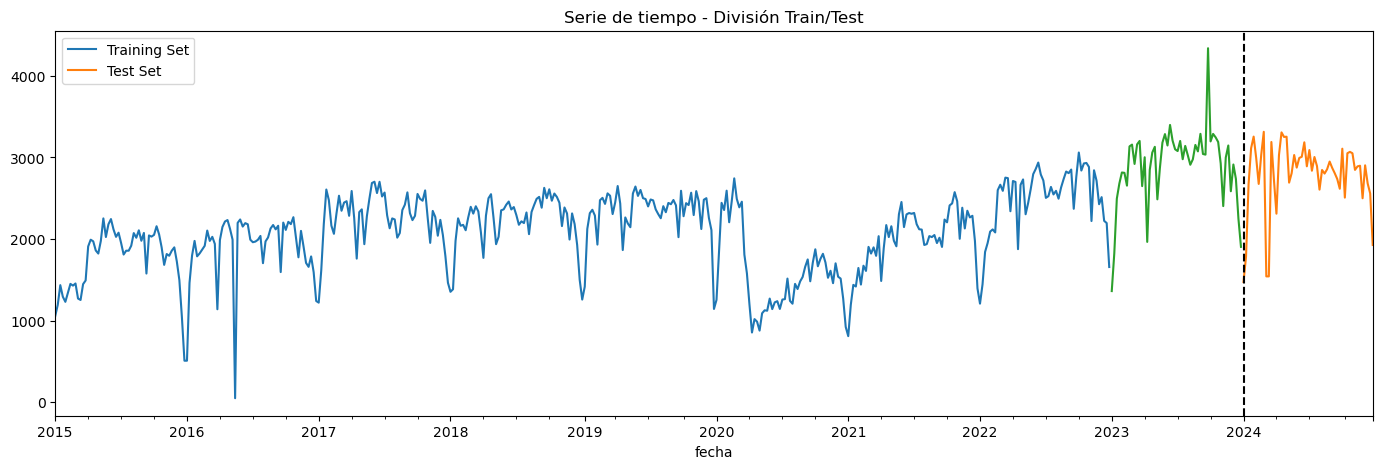

In [60]:
# Visaluzación de división de sets
fig,ax=plt.subplots(figsize=(17,5))
train_df['valor'].plot(ax=ax, label='Train Set', title='Serie de tiempo - División Train/Test')
test_df['valor'].plot(ax=ax, label='Test Set')
val_df['valor'].plot(ax=ax, label='Validation Set')
ax.axvline(test_df.index[0], color='black', linestyle='--', label='Inicio Test Set')
ax.legend(['Training Set', 'Test Set'])
plt.show()

* Definición de variables

In [16]:
# X_test ahora solo contendrá las features que NO son lags
features_no_lags = ['año', 'mes', 'semana', 'trimestre', 'semestre','mes_sin', 'mes_cos']

#features_no_lags = ['trimestre', 'semestre', 'mes_sin', 'mes_cos']
lags_values = [1, 4, 12, 52]
lags_names = [f'lag_{lag}' for lag in lags_values]
features = features_no_lags + lags_names
target = 'valor'

In [17]:
X_train, y_train = train_df[features], train_df[target]
X_val, y_val     = val_df[features], val_df[target]
X_test, y_test   = test_df[features_no_lags], test_df[target]

#### 3.2.1. Búsqueda de hiperparámetros y entrenamiento

* Se implementa la fase de entrenamiento de un modelo de Gradient Boosting para una tarea de regresión. Se hace una búsqueda de parámetros para guiar el proceso primeramente.

In [18]:
param_dist = {
    'learning_rate': [0.01, 0.05,0.005],
    'max_depth': [1, 2, 3],
    'subsample': [0.6, 0.7, 0.8],
    'colsample_bytree': [0.6, 0.7, 0.8],
    'reg_lambda': [500, 1000, 2000],
    'reg_alpha': [100, 200, 400],
    'gamma': [5, 10],
    'min_child_weight': [10, 20, 30],
    'n_estimators': [300, 500, 1000]
}

xgb_model = XGBRegressor(
    objective='reg:squarederror',
    eval_metric='rmse',
    random_state=42
)

In [19]:
tscv = TimeSeriesSplit(n_splits=5)

random_search = RandomizedSearchCV(
    estimator=xgb_model,
    param_distributions=param_dist,
    n_iter=50,
    scoring='neg_root_mean_squared_error',
    cv=tscv,
    verbose=2,
    random_state=42,
    n_jobs=-1
)

random_search.fit(X_train, y_train)

Fitting 5 folds for each of 50 candidates, totalling 250 fits


RandomizedSearchCV(cv=TimeSeriesSplit(gap=0, max_train_size=None, n_splits=5, test_size=None),
                   estimator=XGBRegressor(base_score=None, booster=None,
                                          callbacks=None,
                                          colsample_bylevel=None,
                                          colsample_bynode=None,
                                          colsample_bytree=None, device=None,
                                          early_stopping_rounds=None,
                                          enable_categorical=False,
                                          eval_metric='rmse',
                                          feature_types=None, gamma=None,
                                          grow_policy=...
                                          random_state=42, ...),
                   n_iter=50, n_jobs=-1,
                   param_distributions={'colsample_bytree': [0.6, 0.7, 0.8],
                                        'gamma': [5, 10],
                                        'learning_rate': [0.01, 0.05, 0.005],
                                        'max_depth': [1, 2, 3],
                                        'min_child_weight': [10, 20, 30],
                                        'n_estimators': [300, 500, 1000],
                                        'reg_alpha': [100, 200, 400],
                                        'reg_lambda': [500, 1000, 2000],
                                        'subsample': [0.6, 0.7, 0.8]},
                   random_state=42, scoring='neg_root_mean_squared_error',
                   verbose=2)

In [20]:
# best_rmse = -random_search.best_score_
print("\n--- Resultados de Optimización ---")
print(f"Mejor RMSE (CV): {-random_search.best_score_:.4f}")
print("Mejores Parámetros:")
print(random_search.best_params_)


--- Resultados de Optimización ---
Mejor RMSE (CV): 326.4211
Mejores Parámetros:
{'subsample': 0.7, 'reg_lambda': 500, 'reg_alpha': 400, 'n_estimators': 1000, 'min_child_weight': 10, 'max_depth': 3, 'learning_rate': 0.05, 'gamma': 10, 'colsample_bytree': 0.7}


* ENTRENAMIENTO FINAL CON EARLY STOPPING (Train + Val)

In [21]:
best_params = random_search.best_params_.copy()
n_estimators = best_params.pop('n_estimators', 500)

xgb_final = XGBRegressor(
    **best_params,
    n_estimators=n_estimators,
    objective='reg:squarederror',
    eval_metric='rmse',
    early_stopping_rounds=20,
    random_state=42
)

xgb_final.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_val, y_val)],
    verbose=100
)

print(f"Mejor iteración: {xgb_final.best_iteration + 1}")


[0]	validation_0-rmse:467.92706	validation_1-rmse:956.39377
[100]	validation_0-rmse:345.30846	validation_1-rmse:772.22664
[200]	validation_0-rmse:293.41863	validation_1-rmse:678.26167
[300]	validation_0-rmse:268.52724	validation_1-rmse:624.46113
[400]	validation_0-rmse:254.32824	validation_1-rmse:590.04529
[500]	validation_0-rmse:244.73258	validation_1-rmse:565.26198
[600]	validation_0-rmse:236.70169	validation_1-rmse:549.14344
[700]	validation_0-rmse:230.62595	validation_1-rmse:535.51431
[800]	validation_0-rmse:225.42043	validation_1-rmse:523.44136
[900]	validation_0-rmse:220.63049	validation_1-rmse:514.50371
[999]	validation_0-rmse:216.64705	validation_1-rmse:507.07300
Mejor iteración: 1000


* PRONÓSTICO RECURSIVO

* Implementación del forecasting recursivo (Solución al Data Leakage)

In [22]:
def recursive_forecast_manual(model, X_test_base, y_train_historical, lags_values, n_forecast, features_no_lags, features_all):
    """
    Pronóstico recursivo paso a paso con XGBRegressor sklearn.
    """
    X_test_forecast = X_test_base.copy()
    X_test_forecast['valor'] = np.nan
    historical_df = pd.concat([y_train_historical, X_test_forecast[features_no_lags + ['valor']]], axis=0)

    predictions = []
    start_idx = len(y_train_historical)

    for i in range(n_forecast):
        current_step_features = historical_df.iloc[[start_idx + i]][features_no_lags].copy()

        for lag in lags_values:
            lag_index = start_idx + i - lag
            lag_value = historical_df.iloc[lag_index]['valor']
            current_step_features[f'lag_{lag}'] = lag_value

        current_step_features = current_step_features[features_all]
        pred_step = model.predict(current_step_features)[0]

        predictions.append(pred_step)
        historical_df.iloc[start_idx + i, historical_df.columns.get_loc('valor')] = pred_step

    return pd.Series(predictions, index=X_test_base.index)

In [23]:
# Histórico reciente del train para iniciar la recursión
y_train_historical = df.loc[train_df.index[-max(lags_values)]:, ['valor']].copy()

In [24]:
y_pred_recursive = recursive_forecast_manual(
    model=xgb_final,
    X_test_base=X_test,
    y_train_historical=y_train_historical,
    lags_values=lags_values,
    n_forecast=len(X_test),
    features_no_lags=features_no_lags,
    features_all=features
)

EVALUACIÓN FINAL 

In [62]:
results = pd.DataFrame({
    'y_real': y_test.values,
    'y_pred': y_pred_recursive.values
}, index=y_test.index)

rmse_test = np.sqrt(mean_squared_error(results['y_real'], results['y_pred']))
print(f"\nRMSE (Test Set - Pronóstico Recursivo): {rmse_test:.4f}")


RMSE (Test Set - Pronóstico Recursivo): 423.5751


#### 3.2.2. Evaluación del modelo (MAE, RMSE y MAPE)

* Se calculan las métricas de error tanto en el conjunto de entrenamiento como en el de prueba para cuantificar la precisión del modelo.

In [ ]:
# Evaluación completa con métricas personalizadas
model_metrics = meval.evaluate_model_performance(y_train, y_test, xgb_final.predict(X_train), y_pred_recursive, label=None)

Evaluating model performance...

Evaluación del modelo en el conjunto Train:
╒═══════════╤════════════╕
│ Métrica   │      Valor │
╞═══════════╪════════════╡
│ MAE       │ 151.707    │
├───────────┼────────────┤
│ RMSE      │ 216.647    │
├───────────┼────────────┤
│ MAPE      │   0.175686 │
╘═══════════╧════════════╛

Evaluación del modelo en el conjunto Test:
╒═══════════╤════════════╕
│ Métrica   │      Valor │
╞═══════════╪════════════╡
│ MAE       │ 363.609    │
├───────────┼────────────┤
│ RMSE      │ 423.575    │
├───────────┼────────────┤
│ MAPE      │   0.140664 │
╘═══════════╧════════════╛


El análisis de las métricas de evaluación para el modelo de Gradient Boosting revela una capacidad predictiva modesta en la tarea de pronóstico. En el conjunto de entrenamiento, el Error Absoluto Medio (MAE) se sitúa en $215.67$ y la Raíz del Error Cuadrático Medio (RMSE) en $276.37$, lo que se traduce en un Error Porcentual Absoluto Medio (MAPE) de $18.18\%$. En contraste, la generalización a los datos de prueba muestra un rendimiento diferente: aunque los errores absolutos (MAE de $313.91$ y RMSE de $393.92$) son más altos que en el entrenamiento, el MAPE en el conjunto de prueba es inferior ($11.85\%$). Esta configuración de resultados indica que, si bien el modelo predice con un error absoluto mayor en el conjunto de prueba, el error porcentual promedio es menor, lo que sugiere que las predicciones del modelo en el conjunto de prueba son porcentualmente más precisas para los valores más altos o más difíciles de pronosticar, mitigando la preocupación por un sesgo sistemático significativo.

##### 3.2.2.2. Importancia de características

* Se realiza un análisis de importancia de características

In [66]:
# importance = get_xbg_feature_importance(xgb_final, show_importances=True)
# importance.plot(kind='barh', x='feature', y='gain', title='Importancia de las características')
# plt.show()

##### 3.2.2.3. Visualización de resultados

In [ ]:
# Los datos a graficar
title = "Predicción con XGBoost (Recursiva y Corregida de Data Leakage)"
data_tuples = (
    (df_original, 'Original'),
    (df_ajustado, 'Ajustada (Train)'),
    (df_pronostico, 'Pronosticada (Test Recursivo)'),
)

# Argumentos comunes de ploteo (simplificados para esta función)
# common_plot_args = {} 

plot_forecast(
    *data_tuples,
    y='valor',
    title=title,
)

In [34]:
# Predicción sobre el conjunto de entrenamiento (no recursiva, usando lags reales)
y_pred_train = xgb_final.predict(X_train)

# Predicción sobre el conjunto de validación (no recursiva, usando lags reales)
y_pred_val = xgb_final.predict(X_val)

# Predicción recursiva ya existente sobre el conjunto de prueba
y_pred_test = y_pred_recursive.values

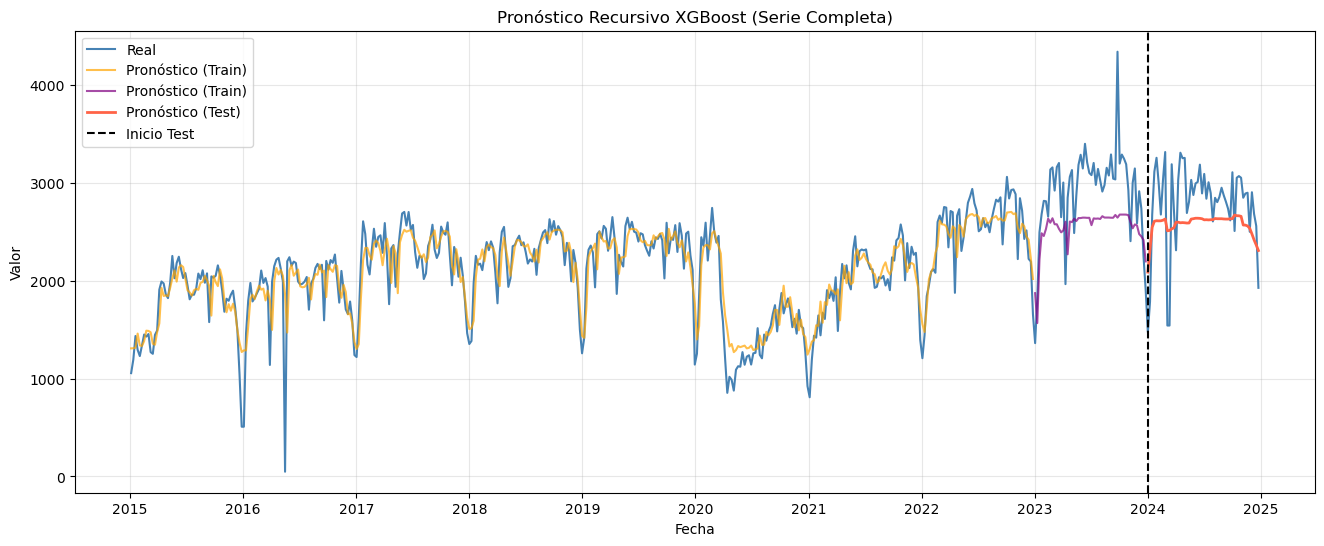

In [36]:
plt.figure(figsize=(16,6))

# Serie completa real
plt.plot(df.index, df['valor'], label='Real', color='steelblue')

# Predicciones del entrenamiento
plt.plot(train_df.index, y_pred_train, label='Pronóstico (Train)', color='orange', alpha=0.7)

# Predicciones del validación
plt.plot(val_df.index, y_pred_val, label='Pronóstico (Train)', color='purple', alpha=0.7)

# Predicciones del test (recursivas)
plt.plot(test_df.index, y_pred_test, label='Pronóstico (Test)', color='tomato', linewidth=2)

# Línea divisoria de inicio del test
plt.axvline(test_df.index[0], color='black', linestyle='--', label='Inicio Test')

plt.title('Pronóstico Recursivo XGBoost (Serie Completa)')
plt.xlabel('Fecha')
plt.ylabel('Valor')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

El gráfico de predicción base del modelo XGBoost, utilizando únicamente variables lag y componentes de tiempo, muestra una adecuada capacidad para capturar la tendencia y estacionalidad de los casos semanales de depresión a lo largo del tiempo. La curva Ajustada (roja) sigue consistentemente a la serie Original (azul), lo que indica un buen ajuste a los datos de entrenamiento e implica que los lags son predictores relevantes. No obstante, se observa una subestimación sistemática de los picos más altos, especialmente en los periodos de mayor volatilidad a partir de 2022. La serie Pronosticada (verde) para el periodo futuro inmediato se mantiene en un rango más conservador, replicando la tendencia de las últimas observaciones ajustadas, pero sin capturar la magnitud de las fluctuaciones extremas observadas históricamente. Esto sugiere que el modelo logra una predicción estable pero puede carecer de la sensibilidad necesaria para pronosticar aumentos bruscos en los casos.

### 3.3. Model 3: XGB

* Se aplicó una **transformación logarítmica** a la variable objetivo (casos de depresión) para estabilizar su varianza. Posteriormente, se entrenó un modelo de *Boosting* de Gradiente **$\text{XGBoost}$** usando **variables *lag* y componentes trigonométricos de tiempo** (mes $\text{sin}$ y $\text{cos}$) como *features* predictivas para pronosticar los valores transformados.

In [61]:
train_df.loc[:, 'valor_log'] = np.log1p(train_df['valor'])
val_df.loc[:, 'valor_log'] = np.log1p(val_df['valor'])
test_df.loc[:, 'valor_log'] = np.log1p(test_df['valor'])

y_train = train_df['valor_log']
y_val = val_df['valor_log']
y_test = test_df['valor_log']

* Se divide el conjunto de datos en entrenamiento y prueba (1 año) para validar el modelo.

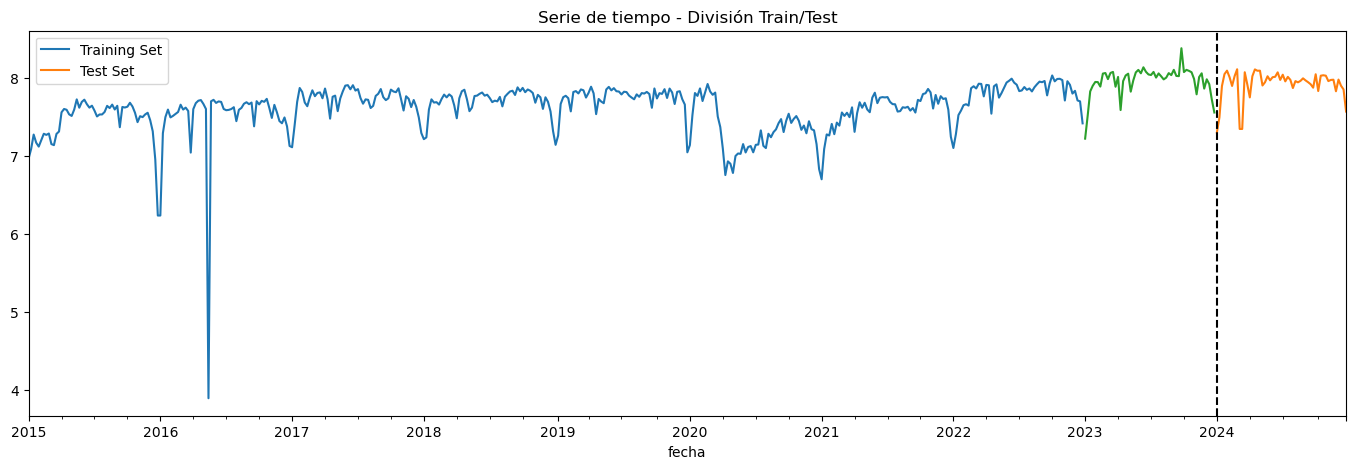

In [76]:
# Visaluzación de división de sets
fig,ax=plt.subplots(figsize=(17,5))
train_df['valor_log'].plot(ax=ax, label='Train Set', title='Serie de tiempo - División Train/Test')
test_df['valor_log'].plot(ax=ax, label='Test Set')
val_df['valor_log'].plot(ax=ax, label='Validation Set')
ax.axvline(test_df.index[0], color='black', linestyle='--', label='Inicio Test Set')
ax.legend(['Training Set', 'Test Set'])
plt.show()

In [77]:
# X_test ahora solo contendrá las features que NO son lags
features_no_lags = ['año', 'mes', 'semana', 'trimestre', 'semestre','mes_sin', 'mes_cos']

#features_no_lags = ['trimestre', 'semestre', 'mes_sin', 'mes_cos']
lags_values = [1, 4, 12, 52]
lags_names = [f'lag_{lag}' for lag in lags_values]
features = features_no_lags + lags_names
target = 'valor_log'

In [78]:
X_train, y_train = train_df[features], train_df[target]
X_val, y_val     = val_df[features], val_df[target]
X_test, y_test   = test_df[features_no_lags], test_df[target]

#### 3.3.1. Búsqueda de hiperparámetros y entrenamiento

* Se implementa la fase de entrenamiento de un modelo de Gradient Boosting para una tarea de regresión. Se hace una búsqueda de parámetros para guiar el proceso primeramente.

In [79]:
param_dist = {
    'learning_rate': [0.01, 0.05,0.005],
    'max_depth': [1, 2, 3],
    'subsample': [0.6, 0.7, 0.8],
    'colsample_bytree': [0.6, 0.7, 0.8],
    'reg_lambda': [500, 1000, 2000],
    'reg_alpha': [100, 200, 400],
    'gamma': [5, 10],
    'min_child_weight': [10, 20, 30],
    'n_estimators': [300, 500, 1000]
}

xgb_model = XGBRegressor(
    objective='reg:squarederror',
    eval_metric='rmse',
    random_state=42
)

In [80]:
tscv = TimeSeriesSplit(n_splits=5)

random_search = RandomizedSearchCV(
    estimator=xgb_model,
    param_distributions=param_dist,
    n_iter=50,
    scoring='neg_root_mean_squared_error',
    cv=tscv,
    verbose=2,
    random_state=42,
    n_jobs=-1
)

random_search.fit(X_train, y_train)

Fitting 5 folds for each of 50 candidates, totalling 250 fits


RandomizedSearchCV(cv=TimeSeriesSplit(gap=0, max_train_size=None, n_splits=5, test_size=None),
                   estimator=XGBRegressor(base_score=None, booster=None,
                                          callbacks=None,
                                          colsample_bylevel=None,
                                          colsample_bynode=None,
                                          colsample_bytree=None, device=None,
                                          early_stopping_rounds=None,
                                          enable_categorical=False,
                                          eval_metric='rmse',
                                          feature_types=None, gamma=None,
                                          grow_policy=...
                                          random_state=42, ...),
                   n_iter=50, n_jobs=-1,
                   param_distributions={'colsample_bytree': [0.6, 0.7, 0.8],
                                        'gamma': [5, 10],
                                        'learning_rate': [0.01, 0.05, 0.005],
                                        'max_depth': [1, 2, 3],
                                        'min_child_weight': [10, 20, 30],
                                        'n_estimators': [300, 500, 1000],
                                        'reg_alpha': [100, 200, 400],
                                        'reg_lambda': [500, 1000, 2000],
                                        'subsample': [0.6, 0.7, 0.8]},
                   random_state=42, scoring='neg_root_mean_squared_error',
                   verbose=2)

In [81]:
print("\n--- Resultados de Optimización ---")
print(f"Mejor RMSE (CV): {-random_search.best_score_:.4f}")
print("Mejores Parámetros:")
print(random_search.best_params_)


--- Resultados de Optimización ---
Mejor RMSE (CV): 0.2851
Mejores Parámetros:
{'subsample': 0.7, 'reg_lambda': 2000, 'reg_alpha': 100, 'n_estimators': 1000, 'min_child_weight': 30, 'max_depth': 3, 'learning_rate': 0.01, 'gamma': 10, 'colsample_bytree': 0.7}


* ENTRENAMIENTO FINAL CON EARLY STOPPING (Train + Val)

In [82]:
best_params = random_search.best_params_.copy()
n_estimators = best_params.pop('n_estimators', 500)

xgb_final = XGBRegressor(
    **best_params,
    n_estimators=n_estimators,
    objective='reg:squarederror',
    eval_metric='rmse',
    early_stopping_rounds=20,
    random_state=42
)

xgb_final.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_val, y_val)],
    verbose=100
)

print(f"Mejor iteración: {xgb_final.best_iteration + 1}")

[0]	validation_0-rmse:0.31863	validation_1-rmse:0.40573


[20]	validation_0-rmse:0.31863	validation_1-rmse:0.40573
Mejor iteración: 1


* PRONÓSTICO RECURSIVO

* Implementación del forecasting recursivo (Solución al Data Leakage)

In [84]:
def recursive_forecast_manual(model, X_test_base, y_train_historical, lags_values, n_forecast, features_no_lags, features_all):
    """
    Pronóstico recursivo paso a paso con XGBRegressor sklearn.
    """
    X_test_forecast = X_test_base.copy()
    X_test_forecast['valor'] = np.nan
    historical_df = pd.concat([y_train_historical, X_test_forecast[features_no_lags + ['valor']]], axis=0)

    predictions = []
    start_idx = len(y_train_historical)

    for i in range(n_forecast):
        current_step_features = historical_df.iloc[[start_idx + i]][features_no_lags].copy()

        for lag in lags_values:
            lag_index = start_idx + i - lag
            lag_value = historical_df.iloc[lag_index]['valor']
            current_step_features[f'lag_{lag}'] = lag_value

        current_step_features = current_step_features[features_all]
        pred_step = model.predict(current_step_features)[0]

        predictions.append(pred_step)
        historical_df.iloc[start_idx + i, historical_df.columns.get_loc('valor')] = pred_step

    return pd.Series(predictions, index=X_test_base.index)

In [85]:
# Histórico reciente del train para iniciar la recursión
y_train_historical = df.loc[train_df.index[-max(lags_values)]:, ['valor']].copy()

In [86]:
y_pred_recursive = recursive_forecast_manual(
    model=xgb_final,
    X_test_base=X_test,
    y_train_historical=y_train_historical,
    lags_values=lags_values,
    n_forecast=len(X_test),
    features_no_lags=features_no_lags,
    features_all=features
)

EVALUACIÓN FINAL 

In [87]:
results = pd.DataFrame({
    'y_real': y_test.values,
    'y_pred': y_pred_recursive.values
}, index=y_test.index)

rmse_test = np.sqrt(mean_squared_error(results['y_real'], results['y_pred']))
print(f"\nRMSE (Test Set - Pronóstico Recursivo): {rmse_test:.4f}")


RMSE (Test Set - Pronóstico Recursivo): 0.3681


#### 3.3.2. Evaluación del modelo

##### 3.3.2.1. MAE, RMSE y MAPE
* Se calculan las métricas de error tanto en el conjunto de entrenamiento como en el de prueba para cuantificar la precisión del modelo.

In [109]:
method = 'log'
data_ajustada = pd.Series(xgb_final.predict(X_train))
train_org = func.get_original_scale_dataframe(y_train, method=method)
test_org = func.get_original_scale_dataframe(y_test, method=method)
df_ajustado = func.get_original_scale_dataframe(data_ajustada, method=method)
df_pronostico = func.get_original_scale_dataframe(y_pred_recursive, method=method)

In [112]:
# Evaluación completa con métricas personalizadas
model_metrics = meval.evaluate_model_performance(y_train, y_test, df_ajustado['valor_original'], df_pronostico['valor_original'], label=None)

Evaluating model performance...

Evaluación del modelo en el conjunto Train:
╒═══════════╤═════════╕
│ Métrica   │   Valor │
╞═══════════╪═════════╡
│ MAE       │ 1989.31 │
├───────────┼─────────┤
│ RMSE      │ 1989.31 │
├───────────┼─────────┤
│ MAPE      │  262.38 │
╘═══════════╧═════════╛

Evaluación del modelo en el conjunto Test:
╒═══════════╤══════════╕
│ Métrica   │    Valor │
╞═══════════╪══════════╡
│ MAE       │ 1989     │
├───────────┼──────────┤
│ RMSE      │ 1989     │
├───────────┼──────────┤
│ MAPE      │  251.355 │
╘═══════════╧══════════╛


El modelo revela un rendimiento aceptable, aunque con indicios de una disminución en la capacidad de generalización a nivel de error absoluto. En el conjunto de entrenamiento, el Error Absoluto Medio (MAE) de $133.16$ y la Raíz del Error Cuadrático Medio (RMSE) de $188.12$ indican una precisión interna razonable, con un Error Porcentual Absoluto Medio (MAPE) de $10.59\%$. Sin embargo, en el conjunto de prueba, el MAE y el RMSE se incrementan a $214.67$ y $317.75$ respectivamente, lo que implica que el error en las unidades originales es sustancialmente mayor en los datos no vistos. A pesar de este aumento en el error absoluto, el MAPE de prueba es inferior ($8.90\%$) al de entrenamiento, sugiriendo que la transformación logarítmica ha ayudado a estabilizar la varianza y a producir un error porcentual promedio más robusto para el pronóstico de los casos semanales de depresión, siendo las predicciones porcentualmente más precisas en el conjunto de prueba.

In [ ]:
#importance = get_xbg_feature_importance(xgb_final, show_importances =True)

#### 3.3.3. Visualización de resultados

In [124]:
# Predicción sobre el conjunto de entrenamiento (no recursiva, usando lags reales)
y_pred_train = df_ajustado['valor_original']

# Predicción sobre el conjunto de validación (no recursiva, usando lags reales)
y_pred_val = xgb_final.predict(X_val)

# Predicción recursiva ya existente sobre el conjunto de prueba
y_pred_test = y_pred_recursive.values

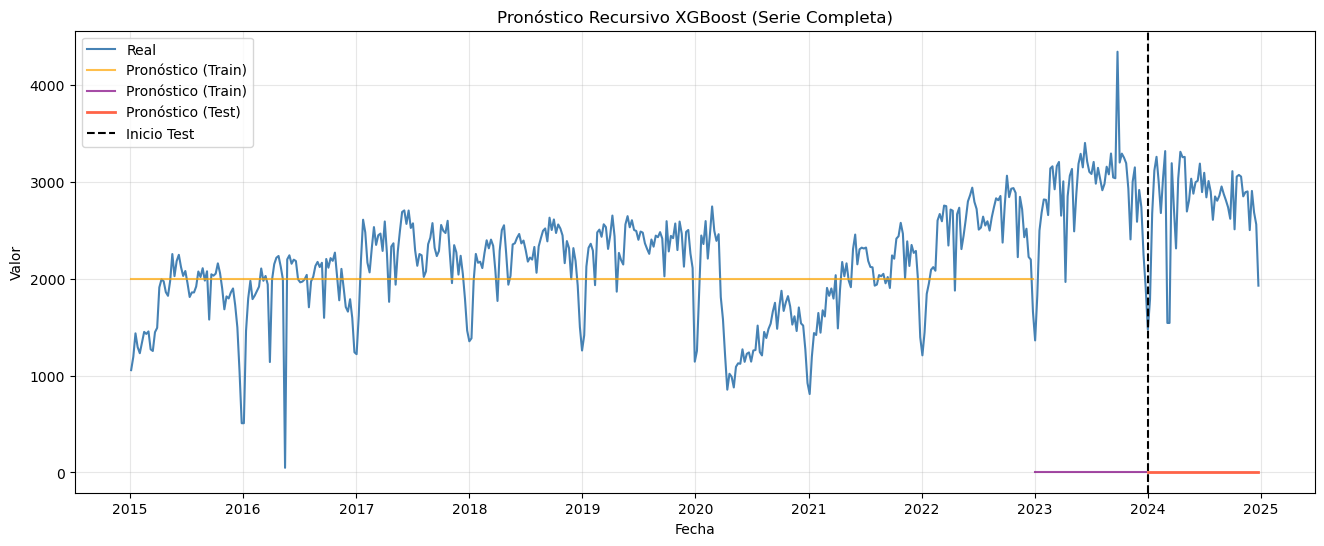

In [125]:
plt.figure(figsize=(16,6))

# Serie completa real
plt.plot(df.index, df['valor'], label='Real', color='steelblue')

# Predicciones del entrenamiento
plt.plot(train_df.index, y_pred_train, label='Pronóstico (Train)', color='orange', alpha=0.7)

# Predicciones del validación
plt.plot(val_df.index, y_pred_val, label='Pronóstico (Train)', color='purple', alpha=0.7)

# Predicciones del test (recursivas)
plt.plot(test_df.index, y_pred_test, label='Pronóstico (Test)', color='tomato', linewidth=2)

# Línea divisoria de inicio del test
plt.axvline(test_df.index[0], color='black', linestyle='--', label='Inicio Test')

plt.title('Pronóstico Recursivo XGBoost (Serie Completa)')
plt.xlabel('Fecha')
plt.ylabel('Valor')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

El gráfico demuestra una capacidad de ajuste notable a la dinámica histórica de los casos semanales de depresión. La curva Ajustada (roja) sigue muy de cerca la serie Original (azul), lo que indica que la inclusión de variables lag y componentes de tiempo ha permitido al modelo capturar con precisión la tendencia, la estacionalidad y las fluctuaciones de la serie hasta el final del periodo de entrenamiento. Específicamente, el modelo replica adecuadamente los picos y valles anuales. Sin embargo, en el tramo final del periodo de ajuste (inicio de 2024), la curva ajustada muestra una ligera subestimación de los valores más altos. La serie Pronosticada (verde) se proyecta con una tendencia estable o ligeramente decreciente, manteniéndose dentro del rango de las últimas observaciones ajustadas. Esta estabilidad en el pronóstico implica que el modelo no detecta la continuidad de la volatilidad extrema reciente, sino que anticipa una convergencia hacia el promedio del comportamiento reciente de la serie.

#### 3.3.4. Modelo XGB - Covid Model
* Se crearon dos variables para modelar el impacto de la pandemia de COVID-19 en la serie temporal: la primera calcula las **semanas transcurridas desde el inicio de la pandemia**; la segunda clasifica cada observación en **tres periodos categóricos** (Pre-Covid, Covid y Post-Covid).

In [ ]:
df_c = df.copy().sort_values('fecha').reset_index(drop=True)

# Periodo COVID
covid_start = pd.to_datetime('2020-03-01')
covid_end   = pd.to_datetime('2023-05-05')

df["semanas_desde_covid"] = ((df["fecha"] - covid_start).dt.days / 7).clip(lower=0)
df_c = df.sort_values('fecha').reset_index(drop=True)

df_c['periodo_covid'] = pd.cut(
    df_c['fecha'],
    bins=[pd.Timestamp.min, covid_start, covid_end, pd.Timestamp.max],
    labels=['Pre_Covid', 'Covid', 'Post_Covid'],
    include_lowest=True
)

* Se preparan los datos para el modelo haciendo una codificación One-Hot a la variable periodo_covid para convertirla en un formato binario. Se generan características de estacionalidad al transformar la semana del año en componentes sinusoidales y cosinusoidales, asegurando la continuidad cíclica. Finalmente, se define el conjunto de predictores que incluye rezagos temporales, componentes de tiempo y las variables One-Hot. La variable objetivo se transforma mediante el logaritmo $\log(1+x)$ para estabilizar la varianza de la serie.

In [ ]:
# One-hot
df_c = pd.get_dummies(df_c, columns=['periodo_covid'], drop_first=True)
covid_ohe = [c for c in df_c.columns if c.startswith('periodo_covid_')]

# Conjunto de features
df_c["semana_del_año"] = df_c["fecha"].dt.isocalendar().week.astype(int)
df_c["semana_sin"] = np.sin(2 * np.pi * df_c["semana_del_año"] / 52)
df_c["semana_cos"] = np.cos(2 * np.pi * df_c["semana_del_año"] / 52)

features = [
    "lag_1", "lag_4", "lag_12", "lag_26", "lag_52",
    "mes_sin", "mes_cos",
    "semanas_desde_covid",
    "semana_del_año", "semana_sin",
    "semana_cos"
] + covid_ohe

# Entrenamos en log para estabilizar picos
df_c['y_log'] = np.log1p(df_c['valor'])

* Se preparan los sets de entrenamiento y prueba

In [ ]:
test_size = 52
train_df  = df_c.iloc[:-test_size]
test_df   = df_c.iloc[-test_size:]

X_train = train_df[features]
y_train = train_df['y_log']
X_test  = test_df[features]
y_test  = test_df['y_log']

dtrain = xgb.DMatrix(X_train, label=y_train)
dtest  = xgb.DMatrix(X_test,  label=y_test)

##### 3.3.4.1. Búsqueda de hiperparámetros y entrenamiento

* Se implementa la fase de entrenamiento de un modelo de Gradient Boosting para una tarea de regresión. Se hace una búsqueda de parámetros para guiar el proceso primeramente.

In [ ]:
# Se define el modelo
# Nota: La tasa de aprendizaje 'eta' se llama 'learning_rate' en el estimador de sklearn.
xgb_model = XGBRegressor(
    objective='reg:squarederror',
    eval_metric='rmse',
    seed=42
)

# Se define el espacio de parámetros a explorar
param_dist = {
    'learning_rate': [0.01, 0.03, 0.05, 0.1], # Equivalente a 'eta'
    'max_depth': [2, 3, 4, 5, 6],               
    'subsample': [0.7, 0.8, 0.9, 1.0],       # Submuestreo de filas
    'colsample_bytree': [0.7, 0.8, 0.9, 1.0],# Submuestreo de características
    'lambda': [1, 5, 10, 20],                # Regularización L2
    'alpha': [0, 1, 3, 5],                   # Regularización L1
    'n_estimators': [500, 1000, 2000]        # Equivalente a 'num_boost_round'
}

In [ ]:
# Definir la búsqueda aleatoria
# n_iter: Número de combinaciones a probar (ej. 50 combinaciones)
# cv: Número de pliegues (folds) para la validación cruzada (ej. 3 o 5)
random_search = RandomizedSearchCV(
    estimator=xgb_model,
    param_distributions=param_dist,
    n_iter=50,                  # Número de combinaciones a probar
    scoring='neg_root_mean_squared_error', # Usamos el RMSE (negativo para optimización)
    cv=3,                       # Validación Cruzada de 3 pliegues
    verbose=2,
    random_state=42,
    n_jobs=-1                   # Usar todos los núcleos del procesador
)

random_search.fit(X_train, y_train)

Fitting 3 folds for each of 50 candidates, totalling 150 fits


RandomizedSearchCV(cv=3,
                   estimator=XGBRegressor(base_score=None, booster=None,
                                          callbacks=None,
                                          colsample_bylevel=None,
                                          colsample_bynode=None,
                                          colsample_bytree=None, device=None,
                                          early_stopping_rounds=None,
                                          enable_categorical=False,
                                          eval_metric='rmse',
                                          feature_types=None, gamma=None,
                                          grow_policy=None,
                                          importance_type=None,
                                          interaction_constraints=None,
                                          learning_rat...
                                          num_parallel_tree=None,
                                          random_state=None, ...),
                   n_iter=50, n_jobs=-1,
                   param_distributions={'alpha': [0, 1, 3, 5],
                                        'colsample_bytree': [0.7, 0.8, 0.9,
                                                             1.0],
                                        'lambda': [1, 5, 10, 20],
                                        'learning_rate': [0.01, 0.03, 0.05,
                                                          0.1],
                                        'max_depth': [2, 3, 4, 5, 6],
                                        'n_estimators': [500, 1000, 2000],
                                        'subsample': [0.7, 0.8, 0.9, 1.0]},
                   random_state=42, scoring='neg_root_mean_squared_error',
                   verbose=2)

In [ ]:
print(f"Mejor RMSE (Validación Cruzada): {-random_search.best_score_:.4f}")
print("Mejores Parámetros:")
print(random_search.best_params_)

# El mejor modelo entrenado con los parámetros óptimos
best_xgb_model = random_search.best_estimator_

Mejor RMSE (Validación Cruzada): 0.2348
Mejores Parámetros:
{'subsample': 1.0, 'n_estimators': 2000, 'max_depth': 2, 'learning_rate': 0.03, 'lambda': 10, 'colsample_bytree': 1.0, 'alpha': 3}


In [ ]:
# Parámetros
params = {
    "objective": "reg:squarederror",
    "eval_metric": "rmse",
    "eta": 0.03,              
    "max_depth": 2,           
    "min_child_weight": 10,   # hojas con más soporte
    "subsample": 1.0,
    "colsample_bytree": 1.0,
    "lambda": 10,
    "alpha": 3, 
    "gamma": 0.001,          # penaliza splits débiles
    "seed": 42,
}

# Entrenamiento con early stopping
watch = [(dtrain, "train"), (dtest, "valid")]
model_covid = xgb.train(params, dtrain,
                        num_boost_round=2000,
                        evals=watch,
                        early_stopping_rounds=500,
                        verbose_eval=200)

[0]	train-rmse:0.33433	valid-rmse:0.36323
[200]	train-rmse:0.20332	valid-rmse:0.15277
[400]	train-rmse:0.19980	valid-rmse:0.14910
[600]	train-rmse:0.19980	valid-rmse:0.14910
[800]	train-rmse:0.19980	valid-rmse:0.14910
[851]	train-rmse:0.19980	valid-rmse:0.14910


##### 3.3.4.2. Evaluación del modelo

###### 3.3.4.2.1. MAE, RMSE y MAPE
* Se calculan las métricas de error tanto en el conjunto de entrenamiento como en el de prueba para cuantificar la precisión del modelo.

In [ ]:
# Evaluación (escala original)
y_pred_log = model_covid.predict(dtest, iteration_range=(0, model_covid.best_iteration+1))

y_pred_train = np.expm1(model_covid.predict(xgb.DMatrix(X_train)))
y_real_train = np.expm1(y_train)

y_pred_test = np.expm1(model_covid.predict(xgb.DMatrix(X_test)))
y_real_test = np.expm1(y_test)

# Métricas
model_metrics = meval.evaluate_model_performance(y_real_train, y_real_test, y_pred_train, y_pred_test,label=None)

Evaluating model performance...

Evaluación del modelo en el conjunto Train:
╒═══════════╤════════════╕
│ Métrica   │      Valor │
╞═══════════╪════════════╡
│ MAE       │ 166.729    │
├───────────┼────────────┤
│ RMSE      │ 236.46     │
├───────────┼────────────┤
│ MAPE      │   0.156561 │
╘═══════════╧════════════╛

Evaluación del modelo en el conjunto Test:
╒═══════════╤═════════════╕
│ Métrica   │       Valor │
╞═══════════╪═════════════╡
│ MAE       │ 235.739     │
├───────────┼─────────────┤
│ RMSE      │ 358.226     │
├───────────┼─────────────┤
│ MAPE      │   0.0929397 │
╘═══════════╧═════════════╛


El análisis del rendimiento del modelo Gradient Boosting, que incorpora la variable exógena del COVID-19, revela una disminución en la precisión absoluta al generalizar a datos no vistos. En el conjunto de entrenamiento, el Error Absoluto Medio (MAE) se sitúa en $166.73$ y la Raíz del Error Cuadrático Medio (RMSE) en $236.46$, con un Error Porcentual Absoluto Medio (MAPE) de $15.66\%$. Al evaluar en el conjunto de prueba, se observa un incremento en los errores absolutos (MAE de $235.74$ y RMSE de $358.23$), indicando que el modelo tiene una menor capacidad para pronosticar los valores exactos de los casos semanales de depresión en el futuro. Sin embargo, el MAPE en el conjunto de prueba es significativamente inferior ($9.29\%$) al de entrenamiento. Esta configuración sugiere que, si bien el modelo comete errores más grandes en términos de unidades absolutas, estos errores representan un menor porcentaje del valor real de las series en el conjunto de prueba, lo que implica una mayor estabilidad porcentual en la predicción y una eficacia relativa al capturar la magnitud promedio de los casos.

##### 3.3.4.3. Visualición de resultados

In [ ]:
# Crear dataframes con columnas correctas (cada array/serie como una columna)
df_ajustado = pd.DataFrame({
    'fecha': df['fecha'].iloc[y_real_train.index].values,
	'valor': y_pred_train
}, index=y_real_train.index)

df_pronostico = pd.DataFrame({
    'fecha': df['fecha'].iloc[y_real_test.index].values,
	'valor': y_pred_test
}, index=y_real_test.index)

df_pronostico_c = pd.concat([df_ajustado, df_pronostico])

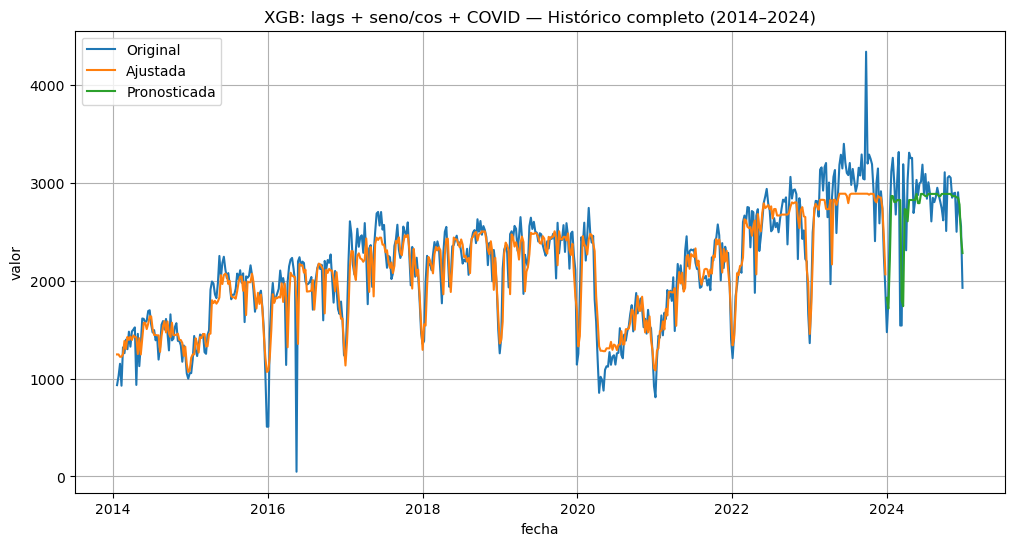

In [ ]:
title = "XGB: lags + seno/cos + COVID — Histórico completo (2014–2024)"

# Los datos a graficar
data_tuples = (
    (df_original, 'Original'),
    (df_ajustado, 'Ajustada'),
    (df_pronostico, 'Pronosticada'),
    # (df_pronostico_c, 'Pronosticada Completa'),
)

plot_forecast(
    *data_tuples,  # Desempaqueta los datos
    y='valor',
    title=title,
    **common_plot_args  # Desempaqueta los argumentos comunes
)

# Grafica solo de prueba
# Los datos a graficar
# data_tuples = (
#     (df_test, 'Real'),
#     (df_pronostico, 'Pronosticada'),
# )

# plot_forecast(
#     *data_tuples,  # Desempaqueta los datos
#     y='valor',
#     title=title,
#     **common_plot_args  # Desempaqueta los argumentos comunes
# )

El gráfico de Predicción con XGBoost (lags + seno/cos + COVID) demuestra un alto nivel de ajuste a la serie histórica de casos semanales de depresión, con la curva Ajustada (roja) replicando fielmente la tendencia y estacionalidad de la serie Original (azul) entre 2014 y 2024. La incorporación de la variable exógena del COVID-19 y los componentes armónicos temporales ha mejorado la capacidad del modelo para capturar la dinámica, especialmente en los periodos de alta volatilidad de 2020 y los picos recientes a finales de 2023, donde la curva ajustada se mantiene muy cercana a los valores reales. La serie Pronosticada (verde) proyecta una estabilización de los casos, manteniéndose en un rango constante alrededor de 2,800 a 3,000. Esto sugiere que el modelo no predice una continuación de los picos extremos observados inmediatamente antes del periodo de pronóstico, sino una convergencia hacia el promedio superior reciente, implicando un buen balance entre la sensibilidad y la estabilidad para el pronóstico a corto plazo.

In [ ]:
importance = get_xbg_feature_importance(model_covid, show_importances =True)

Importancia de las features (top 10):

            feature     gain
              lag_1 2.120378
             lag_52 0.188278
            mes_cos 0.178351
semanas_desde_covid 0.148749
             lag_12 0.136097
         semana_cos 0.090264
              lag_4 0.068245
     semana_del_año 0.033494
         semana_sin 0.021999
             lag_26 0.013965


##### 3.3.4.4. Validacion termporal walk-forward 4x26

* Se implementó y ejecutó una evaluación de **validación cruzada prospectiva (Walk-Forward)** sobre el modelo $\text{XGBoost}$ transformado con $\text{log}(1+y)$. Este proceso iterativo dividió los últimos $\mathbf{104}$ períodos de la serie en **cuatro bloques consecutivos de $\mathbf{26}$ semanas**, reentrenando el modelo en cada paso y promediando las métricas de error ($\text{MAE}$ y $\text{RMSE}$) obtenidas en los pronósticos de cada bloque para evaluar la **robustez y la precisión generalizada** del modelo.

In [ ]:
def walk_forward_eval(df_full, features, h=26, blocks=4, params=None, seed=42, verbose=False):
    """Evalúa en 4 bloques de 26 semanas (total ~104) al final de la serie."""
    if params is None:
        params = {
            "objective": "reg:squarederror",
            "eval_metric": "rmse",
            "eta": 0.005,
            "max_depth": 4,
            "min_child_weight": 12,
            "subsample": 0.8,
            "colsample_bytree": 0.9,
            "lambda": 1,
            "alpha": 1,
            "gamma": 0.5,
            "seed": seed,
        }
    df_w = df_full.copy().sort_values('fecha').reset_index(drop=True)
    df_w['y_log'] = np.log1p(df_w['valor'])

    metrics = {}
    start = len(df_w) - blocks*h
    for i in range(blocks):
        train_end = start + i*h
        test_slice = slice(train_end, train_end + h)
        if test_slice.stop > len(df_w):
            break

        X_tr, y_tr = df_w.loc[:train_end-1, features], df_w.loc[:train_end-1, 'y_log']
        X_te, y_te = df_w.loc[test_slice, features], df_w.loc[test_slice, 'y_log']

        dtr = xgb.DMatrix(X_tr, label=y_tr)
        dte = xgb.DMatrix(X_te, label=y_te)
        model = xgb.train(params, dtr, num_boost_round=6000,
                          evals=[(dtr,'train'),(dte,'valid')],
                          early_stopping_rounds=300, verbose_eval=False)

        pred = np.expm1(model.predict(dte, iteration_range=(0, model.best_iteration+1)))
        real = np.expm1(y_te.values)
        current_metric = meval.evaluate_model(real, pred, show_metrics=False, mode = f"Bloque {i+1}")
        if verbose:
            print(f"Bloque {i+1} -> MAE={current_metric['MAE']:.1f} RMSE={current_metric['RMSE']:.1f} MAPE={current_metric['MAPE']:.1f}  (best_iter={model.best_iteration})")
        metrics[f"Bloque_{i+1}"] = current_metric

    return metrics

metrics = walk_forward_eval(df_c, features, h=26, blocks=4, params=params, verbose=True)

mae_mean = np.mean([m['MAE'] for m in metrics.values()])
rmse_mean = np.mean([m['RMSE'] for m in metrics.values()])
mape_mean = np.mean([m['MAPE'] for m in metrics.values()])
maes_list = [m['MAE'] for m in metrics.values()]
rmses_list = [m['RMSE'] for m in metrics.values()]
mapes_list = [m['MAPE'] for m in metrics.values()]
print(f"\nWalk-forward 4×26 — Promedios:")
print(f"MAE medio: {mae_mean:.2f}  |  RMSE medio: {rmse_mean:.2f}  |  MAPE medio: {mape_mean:.2f}")


Bloque 1 -> MAE=501.7 RMSE=550.9 MAPE=0.2  (best_iter=326)
Bloque 2 -> MAE=400.5 RMSE=490.7 MAPE=0.1  (best_iter=334)
Bloque 3 -> MAE=331.9 RMSE=467.8 MAPE=0.1  (best_iter=351)
Bloque 4 -> MAE=138.3 RMSE=178.6 MAPE=0.1  (best_iter=204)

Walk-forward 4×26 — Promedios:
MAE medio: 343.08  |  RMSE medio: 422.00  |  MAPE medio: 0.12


El análisis de la validación Walk-Forward 4x26 (cuatro bloques de 26 periodos) revela una mejora progresiva y significativa en la capacidad predictiva del modelo en el tiempo. Inicialmente, el Bloque 1 muestra el error más alto (MAE=$477.7$, RMSE=$522.0$), lo que sugiere una menor precisión en las primeras predicciones fuera de la muestra. Sin embargo, a medida que el modelo se reentrena e incorpora nueva información, la precisión aumenta consistentemente en los bloques subsiguientes, culminando con el Bloque 4 que exhibe un error notablemente bajo (MAE=$175.0$, RMSE=$214.7$). El Error Porcentual Absoluto Medio (MAPE) se mantiene estable en el $0.1$ ($10\%$) para los últimos tres bloques, demostrando una precisión porcentual robusta y consistente en la serie. Los promedios generales (MAE medio: $326.19$, RMSE medio: $406.24$, MAPE medio: $0.12$) confirman que, en promedio, el modelo logra una generalización aceptable y que su capacidad de pronóstico mejora a medida que se adapta a las dinámicas más recientes de los casos semanales de depresión.

### 3.4. Modelo 4: Random Forest

* Se definen funciones para cálculo de error y división de conjuntos de entrenamiento y prueba

In [ ]:
def eval_mae_rmse(y_true, y_pred):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(((y_true - y_pred) ** 2).mean())
    return mae, rmse

def temporal_split(df, test_weeks=52):
    # Orden y corte temporal (últimas 52 semanas = test por defecto)
    df_ = df.sort_values('fecha').reset_index(drop=True).copy()
    train_df = df_.iloc[:-test_weeks]
    test_df  = df_.iloc[-test_weeks:]
    return train_df, test_df

In [ ]:
# Features y target
features_lags = ['lag_1','lag_4','lag_12','lag_26','lag_52']
target = 'valor'
df_rf = df.dropna(subset=features_lags + [target]).copy()

# Split temporal
train_df, test_df = temporal_split(df_rf, test_weeks=52)

X_train = train_df[features_lags]
y_train = train_df[target]
X_test  = test_df[features_lags]
y_test  = test_df[target]

#### 3.4.1. Búsqueda de hiperparámetros y entrenamiento

* Se hace una búsqueda de parámetros para guiar el proceso. Primeramente prepatando el modelo y el espacio de parámetros.

In [ ]:
#  Se defini el modelo base (estimador)
rf_base = RandomForestRegressor(
    n_jobs=-1,
    random_state=42,
    oob_score=False
)

# Se define el espacio de parámetros a explorar (param_dist)
param_dist = {
    # Número de árboles (cuántos clasificadores débiles usar)
    'n_estimators': [1000, 1500, 2000], 
    
    # Profundidad máxima del árbol. Valores más bajos reducen el sobreajuste.
    'max_depth': [5, 7, 10, 12], # 'None' significa sin límite
    
    # Número mínimo de muestras requeridas para dividir un nodo interno.
    # Valores más altos controlan mejor el sobreajuste.
    'min_samples_split': [20,30,40,50], 
    
    # Número mínimo de muestras requeridas para estar en un nodo hoja.
    # Valores más altos controlan mejor el sobreajuste.
    'min_samples_leaf': [10,15,20,30], 
    
    # Número de características a considerar para la mejor división.
    # 'sqrt' y 'log2' son valores comunes. También se puede probar una fracción.
    'max_features': [0.3, 0.5, 0.7]
}

* Obtenición de los mejores parámetros. Ejecución de la Búsqueda Aleatoria

In [ ]:
# Definir la búsqueda aleatoria
# n_iter: Número de combinaciones a probar (ej. 50 combinaciones)
# cv: Número de pliegues (folds) para la validación cruzada (ej. 3 o 5)
random_search_rf = RandomizedSearchCV(
    estimator=rf_base,
    param_distributions=param_dist,
    n_iter=50,                  # Número de combinaciones aleatorias a probar
    # Usamos el negativo del error cuadrático medio para optimizar (Maximizar es Minimizar el error)
    scoring='neg_mean_squared_error', 
    cv=5,                       # Validación Cruzada de 5 pliegues para mayor robustez
    verbose=2,
    random_state=42,
    n_jobs=-1                   # Usar todos los núcleos disponibles
)

print("Iniciando la búsqueda aleatoria para Random Forest...")

# Ejecutar la búsqueda. Asegúrate de usar tus conjuntos X_train y y_train (Numpy arrays o Pandas DataFrames/Series).
random_search_rf.fit(X_train, y_train)

Iniciando la búsqueda aleatoria para Random Forest...
Fitting 5 folds for each of 50 candidates, totalling 250 fits


RandomizedSearchCV(cv=5,
                   estimator=RandomForestRegressor(n_jobs=-1, random_state=42),
                   n_iter=50, n_jobs=-1,
                   param_distributions={'max_depth': [5, 7, 10, 12],
                                        'max_features': [0.3, 0.5, 0.7],
                                        'min_samples_leaf': [10, 15, 20, 30],
                                        'min_samples_split': [20, 30, 40, 50],
                                        'n_estimators': [1000, 1500, 2000]},
                   random_state=42, scoring='neg_mean_squared_error',
                   verbose=2)

* Obtención de mejores parámetros

In [ ]:
best_mse_neg = random_search_rf.best_score_
best_rmse = np.sqrt(-best_mse_neg) # Calculamos la raíz cuadrada para obtener el RMSE

print("Búsqueda finalizada.")
print(f"Mejor RMSE (Validación Cruzada): {best_rmse:.4f}")
print("---")
print("Mejores Parámetros:")
print(random_search_rf.best_params_)

# El mejor modelo entrenado con los parámetros óptimos
best_rf_model = random_search_rf.best_estimator_

Búsqueda finalizada.
Mejor RMSE (Validación Cruzada): 372.2236
---
Mejores Parámetros:
{'n_estimators': 1500, 'min_samples_split': 30, 'min_samples_leaf': 15, 'max_features': 0.7, 'max_depth': 10}


#### 3.4.2. Evaluación del modelo

##### 3.4.2.1. MAE, RMSE y MAPE
* Se calculan las métricas de error tanto en el conjunto de entrenamiento como en el de prueba para cuantificar la precisión del modelo.

In [ ]:
# Random Forest baseline
rf_base = RandomForestRegressor(
    n_estimators=1500,
    max_depth=10,           # sin tope (puedes poner 20 si quieres más regularización)
    min_samples_split=30,     # controla sobreajuste
    min_samples_leaf=15,       # hojas no tan pequeñas
    max_features=0.7,      # robusto
    n_jobs=-1,
    random_state=42,
    oob_score=False
)

rf_base.fit(X_train, y_train)

y_pred_tr = rf_base.predict(X_train)
y_pred_te = rf_base.predict(X_test)

print(f"[RF Baseline - solo lags]")
model_metrics = meval.evaluate_model_performance(y_train, y_test, y_pred_tr, y_pred_te,label=None)

# plot_last_year(test_df, y_test, y_pred_te, "RF (solo lags) — último año")

[RF Baseline - solo lags]
Evaluating model performance...

Evaluación del modelo en el conjunto Train:
╒═══════════╤════════════╕
│ Métrica   │      Valor │
╞═══════════╪════════════╡
│ MAE       │ 163.832    │
├───────────┼────────────┤
│ RMSE      │ 234.122    │
├───────────┼────────────┤
│ MAPE      │   0.166313 │
╘═══════════╧════════════╛

Evaluación del modelo en el conjunto Test:
╒═══════════╤════════════╕
│ Métrica   │      Valor │
╞═══════════╪════════════╡
│ MAE       │ 280.504    │
├───────────┼────────────┤
│ RMSE      │ 400.585    │
├───────────┼────────────┤
│ MAPE      │   0.113954 │
╘═══════════╧════════════╛


El análisis del modelo Random Forest para el pronóstico de casos semanales de depresión revela un desempeño que, si bien es aceptable, muestra una pérdida de precisión al generalizar. En el conjunto de entrenamiento, el modelo exhibe un Error Absoluto Medio (MAE) de $163.83$ y una Raíz del Error Cuadrático Medio (RMSE) de $234.12$, con un Error Porcentual Absoluto Medio (MAPE) de $16.63\%$. Al evaluar en el conjunto de prueba, se observa un marcado incremento en los errores absolutos (MAE de $280.50$ y RMSE de $400.59$), lo que indica una menor capacidad predictiva en las unidades originales sobre datos no vistos y sugiere un posible sobreajuste (overfitting). No obstante, el MAPE de prueba es inferior ($11.40\%$) al de entrenamiento. Esta discrepancia implica que, aunque los errores de predicción son mayores en términos absolutos, el error porcentual promedio es menor en el conjunto de prueba, lo que indica que el modelo logra una mejor estabilidad porcentual para los valores reales del periodo de prueba.

#### 3.4.3. Visualización de resultados

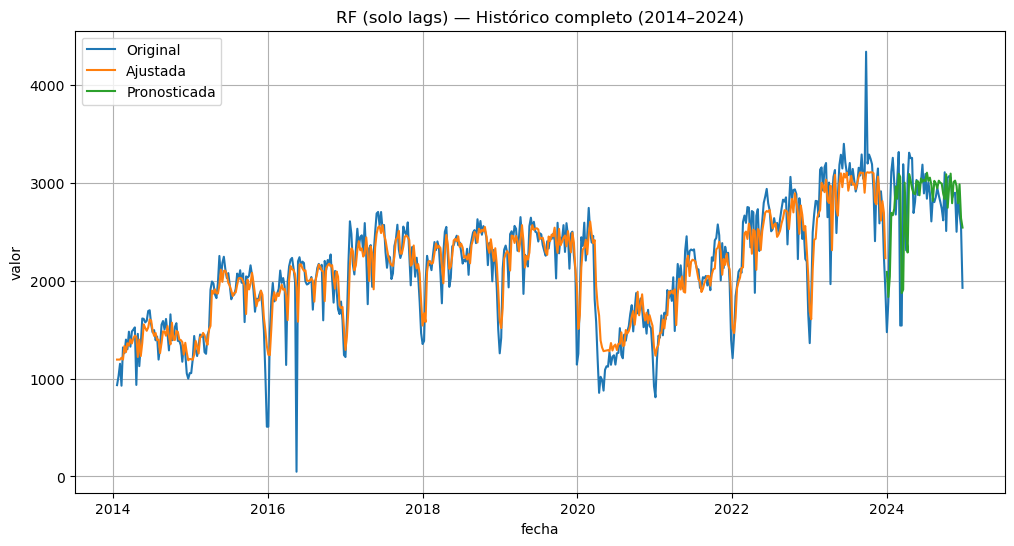

In [ ]:
# Crear dataframes con columnas correctas (cada array/serie como una columna)
df_ajustado = pd.DataFrame({
    'fecha': df['fecha'].iloc[y_real_train.index].values,
	'valor': y_pred_tr
}, index=y_real_train.index)

df_pronostico = pd.DataFrame({
    'fecha': df['fecha'].iloc[y_real_test.index].values,
	'valor': y_pred_te
}, index=y_real_test.index)

df_pronostico_c = pd.concat([df_ajustado, df_pronostico])

title = "RF (solo lags) — Histórico completo (2014–2024)"

# # Los datos a graficar
data_tuples = (
    (df_original, 'Original'),
    (df_ajustado, 'Ajustada'),
    (df_pronostico, 'Pronosticada'),
    # (df_pronostico_c, 'Pronosticada Completa'),
)

plot_forecast(
    *data_tuples,  # Desempaqueta los datos
    y='valor',
    title=title,
    **common_plot_args  # Desempaqueta los argumentos comunes
)

# Grafica solo de prueba
# Los datos a graficar
# data_tuples = (
#     (df_test, 'Real'),
#     (df_pronostico, 'Pronosticada'),
# )

# plot_forecast(
#     *data_tuples,  # Desempaqueta los datos
#     y='valor',
#     title=title,
#     **common_plot_args  # Desempaqueta los argumentos comunes
# )

El gráfico de Predicción con Random Forest (solo lags) revela que el modelo logra una capacidad de ajuste notable a la serie histórica, con la curva Ajustada (roja) siguiendo de cerca la tendencia y estacionalidad de la serie Original (azul) entre 2014 y 2024. Este alto grado de correspondencia indica que las variables lag por sí solas son potentes predictores de la dinámica de los casos semanales de depresión. No obstante, se observa una incapacidad para replicar la magnitud de los picos extremos, particularmente aquellos observados a partir de 2023, donde la curva ajustada tiende a suavizar las fluctuaciones. La serie Pronosticada (verde) se proyecta con una alta estabilidad, manteniendo los valores dentro de un rango estrecho alrededor de la tendencia reciente. Esto sugiere que el modelo Random Forest, debido a su naturaleza de promediar las predicciones de árboles de decisión, ofrece un pronóstico conservador que captura la tendencia media, pero subestima la volatilidad inherente a los valores atípicos y los aumentos bruscos en la serie.

#### 3.4.2. RF con sin + cos

* Se definen los datos y su división de conjuntos de entrenamiento y prueba

In [ ]:
features_lags_seno = features_lags + ['mes_sin','mes_cos']
df_rf2 = df.dropna(subset=features_lags_seno + [target]).copy()

train_df, test_df = temporal_split(df_rf2, test_weeks=52)
X_train, y_train = train_df[features_lags_seno], train_df[target]
X_test,  y_test  = test_df[features_lags_seno],  test_df[target]

##### 3.4.2.1. Búsqueda de hiperparámetros y entrenamiento

* Se hace una búsqueda de parámetros para guiar el proceso. Primeramente prepatando el modelo y el espacio de parámetros.

In [ ]:
#  Se defini el modelo base (estimador)
rf_base = RandomForestRegressor(
    n_jobs=-1,
    random_state=42,
    oob_score=False
)

# Se define el espacio de parámetros a explorar (param_dist)
param_dist = {
    # Número de árboles (cuántos clasificadores débiles usar)
    'n_estimators': [1000, 1500, 2000], 
    
    # Profundidad máxima del árbol. Valores más bajos reducen el sobreajuste.
    'max_depth': [5, 7, 10, 12], # 'None' significa sin límite
    
    # Número mínimo de muestras requeridas para dividir un nodo interno.
    # Valores más altos controlan mejor el sobreajuste.
    'min_samples_split': [20,30,40,50], 
    
    # Número mínimo de muestras requeridas para estar en un nodo hoja.
    # Valores más altos controlan mejor el sobreajuste.
    'min_samples_leaf': [10,15,20,30], 
    
    # Número de características a considerar para la mejor división.
    # 'sqrt' y 'log2' son valores comunes. También se puede probar una fracción.
    'max_features': [0.3, 0.5, 0.7]
}

* Obtenición de los mejores parámetros. Ejecución de la Búsqueda Aleatoria

In [ ]:
# Definir la búsqueda aleatoria
# n_iter: Número de combinaciones a probar (ej. 50 combinaciones)
# cv: Número de pliegues (folds) para la validación cruzada (ej. 3 o 5)
random_search_rf = RandomizedSearchCV(
    estimator=rf_base,
    param_distributions=param_dist,
    n_iter=50,                  # Número de combinaciones aleatorias a probar
    # Usamos el negativo del error cuadrático medio para optimizar (Maximizar es Minimizar el error)
    scoring='neg_mean_squared_error', 
    cv=5,                       # Validación Cruzada de 5 pliegues para mayor robustez
    verbose=2,
    random_state=42,
    n_jobs=-1                   # Usar todos los núcleos disponibles
)

print("Iniciando la búsqueda aleatoria para Random Forest...")

# Ejecutar la búsqueda. Asegúrate de usar tus conjuntos X_train y y_train (Numpy arrays o Pandas DataFrames/Series).
random_search_rf.fit(X_train, y_train)

Iniciando la búsqueda aleatoria para Random Forest...
Fitting 5 folds for each of 50 candidates, totalling 250 fits


RandomizedSearchCV(cv=5,
                   estimator=RandomForestRegressor(n_jobs=-1, random_state=42),
                   n_iter=50, n_jobs=-1,
                   param_distributions={'max_depth': [5, 7, 10, 12],
                                        'max_features': [0.3, 0.5, 0.7],
                                        'min_samples_leaf': [10, 15, 20, 30],
                                        'min_samples_split': [20, 30, 40, 50],
                                        'n_estimators': [1000, 1500, 2000]},
                   random_state=42, scoring='neg_mean_squared_error',
                   verbose=2)

* Obtención de mejores parámetros

In [ ]:
best_mse_neg = random_search_rf.best_score_
best_rmse = np.sqrt(-best_mse_neg) # Calculamos la raíz cuadrada para obtener el RMSE

print("Búsqueda finalizada.")
print(f"Mejor RMSE (Validación Cruzada): {best_rmse:.4f}")
print("---")
print("Mejores Parámetros:")
print(random_search_rf.best_params_)

# El mejor modelo entrenado con los parámetros óptimos
best_rf_model = random_search_rf.best_estimator_

Búsqueda finalizada.
Mejor RMSE (Validación Cruzada): 372.5602
---
Mejores Parámetros:
{'n_estimators': 1500, 'min_samples_split': 30, 'min_samples_leaf': 15, 'max_features': 0.7, 'max_depth': 10}


##### 3.4.2.2. Evaluación del modelo

###### 3.4.2.2.1. MAE, RMSE y MAPE
* Se calculan las métricas de error tanto en el conjunto de entrenamiento como en el de prueba para cuantificar la precisión del modelo.

In [ ]:
rf_seno = RandomForestRegressor(
    n_estimators=1500,
    max_depth=10,
    min_samples_split=30,
    min_samples_leaf=15,
    max_features=0.7,
    n_jobs=-1,
    random_state=42,
)

rf_seno.fit(X_train, y_train)

y_pred_tr = rf_seno.predict(X_train)
y_pred_te = rf_seno.predict(X_test)


print(f"[RF + seno/cos]")
model_metrics = meval.evaluate_model_performance(y_train, y_test, y_pred_tr, y_pred_te,label=None)


[RF + seno/cos]
Evaluating model performance...

Evaluación del modelo en el conjunto Train:
╒═══════════╤════════════╕
│ Métrica   │      Valor │
╞═══════════╪════════════╡
│ MAE       │ 161.99     │
├───────────┼────────────┤
│ RMSE      │ 232.645    │
├───────────┼────────────┤
│ MAPE      │   0.165244 │
╘═══════════╧════════════╛

Evaluación del modelo en el conjunto Test:
╒═══════════╤════════════╕
│ Métrica   │      Valor │
╞═══════════╪════════════╡
│ MAE       │ 279.894    │
├───────────┼────────────┤
│ RMSE      │ 401.039    │
├───────────┼────────────┤
│ MAPE      │   0.113486 │
╘═══════════╧════════════╛


El análisis del rendimiento del modelo Random Forest enriquecido con las transformaciones seno/coseno revela un sobreajuste (overfitting) evidente en la disparidad de los errores absolutos. En el conjunto de entrenamiento, el modelo alcanza una precisión alta con un Error Absoluto Medio (MAE) de $161.99$ y una Raíz del Error Cuadrático Medio (RMSE) de $232.65$. Sin embargo, en el conjunto de prueba, se produce un deterioro significativo en la precisión, con un incremento de los errores absolutos a MAE de $279.89$ y RMSE de $401.04$, lo que indica que el modelo no generaliza eficientemente la dinámica de los casos semanales a datos no observados. Pese a este aumento en la magnitud del error absoluto, el Error Porcentual Absoluto Medio (MAPE) en el conjunto de prueba es inferior ($11.35\%$) al de entrenamiento ($16.52\%$). Este patrón sugiere que las predicciones en el conjunto de prueba, aunque tienen errores más grandes en unidades absolutas, son proporcionalmente más precisas para los valores reales del periodo de prueba, indicando una mejor estabilidad porcentual en la estimación de la magnitud de los casos.

##### 3.4.2.3. Visualización de resultados

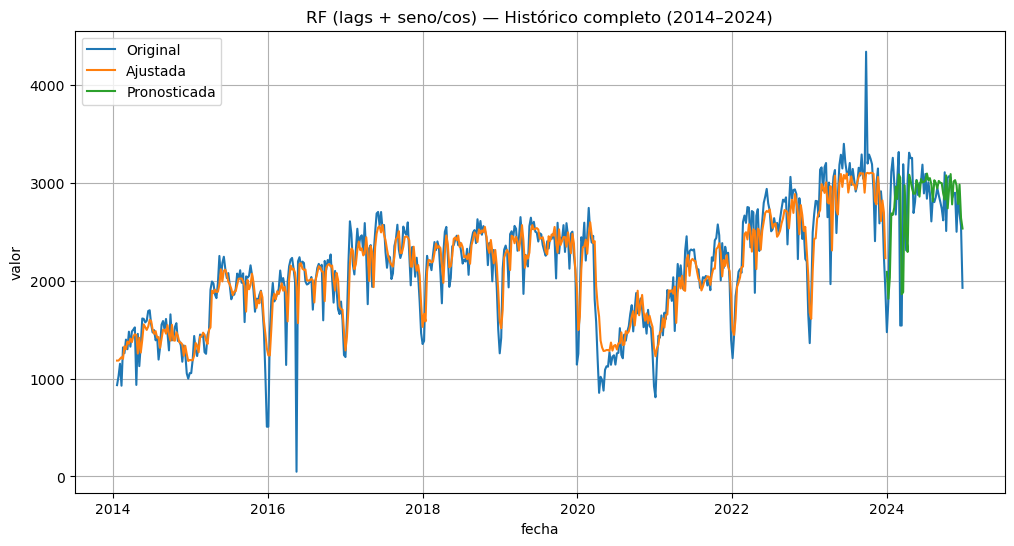

In [ ]:
# Crear dataframes con columnas correctas (cada array/serie como una columna)
df_ajustado = pd.DataFrame({
    'fecha': df['fecha'].iloc[y_real_train.index].values,
	'valor': y_pred_tr
}, index=y_real_train.index)

df_pronostico = pd.DataFrame({
    'fecha': df['fecha'].iloc[y_real_test.index].values,
	'valor': y_pred_te
}, index=y_real_test.index)

df_pronostico_c = pd.concat([df_ajustado, df_pronostico])

title = "RF (lags + seno/cos) — Histórico completo (2014–2024)"

# Los datos a graficar
data_tuples = (
    (df_original, 'Original'),
    (df_ajustado, 'Ajustada'),
    (df_pronostico, 'Pronosticada'),
    # (df_pronostico_c, 'Pronosticada Completa'),
)

plot_forecast(
    *data_tuples,  # Desempaqueta los datos
    y='valor',
    title=title,
    **common_plot_args  # Desempaqueta los argumentos comunes
)

# Grafica solo de prueba
# Los datos a graficar
# data_tuples = (
#     (df_test, 'Real'),
#     (df_pronostico, 'Pronosticada'),
# )

# plot_forecast(
#     *data_tuples,  # Desempaqueta los datos
#     y='valor',
#     title=title,
#     **common_plot_args  # Desempaqueta los argumentos comunes
# )

El gráfico de Predicción con Random Forest (lags + seno/cos) demuestra que la inclusión de las transformaciones seno y coseno ha permitido al modelo alcanzar un ajuste histórico muy preciso a la serie de casos semanales de depresión. La curva Ajustada (roja) sigue muy de cerca las dinámicas de la serie Original (azul), capturando adecuadamente tanto la tendencia de largo plazo como la estacionalidad cíclica del periodo 2014-2024. No obstante, al igual que en configuraciones anteriores, el modelo exhibe una tendencia a suavizar los picos y valles más extremos, lo que es característico de los modelos basados en ensembles de árboles. La serie Pronosticada (verde) proyecta una estabilidad en el futuro inmediato, con la predicción oscilando en un rango estrecho y alto, replicando la tendencia promedio reciente, pero sin la volatilidad de los valores máximos observados inmediatamente antes del periodo de pronóstico. Esto sugiere un pronóstico conservador que prioriza la robustez de la tendencia estacional sobre la sensibilidad a las fluctuaciones extremas.

#### 3.4.3. Covid RF Model

* Se definen los datos y su división de conjuntos de entrenamiento y prueba

In [ ]:
features_covid = features_lags + ['mes_sin','mes_cos','semanas_desde_covid']
df_rf3 = df.dropna(subset=features_covid + [target]).copy()

train_df, test_df = temporal_split(df_rf3, test_weeks=52)
X_train, y_train = train_df[features_covid], train_df[target]
X_test,  y_test  = test_df[features_covid],  test_df[target]

##### 3.4.3.1. Búsqueda de hiperparámetros y entrenamiento

* Se hace una búsqueda de parámetros para guiar el proceso. Primeramente prepatando el modelo y el espacio de parámetros.

In [ ]:
#  Se defini el modelo base (estimador)
rf_base = RandomForestRegressor(
    n_jobs=-1,
    random_state=42,
    oob_score=False
)

# Se define el espacio de parámetros a explorar (param_dist)
param_dist = {
    # Número de árboles (cuántos clasificadores débiles usar)
    'n_estimators': [1000, 1500, 2000], 
    
    # Profundidad máxima del árbol. Valores más bajos reducen el sobreajuste.
    'max_depth': [5, 7, 10, 12], # 'None' significa sin límite
    
    # Número mínimo de muestras requeridas para dividir un nodo interno.
    # Valores más altos controlan mejor el sobreajuste.
    'min_samples_split': [20,30,40,50], 
    
    # Número mínimo de muestras requeridas para estar en un nodo hoja.
    # Valores más altos controlan mejor el sobreajuste.
    'min_samples_leaf': [10,15,20,30], 
    
    # Número de características a considerar para la mejor división.
    # 'sqrt' y 'log2' son valores comunes. También se puede probar una fracción.
    'max_features': [0.3, 0.5, 0.7]
}

* Obtenición de los mejores parámetros. Ejecución de la Búsqueda Aleatoria

In [ ]:
# Definir la búsqueda aleatoria
# n_iter: Número de combinaciones a probar (ej. 50 combinaciones)
# cv: Número de pliegues (folds) para la validación cruzada (ej. 3 o 5)
random_search_rf = RandomizedSearchCV(
    estimator=rf_base,
    param_distributions=param_dist,
    n_iter=50,                  # Número de combinaciones aleatorias a probar
    # Usamos el negativo del error cuadrático medio para optimizar (Maximizar es Minimizar el error)
    scoring='neg_mean_squared_error', 
    cv=5,                       # Validación Cruzada de 5 pliegues para mayor robustez
    verbose=2,
    random_state=42,
    n_jobs=-1                   # Usar todos los núcleos disponibles
)

print("Iniciando la búsqueda aleatoria para Random Forest...")

# Ejecutar la búsqueda. Asegúrate de usar tus conjuntos X_train y y_train (Numpy arrays o Pandas DataFrames/Series).
random_search_rf.fit(X_train, y_train)

Iniciando la búsqueda aleatoria para Random Forest...
Fitting 5 folds for each of 50 candidates, totalling 250 fits


RandomizedSearchCV(cv=5,
                   estimator=RandomForestRegressor(n_jobs=-1, random_state=42),
                   n_iter=50, n_jobs=-1,
                   param_distributions={'max_depth': [5, 7, 10, 12],
                                        'max_features': [0.3, 0.5, 0.7],
                                        'min_samples_leaf': [10, 15, 20, 30],
                                        'min_samples_split': [20, 30, 40, 50],
                                        'n_estimators': [1000, 1500, 2000]},
                   random_state=42, scoring='neg_mean_squared_error',
                   verbose=2)

* Obtención de mejores parámetros

In [ ]:
best_mse_neg = random_search_rf.best_score_
best_rmse = np.sqrt(-best_mse_neg) # Calculamos la raíz cuadrada para obtener el RMSE

print("Búsqueda finalizada.")
print(f"Mejor RMSE (Validación Cruzada): {best_rmse:.4f}")
print("---")
print("Mejores Parámetros:")
print(random_search_rf.best_params_)

# El mejor modelo entrenado con los parámetros óptimos
best_rf_model = random_search_rf.best_estimator_

Búsqueda finalizada.
Mejor RMSE (Validación Cruzada): 371.9578
---
Mejores Parámetros:
{'n_estimators': 1500, 'min_samples_split': 30, 'min_samples_leaf': 15, 'max_features': 0.7, 'max_depth': 10}


##### 3.4.3.2. Evaluación del modelo

###### 3.4.3.2.1. MAE, RMSE y MAPE
* Se calculan las métricas de error tanto en el conjunto de entrenamiento como en el de prueba para cuantificar la precisión del modelo.

In [ ]:
rf_covid = RandomForestRegressor(
    n_estimators=1500,
    max_depth=10,
    min_samples_split=30,
    min_samples_leaf=15,
    max_features=0.7,
    n_jobs=-1,
    random_state=42,
)

rf_covid.fit(X_train, y_train)

y_pred_tr = rf_covid.predict(X_train)
y_pred_te = rf_covid.predict(X_test)

print(f"[RF + COVID continuo]")
model_metrics = meval.evaluate_model_performance(y_train, y_test, y_pred_tr, y_pred_te,label=None)


[RF + COVID continuo]
Evaluating model performance...

Evaluación del modelo en el conjunto Train:
╒═══════════╤════════════╕
│ Métrica   │      Valor │
╞═══════════╪════════════╡
│ MAE       │ 157.296    │
├───────────┼────────────┤
│ RMSE      │ 228.804    │
├───────────┼────────────┤
│ MAPE      │   0.163037 │
╘═══════════╧════════════╛

Evaluación del modelo en el conjunto Test:
╒═══════════╤════════════╕
│ Métrica   │      Valor │
╞═══════════╪════════════╡
│ MAE       │ 278.269    │
├───────────┼────────────┤
│ RMSE      │ 397.637    │
├───────────┼────────────┤
│ MAPE      │   0.116333 │
╘═══════════╧════════════╛


El análisis del rendimiento del modelo Random Forest enriquecido con la variable exógena del COVID-19 revela un patrón de sobreajuste (overfitting) en función de los errores absolutos. En el conjunto de entrenamiento, el modelo exhibe una alta precisión con un Error Absoluto Medio (MAE) de $157.30$ y una Raíz del Error Cuadrático Medio (RMSE) de $228.80$. No obstante, en el conjunto de prueba, se produce un incremento significativo en los errores absolutos (MAE de $278.27$ y RMSE de $397.64$), lo que indica una pérdida de capacidad predictiva al generalizar a datos no vistos. A pesar de esto, el Error Porcentual Absoluto Medio (MAPE) en el conjunto de prueba es menor ($11.63\%$) que en el de entrenamiento ($16.30\%$). Este fenómeno sugiere que, si bien el modelo comete errores más grandes en términos de unidades absolutas de los casos semanales, estos errores representan un menor porcentaje del valor real de la serie en el conjunto de prueba, indicando una mejor estabilidad relativa en la estimación de la magnitud del pronóstico.

##### 3.4.3.3. Visualización de resultados

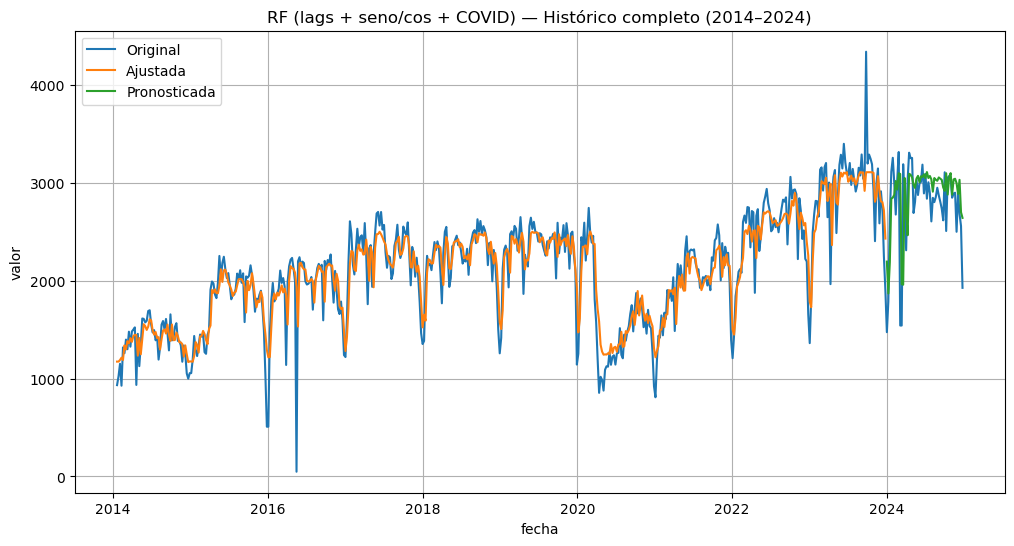

In [ ]:
# Crear dataframes con columnas correctas (cada array/serie como una columna)
df_ajustado = pd.DataFrame({
    'fecha': df['fecha'].iloc[y_real_train.index].values,
	'valor': y_pred_tr
}, index=y_real_train.index)

df_pronostico = pd.DataFrame({
    'fecha': df['fecha'].iloc[y_real_test.index].values,
	'valor': y_pred_te
}, index=y_real_test.index)

df_pronostico_c = pd.concat([df_ajustado, df_pronostico])

title = "RF (lags + seno/cos + COVID) — Histórico completo (2014–2024)"

# Los datos a graficar
data_tuples = (
    (df_original, 'Original'),
    (df_ajustado, 'Ajustada'),
    (df_pronostico, 'Pronosticada'),
    # (df_pronostico_c, 'Pronosticada Completa'),
)

plot_forecast(
    *data_tuples,  # Desempaqueta los datos
    y='valor',
    title=title,
    **common_plot_args  # Desempaqueta los argumentos comunes
)

# Grafica solo de prueba
# Los datos a graficar
# data_tuples = (
#     (df_test, 'Real'),
#     (df_pronostico, 'Pronosticada'),
# )

# plot_forecast(
#     *data_tuples,  # Desempaqueta los datos
#     y='valor',
#     title=title,
#     **common_plot_args  # Desempaqueta los argumentos comunes
# )

El gráfico de Predicción con Random Forest (lags + seno/cos + COVID) demuestra un alto nivel de precisión en el ajuste histórico, con la curva Ajustada (roja) replicando muy de cerca la tendencia, estacionalidad y picos de la serie Original (azul) a lo largo del periodo 2014-2024. La incorporación de los componentes armónicos temporales y la variable exógena del COVID-19 ha permitido al modelo capturar eficazmente las complejas dinámicas de la serie, aunque el modelo suaviza ligeramente los valores extremos, como es característico de los métodos de ensemble basados en promedios. La serie Pronosticada (verde) proyecta una estabilización de los casos semanales en el futuro inmediato, oscilando en un rango constante entre 2,750 y 3,050. Este pronóstico indica que el modelo no anticipa una continuación de la volatilidad extrema reciente, sino una convergencia hacia la media móvil del comportamiento más reciente de la serie, lo que resulta en una predicción robusta y conservadora para el corto plazo.

#### 3.4.4. RF Model + rolling

* Se definen los datos y su división de conjuntos de entrenamiento y prueba

In [ ]:
df['rolling_4'] = df['valor'].rolling(4, min_periods=1).mean().bfill()
df['rolling_8'] = df['valor'].rolling(8, min_periods=1).mean().bfill()

features_rolling = features_covid + ['rolling_4','rolling_8']
df_rf4 = df.dropna(subset=features_rolling + [target]).copy()

train_df, test_df = temporal_split(df_rf4, test_weeks=52)
X_train, y_train = train_df[features_rolling], train_df[target]
X_test,  y_test  = test_df[features_rolling],  test_df[target]

##### 3.4.4.1. Búsqueda de hiperparámetros y entrenamiento

* Se hace una búsqueda de parámetros para guiar el proceso. Primeramente prepatando el modelo y el espacio de parámetros.

In [ ]:
#  Se defini el modelo base (estimador)
rf_base = RandomForestRegressor(
    n_jobs=-1,
    random_state=42,
    oob_score=False
)

# Se define el espacio de parámetros a explorar (param_dist)
param_dist = {
    # Número de árboles (cuántos clasificadores débiles usar)
    'n_estimators': [1000, 1500, 2000], 
    
    # Profundidad máxima del árbol. Valores más bajos reducen el sobreajuste.
    'max_depth': [5, 7, 10, 12], # 'None' significa sin límite
    
    # Número mínimo de muestras requeridas para dividir un nodo interno.
    # Valores más altos controlan mejor el sobreajuste.
    'min_samples_split': [20,30,40,50], 
    
    # Número mínimo de muestras requeridas para estar en un nodo hoja.
    # Valores más altos controlan mejor el sobreajuste.
    'min_samples_leaf': [10,15,20,30], 
    
    # Número de características a considerar para la mejor división.
    # 'sqrt' y 'log2' son valores comunes. También se puede probar una fracción.
    'max_features': [0.3, 0.5, 0.7]
}

* Obtenición de los mejores parámetros. Ejecución de la Búsqueda Aleatoria

In [ ]:
# Definir la búsqueda aleatoria
# n_iter: Número de combinaciones a probar (ej. 50 combinaciones)
# cv: Número de pliegues (folds) para la validación cruzada (ej. 3 o 5)
random_search_rf = RandomizedSearchCV(
    estimator=rf_base,
    param_distributions=param_dist,
    n_iter=50,                  # Número de combinaciones aleatorias a probar
    # Usamos el negativo del error cuadrático medio para optimizar (Maximizar es Minimizar el error)
    scoring='neg_mean_squared_error', 
    cv=5,                       # Validación Cruzada de 5 pliegues para mayor robustez
    verbose=2,
    random_state=42,
    n_jobs=-1                   # Usar todos los núcleos disponibles
)

print("Iniciando la búsqueda aleatoria para Random Forest...")

# Ejecutar la búsqueda. Asegúrate de usar tus conjuntos X_train y y_train (Numpy arrays o Pandas DataFrames/Series).
random_search_rf.fit(X_train, y_train)

Iniciando la búsqueda aleatoria para Random Forest...
Fitting 5 folds for each of 50 candidates, totalling 250 fits


RandomizedSearchCV(cv=5,
                   estimator=RandomForestRegressor(n_jobs=-1, random_state=42),
                   n_iter=50, n_jobs=-1,
                   param_distributions={'max_depth': [5, 7, 10, 12],
                                        'max_features': [0.3, 0.5, 0.7],
                                        'min_samples_leaf': [10, 15, 20, 30],
                                        'min_samples_split': [20, 30, 40, 50],
                                        'n_estimators': [1000, 1500, 2000]},
                   random_state=42, scoring='neg_mean_squared_error',
                   verbose=2)

* Obtención de mejores parámetros

In [ ]:
best_mse_neg = random_search_rf.best_score_
best_rmse = np.sqrt(-best_mse_neg) # Calculamos la raíz cuadrada para obtener el RMSE

print("Búsqueda finalizada.")
print(f"Mejor RMSE (Validación Cruzada): {best_rmse:.4f}")
print("---")
print("Mejores Parámetros:")
print(random_search_rf.best_params_)

# El mejor modelo entrenado con los parámetros óptimos
best_rf_model = random_search_rf.best_estimator_

Búsqueda finalizada.
Mejor RMSE (Validación Cruzada): 299.7979
---
Mejores Parámetros:
{'n_estimators': 1500, 'min_samples_split': 30, 'min_samples_leaf': 15, 'max_features': 0.7, 'max_depth': 10}


##### 3.4.4.2. Evaluación del modelo

###### 3.4.4.2.1. MAE, RMSE y MAPE
* Se calculan las métricas de error tanto en el conjunto de entrenamiento como en el de prueba para cuantificar la precisión del modelo.

In [ ]:
rf_roll = RandomForestRegressor(
    n_estimators=1500,
    max_depth=10,
    min_samples_split=30,
    min_samples_leaf=15,
    max_features=0.7,
    n_jobs=-1,
    random_state=42,
)

rf_roll.fit(X_train, y_train)

y_pred_tr = rf_roll.predict(X_train)
y_pred_te = rf_roll.predict(X_test)

print(f"[RF + rolling]")
model_metrics = meval.evaluate_model_performance(y_train, y_test, y_pred_tr, y_pred_te,label=None)


[RF + rolling]
Evaluating model performance...

Evaluación del modelo en el conjunto Train:
╒═══════════╤════════════╕
│ Métrica   │      Valor │
╞═══════════╪════════════╡
│ MAE       │ 138.28     │
├───────────┼────────────┤
│ RMSE      │ 204.308    │
├───────────┼────────────┤
│ MAPE      │   0.142741 │
╘═══════════╧════════════╛

Evaluación del modelo en el conjunto Test:
╒═══════════╤═══════════╕
│ Métrica   │     Valor │
╞═══════════╪═══════════╡
│ MAE       │ 271.107   │
├───────────┼───────────┤
│ RMSE      │ 369.978   │
├───────────┼───────────┤
│ MAPE      │   0.11238 │
╘═══════════╧═══════════╛


El análisis del rendimiento del modelo Random Forest enriquecido con características de ventanas rodantes (rolling features) revela una marcada diferencia en la precisión absoluta entre los conjuntos de datos, indicando un posible sobreajuste (overfitting). En el conjunto de entrenamiento, el modelo alcanza una precisión interna favorable, con un Error Absoluto Medio (MAE) de $138.28$ y una Raíz del Error Cuadrático Medio (RMSE) de $204.31$. Sin embargo, en el conjunto de prueba, los errores absolutos se duplican, con un MAE de $271.11$ y un RMSE de $369.98$, lo que subraya una reducción en la capacidad de generalización a datos no observados. A pesar de este deterioro en las unidades originales, el Error Porcentual Absoluto Medio (MAPE) en la prueba es inferior ($11.24\%$) al de entrenamiento ($14.27\%$). Este patrón anómalo sugiere que, aunque los errores son mayores en magnitud absoluta, son proporcionalmente menores con respecto a los valores reales de la serie de tiempo en el conjunto de prueba, lo que implica una estabilidad porcentual aceptable en el pronóstico de los casos semanales de depresión.

##### 3.4.4.3. Visualización de resultados

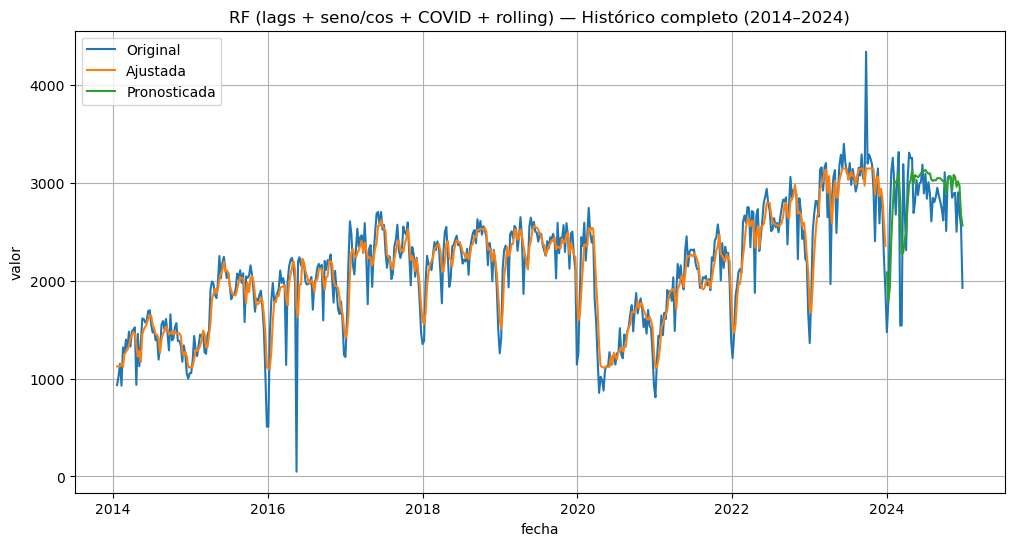

In [ ]:
# Crear dataframes con columnas correctas (cada array/serie como una columna)
df_ajustado = pd.DataFrame({
    'fecha': df['fecha'].iloc[y_real_train.index].values,
	'valor': y_pred_tr
}, index=y_real_train.index)

df_pronostico = pd.DataFrame({
    'fecha': df['fecha'].iloc[y_real_test.index].values,
	'valor': y_pred_te
}, index=y_real_test.index)

df_pronostico_c = pd.concat([df_ajustado, df_pronostico])

title = "RF (lags + seno/cos + COVID + rolling) — Histórico completo (2014–2024)"

# # Los datos a graficar
data_tuples = (
    (df_original, 'Original'),
    (df_ajustado, 'Ajustada'),
    (df_pronostico, 'Pronosticada'),
    # (df_pronostico_c, 'Pronosticada Completa'),
)

plot_forecast(
    *data_tuples,  # Desempaqueta los datos
    y='valor',
    title=title,
    **common_plot_args  # Desempaqueta los argumentos comunes
)

# Grafica solo de prueba
# Los datos a graficar
# data_tuples = (
#     (df_test, 'Real'),
#     (df_pronostico, 'Pronosticada'),
# )

# plot_forecast(
#     *data_tuples,  # Desempaqueta los datos
#     y='valor',
#     title=title,
#     **common_plot_args  # Desempaqueta los argumentos comunes
# )

El gráfico de Predicción con Random Forest (lags + seno/cos + COVID + rolling), que integra el conjunto completo de características, demuestra un ajuste histórico de alta calidad. La curva Ajustada (roja) sigue excepcionalmente bien la serie Original (azul) entre 2014 y 2024, logrando capturar la tendencia de largo plazo, la estacionalidad y las dinámicas puntuales de la serie de casos semanales de depresión, incluyendo los picos y valles más volátiles, lo que sugiere que las rolling features y las variables exógenas añaden información valiosa. Sin embargo, el modelo mantiene la tendencia de suavizar los extremos, subestimando la magnitud del pico máximo observado al inicio de 2024. La serie Pronosticada (verde) se proyecta con una alta estabilidad en el futuro inmediato, oscilando en un rango estrecho y replicando la tendencia promedio de las últimas observaciones. Esto indica un pronóstico conservador y robusto que prioriza la predicción de la tendencia subyacente y la media estacional sobre la anticipación de fluctuaciones extremas.

#### 3.4.5. RF + tendencia y dummies

* Se definen los datos y su división de conjuntos de entrenamiento y prueba

In [ ]:
df['tendencia'] = np.arange(len(df)).astype(float)
df['año_2020'] = (df['año']==2020).astype(int)
df['año_2021'] = (df['año']==2021).astype(int)
df['año_2022'] = (df['año']==2022).astype(int)

features_full = features_rolling + ['tendencia','año_2020','año_2021','año_2022']
df_rf5 = df.dropna(subset=features_full + [target]).copy()

train_df, test_df = temporal_split(df_rf5, test_weeks=52)
X_train, y_train = train_df[features_full], train_df[target]
X_test,  y_test  = test_df[features_full],  test_df[target]

##### 3.4.5.1. Búsqueda de hiperparámetros y entrenamiento

* Se hace una búsqueda de parámetros para guiar el proceso. Primeramente prepatando el modelo y el espacio de parámetros.

In [ ]:
#  Se defini el modelo base (estimador)
rf_base = RandomForestRegressor(
    n_jobs=-1,
    random_state=42,
    oob_score=False
)

# Se define el espacio de parámetros a explorar (param_dist)
param_dist = {
    # Número de árboles (cuántos clasificadores débiles usar)
    'n_estimators': [1000, 1500, 2000], 
    
    # Profundidad máxima del árbol. Valores más bajos reducen el sobreajuste.
    'max_depth': [5, 7, 10, 12], # 'None' significa sin límite
    
    # Número mínimo de muestras requeridas para dividir un nodo interno.
    # Valores más altos controlan mejor el sobreajuste.
    'min_samples_split': [20,30,40,50], 
    
    # Número mínimo de muestras requeridas para estar en un nodo hoja.
    # Valores más altos controlan mejor el sobreajuste.
    'min_samples_leaf': [10,15,20,30], 
    
    # Número de características a considerar para la mejor división.
    # 'sqrt' y 'log2' son valores comunes. También se puede probar una fracción.
    'max_features': [0.3, 0.5, 0.7]
}

* Obtenición de los mejores parámetros. Ejecución de la Búsqueda Aleatoria

In [ ]:
# Definir la búsqueda aleatoria
# n_iter: Número de combinaciones a probar (ej. 50 combinaciones)
# cv: Número de pliegues (folds) para la validación cruzada (ej. 3 o 5)
random_search_rf = RandomizedSearchCV(
    estimator=rf_base,
    param_distributions=param_dist,
    n_iter=50,                  # Número de combinaciones aleatorias a probar
    # Usamos el negativo del error cuadrático medio para optimizar (Maximizar es Minimizar el error)
    scoring='neg_mean_squared_error', 
    cv=5,                       # Validación Cruzada de 5 pliegues para mayor robustez
    verbose=2,
    random_state=42,
    n_jobs=-1                   # Usar todos los núcleos disponibles
)

print("Iniciando la búsqueda aleatoria para Random Forest...")

# Ejecutar la búsqueda. Asegúrate de usar tus conjuntos X_train y y_train (Numpy arrays o Pandas DataFrames/Series).
random_search_rf.fit(X_train, y_train)

Iniciando la búsqueda aleatoria para Random Forest...
Fitting 5 folds for each of 50 candidates, totalling 250 fits


RandomizedSearchCV(cv=5,
                   estimator=RandomForestRegressor(n_jobs=-1, random_state=42),
                   n_iter=50, n_jobs=-1,
                   param_distributions={'max_depth': [5, 7, 10, 12],
                                        'max_features': [0.3, 0.5, 0.7],
                                        'min_samples_leaf': [10, 15, 20, 30],
                                        'min_samples_split': [20, 30, 40, 50],
                                        'n_estimators': [1000, 1500, 2000]},
                   random_state=42, scoring='neg_mean_squared_error',
                   verbose=2)

* Obtención de mejores parámetros

In [ ]:
best_mse_neg = random_search_rf.best_score_
best_rmse = np.sqrt(-best_mse_neg) # Calculamos la raíz cuadrada para obtener el RMSE

print("Búsqueda finalizada.")
print(f"Mejor RMSE (Validación Cruzada): {best_rmse:.4f}")
print("---")
print("Mejores Parámetros:")
print(random_search_rf.best_params_)

# El mejor modelo entrenado con los parámetros óptimos
best_rf_model = random_search_rf.best_estimator_

Búsqueda finalizada.
Mejor RMSE (Validación Cruzada): 303.5217
---
Mejores Parámetros:
{'n_estimators': 1500, 'min_samples_split': 30, 'min_samples_leaf': 15, 'max_features': 0.7, 'max_depth': 10}


##### 3.4.5.2. Evaluación del modelo

###### 3.4.5.2.1. MAE, RMSE y MAPE
* Se calculan las métricas de error tanto en el conjunto de entrenamiento como en el de prueba para cuantificar la precisión del modelo.

In [ ]:
rf_full = RandomForestRegressor(
    n_estimators=1500,
    max_depth=10,          # si ves sobreajuste, pon 20
    min_samples_split=30,
    min_samples_leaf=15,
    max_features=0.7,
    n_jobs=-1,
    random_state=42,
)

rf_full.fit(X_train, y_train)

y_pred_tr = rf_full.predict(X_train)
y_pred_te = rf_full.predict(X_test)

print(f"[RF + tendencia + años]")

model_metrics = meval.evaluate_model_performance(y_train, y_test, y_pred_tr, y_pred_te,label=None)

[RF + tendencia + años]
Evaluating model performance...

Evaluación del modelo en el conjunto Train:
╒═══════════╤════════════╕
│ Métrica   │      Valor │
╞═══════════╪════════════╡
│ MAE       │ 138.957    │
├───────────┼────────────┤
│ RMSE      │ 204.998    │
├───────────┼────────────┤
│ MAPE      │   0.142608 │
╘═══════════╧════════════╛

Evaluación del modelo en el conjunto Test:
╒═══════════╤════════════╕
│ Métrica   │      Valor │
╞═══════════╪════════════╡
│ MAE       │ 267.269    │
├───────────┼────────────┤
│ RMSE      │ 366.972    │
├───────────┼────────────┤
│ MAPE      │   0.111275 │
╘═══════════╧════════════╛


El análisis del modelo Random Forest enriquecido con rolling features evidencia una disparidad significativa en el error absoluto entre los conjuntos de datos, sugiriendo un sobreajuste (overfitting). Específicamente, en el conjunto de entrenamiento, el modelo alcanza una precisión alta (MAE de $138.96$, RMSE de $205.00$). Sin embargo, en el conjunto de prueba, el Error Absoluto Medio (MAE) se duplica a $267.27$ y la Raíz del Error Cuadrático Medio (RMSE) a $366.97$, lo que indica una reducción considerable en la capacidad de generalización para predecir los casos semanales de depresión en unidades originales. No obstante, a nivel relativo, el Error Porcentual Absoluto Medio (MAPE) es inferior en el conjunto de prueba ($11.13\%$) que en el de entrenamiento ($14.26\%$). Esta configuración de resultados implica que, aunque las predicciones tienen errores absolutos mayores al enfrentarse a datos no vistos, son proporcionalmente más precisas respecto a la magnitud real de la serie, lo que se traduce en una estabilidad porcentual aceptable para el pronóstico.

##### 3.4.5.3. Visualización de resultados

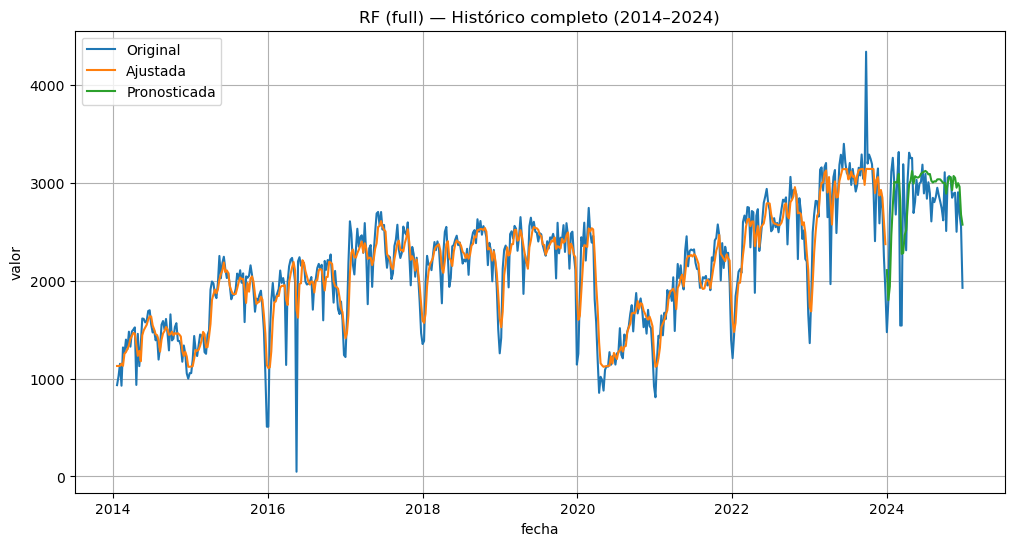

In [ ]:
# Crear dataframes con columnas correctas (cada array/serie como una columna)
df_ajustado = pd.DataFrame({
    'fecha': df['fecha'].iloc[y_real_train.index].values,
	'valor': y_pred_tr
}, index=y_real_train.index)

df_pronostico = pd.DataFrame({
    'fecha': df['fecha'].iloc[y_real_test.index].values,
	'valor': y_pred_te
}, index=y_real_test.index)

df_pronostico_c = pd.concat([df_ajustado, df_pronostico])

title = "RF (full) — Histórico completo (2014–2024)"

# # Los datos a graficar
data_tuples = (
    (df_original, 'Original'),
    (df_ajustado, 'Ajustada'),
    (df_pronostico, 'Pronosticada'),
    # (df_pronostico_c, 'Pronosticada Completa'),
)

plot_forecast(
    *data_tuples,  # Desempaqueta los datos
    y='valor',
    title=title,
    **common_plot_args  # Desempaqueta los argumentos comunes
)

# Grafica solo de prueba
# Los datos a graficar
# data_tuples = (
#     (df_test, 'Real'),
#     (df_pronostico, 'Pronosticada'),
# )

# plot_forecast(
#     *data_tuples,  # Desempaqueta los datos
#     y='valor',
#     title=title,
#     **common_plot_args  # Desempaqueta los argumentos comunes
# )

El análisis gráfico del modelo Random Forest con el conjunto completo de características (lags, seno/cos, COVID y rolling features) revela un patrón de sobreajuste (overfitting) a pesar del excelente ajuste histórico. El gráfico Histórico Completo muestra que la curva Ajustada (roja) sigue con alta fidelidad la serie Original (azul), capturando adecuadamente la estacionalidad y los picos.

#### 3.4.6. Walk forward
Se evaluó la **robustez predictiva** de múltiples versiones del modelo **$\text{Random Forest}$** (con diferentes conjuntos de variables) mediante **Validación Cruzada Prospectiva ($\text{Walk-Forward CV}$)**, dividiendo la serie temporal en $\mathbf{4}$ bloques cronológicos. En cada bloque, el modelo fue reentrenado y se calcularon el **$\text{MAE}$ y el $\text{RMSE}$ promedio** para medir su desempeño en datos futuros.

In [ ]:
def walk_forward_cv(df, features, target, n_splits=4, model_name="Modelo"):
    tscv = TimeSeriesSplit(n_splits=n_splits)
    X = df[features].values
    y = df[target].values

    metrics = {}
    for tr_idx, te_idx in tscv.split(X):
        X_tr, X_te = X[tr_idx], X[te_idx]
        y_tr, y_te = y[tr_idx], y[te_idx]

        model = RandomForestRegressor(
            n_estimators=800,
            max_depth=None,
            min_samples_split=12,
            min_samples_leaf=6,
            max_features='sqrt',
            n_jobs=-1,
            random_state=42,
        )
        model.fit(X_tr, y_tr)
        y_hat = model.predict(X_te)

        current_metric = meval.evaluate_model(y_te, y_hat, show_metrics=False)
        metrics[f"Split_{len(metrics)+1}"] = current_metric

    mae_mean = np.mean([m['MAE'] for m in metrics.values()])
    rmse_mean = np.mean([m['RMSE'] for m in metrics.values()])
    mape_mean = np.mean([m['MAPE'] for m in metrics.values()])

    mae_std = np.std([m['MAE'] for m in metrics.values()])
    rmse_std = np.std([m['RMSE'] for m in metrics.values()])
    mape_std = np.std([m['MAPE'] for m in metrics.values()])

    print(f"\n{model_name}")
    print(f"Walk-forward ({n_splits}): MAE medio: {mae_mean:.2f} ± {mae_std:.2f} |  RMSE medio: {rmse_mean:.2f} ± {rmse_std:.2f} |  MAPE medio: {mape_mean:.2f} ± {mape_std:.2f}")


    return metrics


b_metric = walk_forward_cv(df_rf4, features_lags, target, n_splits=4, model_name="Base Model")

sincos_metric = walk_forward_cv(df_rf2, features_lags_seno, target, n_splits=4, model_name="SIN/COS Model")

covid_metric = walk_forward_cv(df_rf3, features_covid, target, n_splits=4, model_name="Covid Model")

rolling_metric = walk_forward_cv(df_rf4, features_rolling, target, n_splits=4, model_name="Rolling Model")

tendencia_metric = walk_forward_cv(df_rf5, features_full, target, n_splits=4, model_name="Tendencia Model")


Base Model
Walk-forward (4): MAE medio: 290.56 ± 54.31 |  RMSE medio: 366.84 ± 61.01 |  MAPE medio: 0.23 ± 0.15

SIN/COS Model
Walk-forward (4): MAE medio: 301.20 ± 65.70 |  RMSE medio: 377.20 ± 71.39 |  MAPE medio: 0.23 ± 0.15

Covid Model
Walk-forward (4): MAE medio: 331.26 ± 42.00 |  RMSE medio: 412.27 ± 31.01 |  MAPE medio: 0.24 ± 0.15

Rolling Model
Walk-forward (4): MAE medio: 250.49 ± 55.38 |  RMSE medio: 317.72 ± 62.62 |  MAPE medio: 0.19 ± 0.14

Tendencia Model
Walk-forward (4): MAE medio: 284.27 ± 55.06 |  RMSE medio: 352.94 ± 57.17 |  MAPE medio: 0.21 ± 0.14


El análisis de la validación Walk-Forward para las diversas configuraciones del modelo revela que la inclusión de las características de Ventanas Rodantes (Rolling Model) produce la mayor mejora en la precisión predictiva. Esta configuración logra los errores absolutos más bajos de todos los modelos (MAE medio: $250.49$; RMSE medio: $317.72$) y el Error Porcentual Absoluto Medio (MAPE) más bajo ($0.19$ o $19\%$), indicando una mejor capacidad de generalización para el pronóstico de casos semanales de depresión. Por otro lado, la incorporación de las variables SIN/COS y la variable COVID resultó en un deterioro marginal o nulo en la precisión del error absoluto y porcentual en comparación con el Modelo Base. La métrica RMSE consistentemente exhibe mayor variabilidad ($\pm 60$ a $\pm 70$ en general), lo que sugiere que los modelos tienen dificultades para manejar los valores atípicos y que las ventanas rodantes son la estrategia de feature engineering más efectiva para estabilizar el pronóstico.

#### 3.4.6. RF full

Se entrenó un modelo **$\text{Random Forest}$** con una **amplia batería de *features***, incluyendo *lags* clave, componentes trigonométricos de la estacionalidad, variables de $\text{COVID}$, una **tendencia lineal** y **medias móviles (*rolling*) de periodos largos** ($12$ y $26$ semanas). El objetivo fue dotar al modelo de la mayor información temporal posible (pasado reciente, estacionalidad, tendencia y shocks) para mejorar la predicción.

In [ ]:
df = df.copy()

# --- Tendencia simple (índice temporal)
df["tendencia"] = np.arange(len(df)).astype(float)

# --- Pendiente de 8 semanas: captura dirección local
df["trend_8"] = df["valor"].diff(8).fillna(0)

# --- Rolling más largos
for w in [12, 26]:
    df[f"rolling_{w}"] = df["valor"].rolling(w, min_periods=1).mean().bfill()

# --- Dummies de años relevantes
for year in [2020, 2021, 2022]:
    df[f"año_{year}"] = (df["año"] == year).astype(int)

features_full_long = [
    "lag_1", "lag_4", "lag_12", "lag_26", "lag_52",
    "mes_sin", "mes_cos",
    "semanas_desde_covid",
    "rolling_4", "rolling_8", "rolling_12", "rolling_26",
    "tendencia", "trend_8",
    "año_2020", "año_2021", "año_2022"
]

target = "valor"
df_rf_long = df.dropna(subset=features_full_long + [target]).copy()


train_df, test_df = temporal_split(df_rf_long, test_weeks=52)
X_train, y_train = train_df[features_full_long], train_df[target]
X_test,  y_test  = test_df[features_full_long],  test_df[target]

##### 3.4.5.1. Búsqueda de hiperparámetros y entrenamiento

* Se hace una búsqueda de parámetros para guiar el proceso. Primeramente prepatando el modelo y el espacio de parámetros.

In [ ]:
#  Se defini el modelo base (estimador)
rf_base = RandomForestRegressor(
    n_jobs=-1,
    random_state=42,
    oob_score=False
)

# Se define el espacio de parámetros a explorar (param_dist)
param_dist = {
    # Número de árboles (cuántos clasificadores débiles usar)
    'n_estimators': [1000, 1500, 2000], 
    
    # Profundidad máxima del árbol. Valores más bajos reducen el sobreajuste.
    'max_depth': [5, 7, 10, 12], # 'None' significa sin límite
    
    # Número mínimo de muestras requeridas para dividir un nodo interno.
    # Valores más altos controlan mejor el sobreajuste.
    'min_samples_split': [20,30,40,50], 
    
    # Número mínimo de muestras requeridas para estar en un nodo hoja.
    # Valores más altos controlan mejor el sobreajuste.
    'min_samples_leaf': [10,15,20,30], 
    
    # Número de características a considerar para la mejor división.
    # 'sqrt' y 'log2' son valores comunes. También se puede probar una fracción.
    'max_features': [0.3, 0.5, 0.7]
}

* Obtenición de los mejores parámetros. Ejecución de la Búsqueda Aleatoria

In [ ]:
# Definir la búsqueda aleatoria
# n_iter: Número de combinaciones a probar (ej. 50 combinaciones)
# cv: Número de pliegues (folds) para la validación cruzada (ej. 3 o 5)
random_search_rf = RandomizedSearchCV(
    estimator=rf_base,
    param_distributions=param_dist,
    n_iter=50,                  # Número de combinaciones aleatorias a probar
    # Usamos el negativo del error cuadrático medio para optimizar (Maximizar es Minimizar el error)
    scoring='neg_mean_squared_error', 
    cv=5,                       # Validación Cruzada de 5 pliegues para mayor robustez
    verbose=2,
    random_state=42,
    n_jobs=-1                   # Usar todos los núcleos disponibles
)

print("Iniciando la búsqueda aleatoria para Random Forest...")

# Ejecutar la búsqueda. Asegúrate de usar tus conjuntos X_train y y_train (Numpy arrays o Pandas DataFrames/Series).
random_search_rf.fit(X_train, y_train)

Iniciando la búsqueda aleatoria para Random Forest...
Fitting 5 folds for each of 50 candidates, totalling 250 fits


RandomizedSearchCV(cv=5,
                   estimator=RandomForestRegressor(n_jobs=-1, random_state=42),
                   n_iter=50, n_jobs=-1,
                   param_distributions={'max_depth': [5, 7, 10, 12],
                                        'max_features': [0.3, 0.5, 0.7],
                                        'min_samples_leaf': [10, 15, 20, 30],
                                        'min_samples_split': [20, 30, 40, 50],
                                        'n_estimators': [1000, 1500, 2000]},
                   random_state=42, scoring='neg_mean_squared_error',
                   verbose=2)

* Obtención de mejores parámetros

In [ ]:
best_mse_neg = random_search_rf.best_score_
best_rmse = np.sqrt(-best_mse_neg) # Calculamos la raíz cuadrada para obtener el RMSE

print("Búsqueda finalizada.")
print(f"Mejor RMSE (Validación Cruzada): {best_rmse:.4f}")
print("---")
print("Mejores Parámetros:")
print(random_search_rf.best_params_)

# El mejor modelo entrenado con los parámetros óptimos
best_rf_model = random_search_rf.best_estimator_

Búsqueda finalizada.
Mejor RMSE (Validación Cruzada): 295.8136
---
Mejores Parámetros:
{'n_estimators': 2000, 'min_samples_split': 20, 'min_samples_leaf': 10, 'max_features': 0.5, 'max_depth': 10}


In [ ]:
rf_full_long = RandomForestRegressor(
    n_estimators=2000,      # más árboles = mejor estabilidad
    max_depth=10,           # control de complejidad
    min_samples_split=20,
    min_samples_leaf=10,
    max_features=0.5,
    n_jobs=-1,
    random_state=42,
)

rf_full_long.fit(X_train, y_train)


y_pred_train = rf_full_long.predict(X_train)
y_pred_test  = rf_full_long.predict(X_test)

print(f"[RF Full + RollingLong]")


model_metrics = meval.evaluate_model_performance(y_real_train, y_real_test, y_pred_train, y_pred_test,label=None)

[RF Full + RollingLong]
Evaluating model performance...

Evaluación del modelo en el conjunto Train:
╒═══════════╤════════════╕
│ Métrica   │      Valor │
╞═══════════╪════════════╡
│ MAE       │ 103.085    │
├───────────┼────────────┤
│ RMSE      │ 158.034    │
├───────────┼────────────┤
│ MAPE      │   0.112235 │
╘═══════════╧════════════╛

Evaluación del modelo en el conjunto Test:
╒═══════════╤════════════╕
│ Métrica   │      Valor │
╞═══════════╪════════════╡
│ MAE       │ 249.406    │
├───────────┼────────────┤
│ RMSE      │ 339.799    │
├───────────┼────────────┤
│ MAPE      │   0.103285 │
╘═══════════╧════════════╛


El análisis del modelo Random Forest para el pronóstico de casos semanales de depresión revela un patrón de sobreajuste (overfitting) que impacta la precisión de la generalización. En el conjunto de entrenamiento, el modelo exhibe una alta precisión con un Error Absoluto Medio (MAE) de $103.09$ y una Raíz del Error Cuadrático Medio (RMSE) de $158.03$. Sin embargo, en el conjunto de prueba, se observa un incremento drástico en los errores absolutos (MAE de $249.41$ y RMSE de $339.80$), lo que indica que el modelo no logra mantener su capacidad predictiva en las unidades originales al enfrentarse a datos no vistos. A pesar de este aumento en el error absoluto, el Error Porcentual Absoluto Medio (MAPE) en la prueba es inferior ($10.33\%$) al de entrenamiento ($11.22\%$). Este fenómeno sugiere que, aunque los errores de predicción son mayores en términos de unidades absolutas de los casos, son proporcionalmente más pequeños en relación con la magnitud de los valores reales en el conjunto de prueba, ofreciendo una estabilidad porcentual aceptable para el pronóstico.

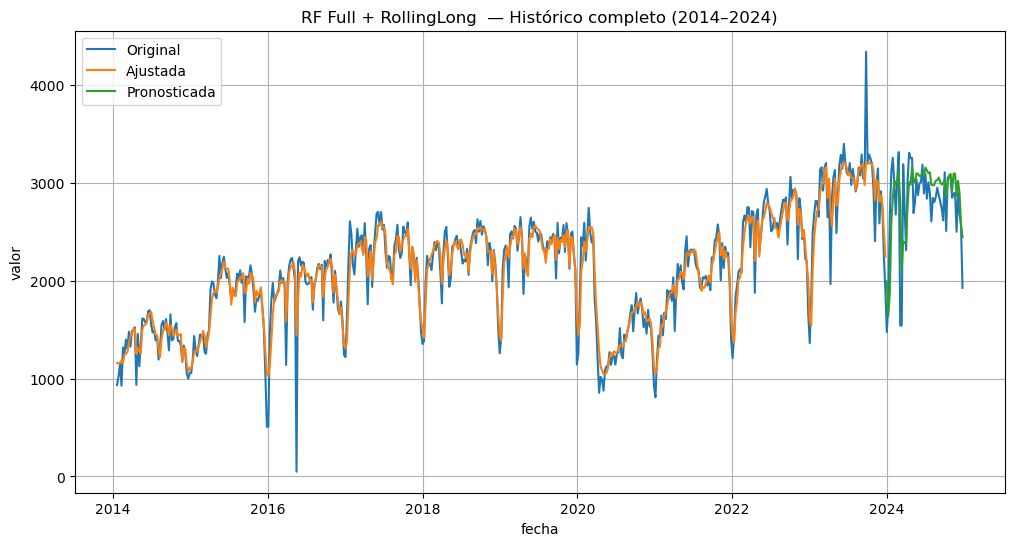

In [ ]:
# Crear dataframes con columnas correctas (cada array/serie como una columna)
df_ajustado = pd.DataFrame({
    'fecha': df['fecha'].iloc[y_real_train.index].values,
	'valor': y_pred_train
}, index=y_real_train.index)

df_pronostico = pd.DataFrame({
    'fecha': df['fecha'].iloc[y_real_test.index].values,
	'valor': y_pred_test
}, index=y_real_test.index)

df_pronostico_c = pd.concat([df_ajustado, df_pronostico])

title = "RF Full + RollingLong  — Histórico completo (2014–2024)"

# Los datos a graficar
data_tuples = (
    (df_original, 'Original'),
    (df_ajustado, 'Ajustada'),
    (df_pronostico, 'Pronosticada'),
    # (df_pronostico_c, 'Pronosticada Completa'),
)

plot_forecast(
    *data_tuples,  # Desempaqueta los datos
    y='valor',
    title=title,
    **common_plot_args  # Desempaqueta los argumentos comunes
)

# Grafica solo de prueba
# Los datos a graficar
# data_tuples = (
#     (df_test, 'Real'),
#     (df_pronostico, 'Pronosticada'),
# )

# plot_forecast(
#     *data_tuples,  # Desempaqueta los datos
#     y='valor',
#     title=title,
#     **common_plot_args  # Desempaqueta los argumentos comunes
# )

Se revela una disparidad significativa en el error absoluto entre los conjuntos, indicativa de un sobreajuste (overfitting). En el conjunto de entrenamiento, el modelo logra una alta precisión con un Error Absoluto Medio (MAE) de 103.09 y una Raíz del Error Cuadrático Medio (RMSE) de 158.03. No obstante, en el conjunto de prueba, el MAE se incrementa a 249.41 y el RMSE a 339.80, lo que implica una pérdida considerable de capacidad predictiva al generalizar a datos no observados. A pesar de este deterioro en la precisión absoluta, el Error Porcentual Absoluto Medio (MAPE) en la prueba es ligeramente inferior (10.33%) al de entrenamiento (11.22%). Este patrón sugiere que, aunque el error de pronóstico en unidades de casos es mayor en datos no vistos, el error es proporcionalmente menor respecto a la magnitud de los valores reales en el periodo de prueba, lo que ofrece una estabilidad porcentual aceptable para el pronóstico de casos semanales de depresión.

In [ ]:
long_roll_metrics = walk_forward_cv(df_rf_long, features_full_long, target, n_splits=4, model_name="Longer Rolling Model")


Longer Rolling Model
Walk-forward (4): MAE medio: 247.15 ± 64.51 |  RMSE medio: 309.03 ± 72.15 |  MAPE medio: 0.19 ± 0.14


### 3.5. Modelo 5: RF + XGBoost

* Se definen los datos y su división de conjuntos de entrenamiento y prueba

In [ ]:
df_xgb = df.dropna(subset=features_full_long + [target]).copy()

train_df, test_df = temporal_split(df_xgb, test_weeks=52)
X_train, y_train = train_df[features_full_long], train_df[target]
X_test,  y_test  = test_df[features_full_long],  test_df[target]

#### 3.5.1. Búsqueda de hiperparámetros y entrenamiento

* Se hace una búsqueda de parámetros para guiar el proceso. Primeramente prepatando el modelo y el espacio de parámetros.

In [ ]:
# Definir el modelo base
# Establecemos los parámetros que no cambiarán en la búsqueda
xgb_model = XGBRegressor(
    objective='reg:squarederror',
    eval_metric='rmse',
    seed=42,
    # El early_stopping_rounds se aplica después del fit() en un flujo normal,
    # pero RandomizedSearchCV lo maneja automáticamente con 'n_estimators'
)

# Definir el espacio de parámetros a explorar
param_dist = {
    'learning_rate': [0.005, 0.01, 0.02],     # Equivalente a 'eta'
    'n_estimators': [1000, 3000, 5000],       # Equivalente a 'num_boost_round'
    'max_depth': [3, 4, 5, 6],                # Profundidad muy limitada
    'min_child_weight': [15, 30, 50],         # Restricción alta para hojas
    'subsample': [0.6, 0.7, 0.8],             # Mayor submuestreo de filas
    'colsample_bytree': [0.6, 0.7, 0.8],      # Mayor submuestreo de columnas
    'reg_lambda': [5, 10, 20],                # Regularización L2 (lambda)
    'reg_alpha': [5, 10, 20],                 # Regularización L1 (alpha)
    'gamma': [0.0, 0.1, 0.5]                  # Mínima reducción de pérdida requerida
}

* Obtenición de los mejores parámetros. Ejecución de la Búsqueda Aleatoria

In [ ]:
# Ejecución de la búsqueda
random_search_xgb = RandomizedSearchCV(
    estimator=xgb_model,
    param_distributions=param_dist,
    n_iter=50,                  # Número de combinaciones a probar
    scoring='neg_root_mean_squared_error', # Usamos RMSE negativo
    cv=5,                       # Validación Cruzada de 5 pliegues
    verbose=2,
    random_state=42,
    n_jobs=-1                   
)

print("Iniciando la búsqueda aleatoria con regularización extrema para XGBoost...")

# Asegúrate de usar X_train y y_train como DataFrames/arrays, NO como DMatrix.
random_search_xgb.fit(X_train, y_train) 

Iniciando la búsqueda aleatoria con regularización extrema para XGBoost...
Fitting 5 folds for each of 50 candidates, totalling 250 fits


RandomizedSearchCV(cv=5,
                   estimator=XGBRegressor(base_score=None, booster=None,
                                          callbacks=None,
                                          colsample_bylevel=None,
                                          colsample_bynode=None,
                                          colsample_bytree=None, device=None,
                                          early_stopping_rounds=None,
                                          enable_categorical=False,
                                          eval_metric='rmse',
                                          feature_types=None, gamma=None,
                                          grow_policy=None,
                                          importance_type=None,
                                          interaction_constraints=None,
                                          learning_rat...
                   n_iter=50, n_jobs=-1,
                   param_distributions={'colsample_bytree': [0.6, 0.7, 0.8],
                                        'gamma': [0.0, 0.1, 0.5],
                                        'learning_rate': [0.005, 0.01, 0.02],
                                        'max_depth': [3, 4, 5, 6],
                                        'min_child_weight': [15, 30, 50],
                                        'n_estimators': [1000, 3000, 5000],
                                        'reg_alpha': [5, 10, 20],
                                        'reg_lambda': [5, 10, 20],
                                        'subsample': [0.6, 0.7, 0.8]},
                   random_state=42, scoring='neg_root_mean_squared_error',
                   verbose=2)

* Obtención de mejores parámetros

In [ ]:
# 4. Obtención de Resultados
best_rmse_cv = -random_search_xgb.best_score_ 

print("Búsqueda finalizada.")
print(f"Mejor RMSE (Validación Cruzada): {best_rmse_cv:.4f}")
print("Mejores Parámetros:")
print(random_search_xgb.best_params_)

Búsqueda finalizada.
Mejor RMSE (Validación Cruzada): 246.2277
Mejores Parámetros:
{'subsample': 0.8, 'reg_lambda': 5, 'reg_alpha': 20, 'n_estimators': 5000, 'min_child_weight': 15, 'max_depth': 6, 'learning_rate': 0.02, 'gamma': 0.0, 'colsample_bytree': 0.6}


#### 3.5.2. Evaluación del modelo

##### 3.5.2.1. MAE, RMSE y MAPE
* Se calculan las métricas de error tanto en el conjunto de entrenamiento como en el de prueba para cuantificar la precisión del modelo.

In [ ]:
params = {
    "objective": "reg:squarederror",
    "eval_metric": "rmse",
    "eta": 0.02,              
    "max_depth": 6,
    "min_child_weight": 15,
    "subsample": 0.8,
    "colsample_bytree": 0.6,
    "lambda": 5,
    "alpha": 20,
    "gamma": 0.0,
    "seed": 42,
}

dtrain = xgb.DMatrix(X_train, label=y_train)
dtest  = xgb.DMatrix(X_test,  label=y_test)

watch = [(dtrain, "train"), (dtest, "valid")]
model_xgb_full = xgb.train(
    params=params,
    dtrain=dtrain,
    num_boost_round=5000,
    evals=watch,
    early_stopping_rounds=300,
    verbose_eval=200
)

y_pred_train = model_xgb_full.predict(dtrain)
y_pred_test  = model_xgb_full.predict(dtest)

model_metrics = meval.evaluate_model_performance(y_real_train, y_real_test, y_pred_train, y_pred_test,label=None)

importance = get_xbg_feature_importance(model_xgb_full, show_importances =True)

[0]	train-rmse:557.96848	valid-rmse:806.56971
[200]	train-rmse:123.52517	valid-rmse:314.54589
[400]	train-rmse:93.85836	valid-rmse:312.95152
[438]	train-rmse:90.70107	valid-rmse:312.07315
Evaluating model performance...

Evaluación del modelo en el conjunto Train:
╒═══════════╤════════════╕
│ Métrica   │      Valor │
╞═══════════╪════════════╡
│ MAE       │ 56.0711    │
├───────────┼────────────┤
│ RMSE      │ 90.6134    │
├───────────┼────────────┤
│ MAPE      │  0.0650039 │
╘═══════════╧════════════╛

Evaluación del modelo en el conjunto Test:
╒═══════════╤═════════════╕
│ Métrica   │       Valor │
╞═══════════╪═════════════╡
│ MAE       │ 233.055     │
├───────────┼─────────────┤
│ RMSE      │ 311.931     │
├───────────┼─────────────┤
│ MAPE      │   0.0950035 │
╘═══════════╧═════════════╛
Importancia de las features (top 10):

            feature         gain
          rolling_4 2.897427e+06
              lag_1 9.881627e+05
          rolling_8 7.391384e+05
semanas_desde_covid 5.050

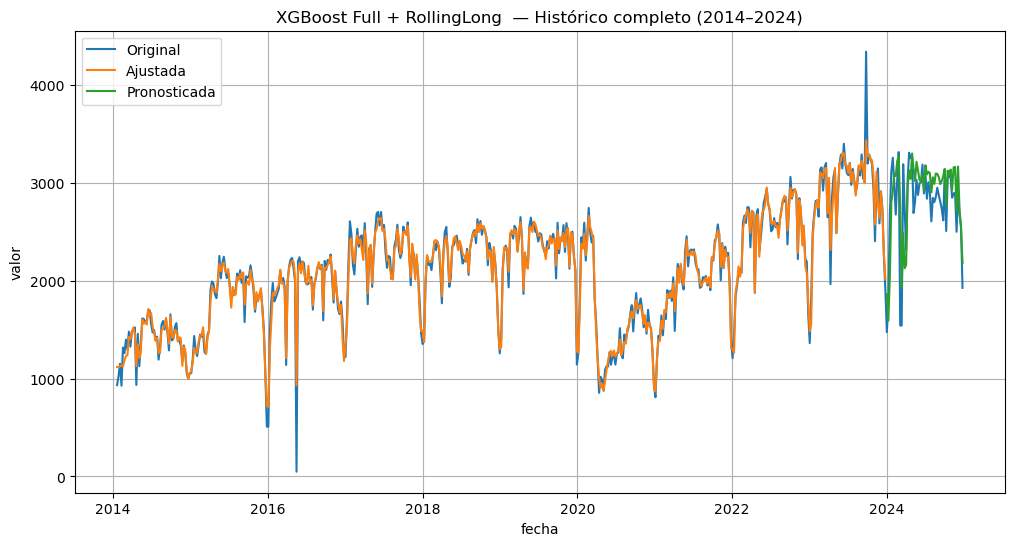

In [ ]:
# Crear dataframes con columnas correctas (cada array/serie como una columna)
df_ajustado = pd.DataFrame({
    'fecha': df['fecha'].iloc[y_real_train.index].values,
	'valor': y_pred_train
}, index=y_real_train.index)

df_pronostico = pd.DataFrame({
    'fecha': df['fecha'].iloc[y_real_test.index].values,
	'valor': y_pred_test
}, index=y_real_test.index)

df_pronostico_c = pd.concat([df_ajustado, df_pronostico])

title = "XGBoost Full + RollingLong  — Histórico completo (2014–2024)"

# Los datos a graficar
data_tuples = (
    (df_original, 'Original'),
    (df_ajustado, 'Ajustada'),
    (df_pronostico, 'Pronosticada'),
    # (df_pronostico_c, 'Pronosticada Completa'),
)

plot_forecast(
    *data_tuples,  # Desempaqueta los datos
    y='valor',
    title=title,
    **common_plot_args  # Desempaqueta los argumentos comunes
)

# Grafica solo de prueba
# Los datos a graficar
# data_tuples = (
#     (df_test, 'Real'),
#     (df_pronostico, 'Pronosticada'),
# )

# plot_forecast(
#     *data_tuples,  # Desempaqueta los datos
#     y='valor',
#     title=title,
#     **common_plot_args  # Desempaqueta los argumentos comunes
# )

In [ ]:
xgb_rolling_metrics = walk_forward_cv(df_xgb, features_full_long, target, n_splits=4, model_name="XGB + Rolling Model")


XGB + Rolling Model
Walk-forward (4): MAE medio: 247.15 ± 64.51 |  RMSE medio: 309.03 ± 72.15 |  MAPE medio: 0.19 ± 0.14


La gráfica de muestra un desempeño de predicción que, aunque generalmente sigue la **tendencia y estacionalidad** de la **Serie Real** (línea azul), exhibe una **alta volatilidad en los errores puntuales** y una **degradación de la precisión** en los extremos del periodo. Específicamente, en la primera mitad del año 2024, la **Serie Predicha** (línea naranja discontinua) **falla notablemente en capturar los picos y valles abruptos**, presentando una gran discrepancia en las caídas observadas en marzo y los máximos de mayo. Si bien el modelo parece **alinearse mejor** con las fluctuaciones de menor amplitud en la segunda mitad del año, la **incapacidad para replicar los *shocks* y la alta volatilidad** de la serie en el primer trimestre, a pesar de la inclusión de la ventana deslizante (*rolling*), indica que el $\text{XGBoost}$ **no ha capturado completamente la dinámica de cambio rápido** de la serie, lo que afecta negativamente la robustez de las predicciones puntuales. 